# What this notebook is doing (full timeline temperature plots)

This notebook is for longer-timeline temperature comparisons across the datasets I have been using for Skagit.
It mainly looks at mean temperature over time instead of event-scale behavior.

The earlier part of the notebook focuses on water-year mean temperature by the 3 sub-basins: Upper Skagit, Sauk, and Lower Skagit.
The later part expands into meteorological seasonal mean temperature with the 4-region setup, including Full Skagit, and also computes MAE relative to PRISM.

So this notebook is basically the long-timeline temperature plotting notebook, with both water-year and seasonal comparison views kept together.


[DAYMET-LOCAL] Computing WY mean tmean from local NetCDFs...
[DAYMET-LOCAL] Success.
[PRISM-TEMP] Computing WY mean tmean from local PRISM daily 4km zarrs...
[PRISM-TEMP] Success. var=tmean zarrs=5 time_n=13422
[UCLA] Computing WY mean t2 from local NetCDFs (coord-mask, per region)...
[HRRR] Computing WY mean temp from monthly zarrs (t2m)...
[PNNL] Computing WY mean temp from historical T2 using geo_em lat/lon masks...
[CONUS404-online] Loading via HyTEST intake (best-effort)...
[CONUS404-online] Success: conus404-hourly-osn var=T2
[SNOTEL-online] Fetching daily TAVG via AWDB REST API (best-effort)...
[SNOTEL-online] Added basin WY series as region='All Stations'.

[FINAL] Available datasets: ['CONUS404 (online:conus404-hourly-osn)', 'Daymet v4 (local tmean)', 'HRRR (t2m)', 'PNNL (historical T2)', 'PRISM (tmean 4km)', 'SNOTEL (mean stations)', 'UCLA ERA5 d02 (daily t2)']
                  dataset        region  year     temp_c
0  SNOTEL (mean stations)  All Stations  1987   0.000000
1 

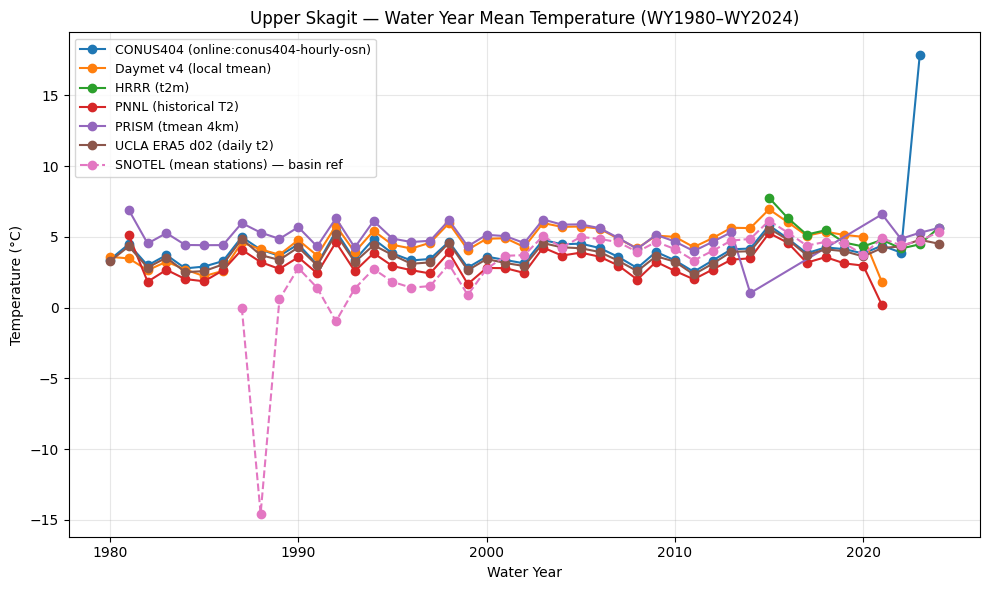

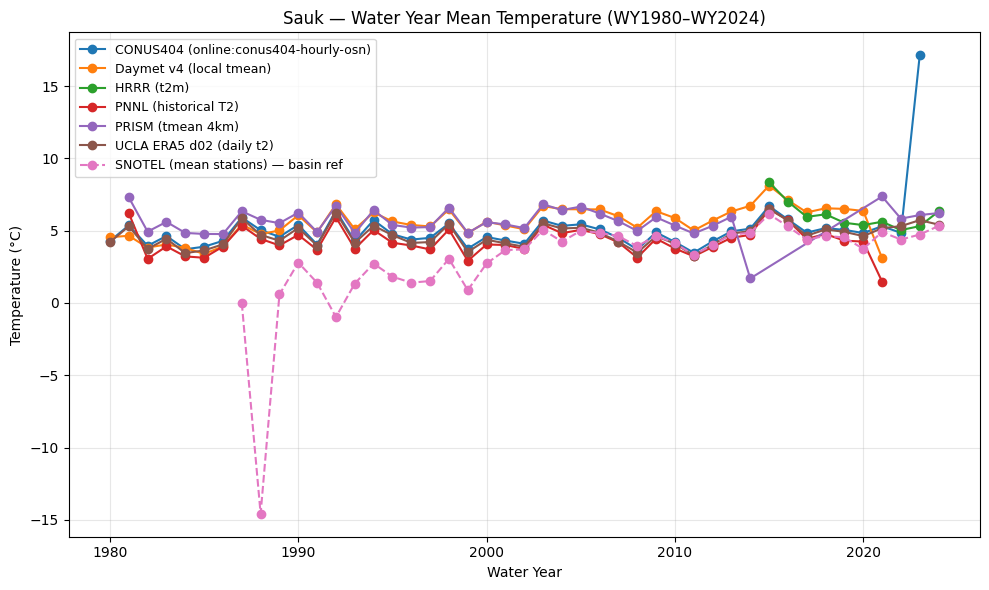

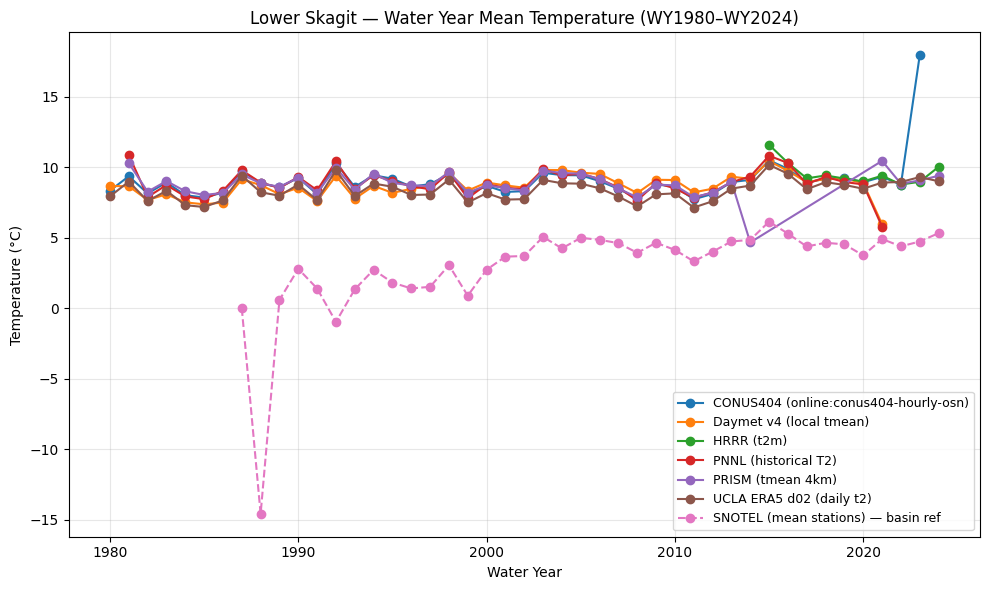

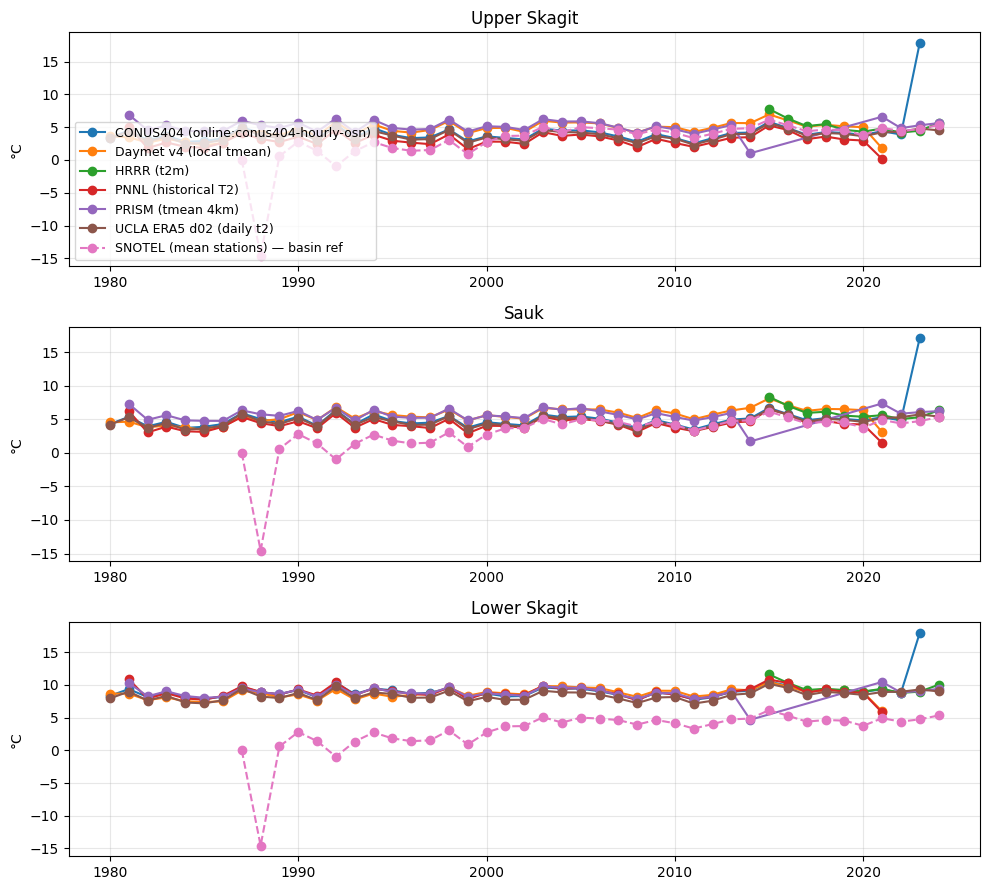

In [ ]:
# ==========================================================
# WY Mean Temperature (°C) by 3 regions (WY1980–WY2024)
#
# Datasets (best-effort; skip if missing):
#   - Daymet (LOCAL yearly NetCDFs): tmean=(tmin+tmax)/2
#   - PRISM (LOCAL daily 4km zarrs): tmean
#   - UCLA ERA5 d02 daily t2 (LOCAL): per-region masks via coord file + contains_xy fallback
#   - HRRR monthly zarrs (LOCAL): t2m
#   - PNNL historical T2 (LOCAL): build region masks from PNNL geo_em lat/lon, apply to T2 grid
#   - CONUS404 (ONLINE HyTEST): best-effort (may warn on duplicate dims; we patch common cases)
#   - SNOTEL (ONLINE AWDB): basin ref only (region="All Stations")
#
# Fixed:
# Daymet LOCAL: robust per-year open + sort x/y + drop dup time (avoids monotonic x error)
# WY group coord explicitly named "year" (fixes KeyError('year') for HRRR/CONUS404/etc.)
# PRISM temp included from /data0/balaji24/data/prism_temp_nc/*_daily_4km_PRISM_data.zarr
#
# Output:
#   - df = [dataset, region, year, temp_c]
# ==========================================================

import re, glob, time
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 1980, 2024
GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

# Local datasets
P_HRRR_DIR  = BASE / "weather_data"
PNNL_HIST   = BASE / "PNNL" / "historical"
PNNL_GEO    = PNNL_HIST / "SERDP6km.geo_em.d01.nc"

# UCLA ERA5 d02 daily t2 files
UCLA_T2_GLOB     = "/data0/balaji24/data/ucla_era5_d02_daily/t2/t2.daily.era5.d02.*.nc"
UCLA_COORD_FILE  = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

# Daymet local yearly NetCDFs (downloaded)
DAYMET_DIR = "/data0/balaji24/data/daymet_nc_2014_2024"   
DAYMET_TMIN_GLOB = f"{DAYMET_DIR}/daymet_tmin_*.nc"
DAYMET_TMAX_GLOB = f"{DAYMET_DIR}/daymet_tmax_*.nc"

# PRISM local temperature zarrs
PRISM_TEMP_DIR = Path("/data0/balaji24/data/prism_temp_nc")

# ---------------- Helpers ----------------
def _ensure_time_name(obj):
    if isinstance(obj, xr.Dataset):
        if "time" not in obj.dims:
            for alt in ("day", "date"):
                if alt in obj.dims:
                    obj = obj.rename({alt: "time"}); break
        if "time" not in obj.coords:
            for alt in ("day", "date"):
                if alt in obj.coords:
                    obj = obj.rename({alt: "time"}); break
        return obj
    if isinstance(obj, xr.DataArray):
        if "time" not in obj.dims:
            for alt in ("day", "date"):
                if alt in obj.dims:
                    obj = obj.rename({alt: "time"}); break
        return obj
    return obj

def ensure_time_sorted_unique(da):
    da = _ensure_time_name(da)
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_celsius(da):
    da = _ensure_time_name(da)
    try:
        probe = da.isel(time=0) if "time" in da.dims else da
        m = float(probe.mean().compute()) if hasattr(probe.data, "compute") else float(probe.mean())
    except Exception:
        m = 0.0
    return da - 273.15 if m > 150 else da

# ---- FIXED WY helpers (no KeyError('year')) ----
def water_year_index(time_da):
    wy = xr.where(time_da.dt.month >= 10, time_da.dt.year + 1, time_da.dt.year)
    return wy.rename("year")  # critical

def water_year_mean_over_time(da):
    da = _ensure_time_name(da)
    wy = water_year_index(da["time"])
    out = da.groupby(wy).mean("time", skipna=True)
    if "year" not in out.dims:
        # rename the group dimension to year if xarray used something else
        cand = [d for d in out.dims if d not in [dd for dd in da.dims if dd != "time"]]
        if len(cand) == 1:
            out = out.rename({cand[0]: "year"})
    return out

def wy_start(wy): return f"{wy-1}-10-01"
def wy_end(wy):   return f"{wy}-09-30"

def pick_var(ds, candidates):
    for v in candidates:
        if v in ds.data_vars: return v
    cl = [c.lower() for c in candidates]
    for v in ds.data_vars:
        if v.lower() in cl: return v
    return None

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","lat2d","XLAT","XLAT_M","Lat","LAT"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","lon2d","XLONG","XLONG_M","Lon","LON"] if n in ds), None)
    return lat_name, lon_name

def _to_2d(arr):
    arr = _ensure_time_name(arr)
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat","lon2d","lat2d","south_north","west_east")]
        if not extra: break
        arr = arr.isel({extra[0]: 0})
    return arr

def load_regions_gdf():
    import geopandas as gpd
    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)
    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    return regions_gdf.sort_values("Name").reset_index(drop=True)

def region_mean(da, grid_ds, regions_gdf):
    import regionmask
    da = _ensure_time_name(da)
    grid_ds = _ensure_time_name(grid_ds)

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        return da.expand_dims(region=list(regions_gdf["Name"].values))

    lat_name, lon_name = find_lat_lon_names(grid_ds)
    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(grid_ds[lon_name])
    lat = _to_2d(grid_ds[lat_name])

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )
    rid = regs.mask(lon, lat)

    out_list = []
    for i, _rname in enumerate(regs.names):
        m = (rid == i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(spatial, skipna=True))

    out = xr.concat(out_list, dim="region")
    out = out.assign_coords(region=regs.names)
    return out

def year_from_path(p):
    m = re.search(r"_(\d{4})\.nc$", p)
    return int(m.group(1)) if m else None

def good_file(p, var):
    try:
        ds = xr.open_dataset(p)
        ok = (var in ds.data_vars) and (ds.sizes.get("time", 0) > 0)
        ds.close()
        return ok
    except Exception:
        return False

# robust contains_xy across shapely versions
def contains_xy_mask(geom, xs, ys):
    try:
        import shapely
        cx = getattr(shapely, "contains_xy", None)
        if callable(cx):
            return np.asarray(cx(geom, xs, ys), dtype=bool)
    except Exception:
        pass
    try:
        from shapely.vectorized import contains as vcontains
        return np.asarray(vcontains(geom, xs, ys), dtype=bool)
    except Exception:
        pass
    import shapely as _sh
    from shapely.prepared import prep
    pg = prep(geom)
    return np.array([pg.contains(_sh.Point(x, y)) for x, y in zip(xs, ys)], dtype=bool)

def fix_duplicate_dims_da(da: xr.DataArray) -> xr.DataArray:
    dims = list(da.dims)
    if len(dims) == len(set(dims)):
        return da
    if da.ndim == 2 and dims == ["y", "y"]:
        da.dims = ("y", "x"); return da
    if da.ndim == 2 and dims == ["x", "x"]:
        da.dims = ("y", "x"); return da
    seen, new_dims = {}, []
    for d in dims:
        seen[d] = seen.get(d, 0) + 1
        new_dims.append(d if seen[d] == 1 else f"{d}{seen[d]-1}")
    da.dims = tuple(new_dims)
    return da

def fix_duplicate_dims(ds: xr.Dataset) -> xr.Dataset:
    for name, var in ds.variables.items():
        dims = list(getattr(var, "dims", ()))
        if len(dims) == len(set(dims)):
            continue
        if getattr(var, "ndim", 0) == 2 and dims == ["y", "y"]:
            ds[name].dims = ("y", "x"); continue
        if getattr(var, "ndim", 0) == 2 and dims == ["x", "x"]:
            ds[name].dims = ("y", "x"); continue
        seen, new_dims = {}, []
        for d in dims:
            seen[d] = seen.get(d, 0) + 1
            new_dims.append(d if seen[d] == 1 else f"{d}{seen[d]-1}")
        ds[name].dims = tuple(new_dims)
    return ds

# one-to-one mapping so (450,450) never collapses into (450,)
def align_mask_to_da(mask_da: xr.DataArray, da: xr.DataArray) -> xr.DataArray:
    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"Expected 2 spatial dims, got {spatial}")

    mask_da = mask_da.squeeze(drop=True)
    mask_da = fix_duplicate_dims_da(mask_da)
    if mask_da.ndim != 2:
        raise RuntimeError(f"Mask must be 2D; got dims={mask_da.dims}, shape={mask_da.shape}")

    mdims = list(mask_da.dims)

    rename_map = {}
    used_sd = set()
    for md in mdims:
        if md in spatial:
            rename_map[md] = md
            used_sd.add(md)

    remaining_md = [md for md in mdims if md not in rename_map]
    remaining_sd = [sd for sd in spatial if sd not in used_sd]

    for md in remaining_md:
        matched = None
        for sd in remaining_sd:
            if mask_da.sizes[md] == da.sizes[sd]:
                matched = sd
                break
        if matched is None:
            raise RuntimeError(
                f"Could not map mask dim '{md}' (size={mask_da.sizes[md]}) "
                f"to any of {remaining_sd} with sizes {[da.sizes[s] for s in remaining_sd]}"
            )
        rename_map[md] = matched
        remaining_sd.remove(matched)

    m = mask_da.rename(rename_map)

    if set(m.dims) == set(spatial) and list(m.dims) != spatial:
        m = m.transpose(*spatial)

    if (m.sizes.get(spatial[0], -1) != da.sizes[spatial[0]]) or (m.sizes.get(spatial[1], -1) != da.sizes[spatial[1]]):
        raise RuntimeError(
            f"Mask shape {(m.sizes.get(spatial[0]), m.sizes.get(spatial[1]))} "
            f"does not match data grid {(da.sizes[spatial[0]], da.sizes[spatial[1]])}"
        )
    return m

# ---- Daymet local robust open ----
def open_daymet_year(path_nc: str, var: str) -> xr.Dataset:
    ds = xr.open_dataset(path_nc, engine="netcdf4")
    ds = _ensure_time_name(ds)
    if var not in ds:
        ds.close()
        raise KeyError(f"{path_nc} missing var={var}")
    if "x" in ds.coords:
        ds = ds.sortby("x")
    if "y" in ds.coords:
        ds = ds.sortby("y")
    if "time" in ds.coords:
        tt = pd.to_datetime(ds["time"].values)
        _, idx = np.unique(tt, return_index=True)
        ds = ds.isel(time=np.sort(idx))
    return ds[[var]]

# ---- PRISM open ----
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def _detect_prism_temp_var(ds):
    candidates = ["tmean", "tavg", "tmean_c", "tmean_degC", "Tmean", "temp", "tas"]
    for v in candidates:
        if v in ds.data_vars:
            return v
    for v in ds.data_vars:
        vl = v.lower()
        if "tmean" in vl or "tavg" in vl or ("temp" in vl and "mean" in vl):
            return v
    return None

# ---------------- Run ----------------
regions_gdf = load_regions_gdf()
rows = []

# ==========================================================
# 1) Daymet LOCAL
# ==========================================================
print("[DAYMET-LOCAL] Computing WY mean tmean from local NetCDFs...")
try:
    tmin_files = sorted(glob.glob(DAYMET_TMIN_GLOB))
    tmax_files = sorted(glob.glob(DAYMET_TMAX_GLOB))

    tmin_good = {year_from_path(f): f for f in tmin_files if year_from_path(f) is not None and good_file(f, "tmin")}
    tmax_good = {year_from_path(f): f for f in tmax_files if year_from_path(f) is not None and good_file(f, "tmax")}

    years = sorted([y for y in range(YEAR_MIN-1, YEAR_MAX+1) if (y in tmin_good and y in tmax_good)])
    if not years:
        raise RuntimeError("No overlapping good tmin/tmax years found.")

    dsmin_list, dsmax_list = [], []
    for y in years:
        dsmin_list.append(open_daymet_year(tmin_good[y], "tmin"))
        dsmax_list.append(open_daymet_year(tmax_good[y], "tmax"))

    ds_min = xr.concat(dsmin_list, dim="time", join="outer", coords="minimal", compat="override").sortby("time")
    ds_max = xr.concat(dsmax_list, dim="time", join="outer", coords="minimal", compat="override").sortby("time")

    tmin = ensure_time_sorted_unique(ds_min["tmin"])
    tmax = ensure_time_sorted_unique(ds_max["tmax"])
    tmin2, tmax2 = xr.align(tmin, tmax, join="inner")

    tmean = to_celsius((tmin2 + tmax2) / 2.0).sel(time=slice(GLOBAL_START, GLOBAL_END))
    rm = ensure_time_sorted_unique(region_mean(tmean, grid_ds=ds_min, regions_gdf=regions_gdf))
    wy = water_year_mean_over_time(rm)

    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        if wy_i not in wy["year"].values:
            continue
        for rgn in wy["region"].values:
            val = float(wy.sel(year=wy_i, region=rgn).values)
            if np.isfinite(val):
                rows.append({"dataset": "Daymet-PC", "region": str(rgn), "year": int(wy_i), "temp_c": float(val)})

    for d in dsmin_list:
        try: d.close()
        except Exception: pass
    for d in dsmax_list:
        try: d.close()
        except Exception: pass
    try: ds_min.close()
    except Exception: pass
    try: ds_max.close()
    except Exception: pass

    print("[DAYMET-LOCAL] Success.")
except Exception as e:
    print("[DAYMET-LOCAL] FAILED:", repr(e))

# ==========================================================
# 1b) PRISM tmean (local zarrs)
# ==========================================================
print("[PRISM-TEMP] Computing WY mean tmean from local PRISM daily 4km zarrs...")
try:
    prism_zarrs = sorted([p for p in PRISM_TEMP_DIR.glob("*_daily_4km_PRISM_data.zarr") if p.is_dir()])
    if not prism_zarrs:
        raise RuntimeError(f"No PRISM temp zarrs found under {PRISM_TEMP_DIR}")

    ds0 = safe_open_zarr(prism_zarrs[0])
    v0 = _detect_prism_temp_var(ds0)
    if v0 is None:
        raise RuntimeError(f"Could not detect PRISM temp variable. data_vars={list(ds0.data_vars)[:50]}")

    da_list = []
    ds_handles = [ds0]
    da0 = ds0[v0]
    if "time" not in da0.dims:
        tdim = next((d for d in da0.dims if "time" in d.lower() or "day" in d.lower() or "date" in d.lower()), None)
        if tdim:
            da0 = da0.rename({tdim: "time"})
    if "time" in da0.dims:
        da_list.append(da0)

    for p in prism_zarrs[1:]:
        dsi = safe_open_zarr(p)
        ds_handles.append(dsi)
        if v0 not in dsi:
            continue
        dai = dsi[v0]
        if "time" not in dai.dims:
            tdim = next((d for d in dai.dims if "time" in d.lower() or "day" in d.lower() or "date" in d.lower()), None)
            if tdim:
                dai = dai.rename({tdim: "time"})
        if "time" in dai.dims:
            da_list.append(dai)

    if not da_list:
        raise RuntimeError("No PRISM arrays with a usable time dimension found.")

    prism = xr.concat(da_list, dim="time", join="outer", coords="minimal", compat="override")
    prism = ensure_time_sorted_unique(prism).sel(time=slice(GLOBAL_START, GLOBAL_END))
    if prism.sizes.get("time", 0) == 0:
        raise RuntimeError("PRISM slice is empty for GLOBAL_START..GLOBAL_END")

    prism_c = to_celsius(prism)
    prism_rm = ensure_time_sorted_unique(region_mean(prism_c, grid_ds=ds0, regions_gdf=regions_gdf))
    prism_wy = water_year_mean_over_time(prism_rm)

    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        if wy_i not in prism_wy["year"].values:
            continue
        for rgn in prism_wy["region"].values:
            val = float(prism_wy.sel(year=wy_i, region=rgn).values)
            if np.isfinite(val):
                rows.append({"dataset": "PRISM 4km", "region": str(rgn), "year": int(wy_i), "temp_c": float(val)})

    print(f"[PRISM-TEMP] Success. var={v0} zarrs={len(prism_zarrs)} time_n={prism.sizes.get('time')}")

    for dsh in ds_handles:
        try: dsh.close()
        except Exception: pass

except Exception as e:
    print("[PRISM-TEMP] SKIP/FAILED:", repr(e))

# ==========================================================
# 2) UCLA ERA5 d02
# ==========================================================
print("[UCLA] Computing WY mean t2 from local NetCDFs (coord-mask, per region)...")
try:
    files = sorted(glob.glob(UCLA_T2_GLOB))
    if not files:
        raise RuntimeError(f"No UCLA files matched: {UCLA_T2_GLOB}")
    if not UCLA_COORD_FILE.exists():
        raise RuntimeError(f"Missing UCLA coord file: {UCLA_COORD_FILE}")

    g = xr.open_dataset(UCLA_COORD_FILE, engine="netcdf4")
    lat2d = g["lat2d"].squeeze(drop=True).astype("float64")
    lon2d = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    regions_ll = regions_gdf.to_crs("EPSG:4326")
    lonv = lon2d.values.ravel()
    latv = lat2d.values.ravel()
    ny, nx = lon2d.shape

    ucla_region_masks = {}
    for rname in REGION_NAMES:
        geom = regions_ll.loc[regions_ll["Name"] == rname, "geometry"].iloc[0]
        m_flat = contains_xy_mask(geom, lonv, latv)
        mask2d = m_flat.reshape(ny, nx).astype(bool)
        ucla_region_masks[rname] = xr.DataArray(mask2d, dims=lon2d.dims, coords=lon2d.coords)

    ds_u = xr.open_mfdataset(files, combine="by_coords", parallel=False, join="outer")
    ds_u = _ensure_time_name(ds_u)

    v = pick_var(ds_u, ["t2", "T2", "t2m", "tas", "temp"])
    if v is None:
        raise RuntimeError(f"Could not find temperature variable in UCLA ds. Vars head={list(ds_u.data_vars)[:30]}")

    da = to_celsius(ensure_time_sorted_unique(ds_u[v]).sel(time=slice(GLOBAL_START, GLOBAL_END)))
    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"Unexpected UCLA spatial dims: {spatial}")

    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        sub = da.sel(time=slice(wy_start(wy_i), wy_end(wy_i)))
        if sub.sizes.get("time", 0) == 0:
            continue
        for rname in REGION_NAMES:
            m = align_mask_to_da(ucla_region_masks[rname], sub)
            bm_daily = sub.where(m).mean(dim=spatial, skipna=True)
            wy_mean = float(bm_daily.mean("time", skipna=True).values)
            if np.isfinite(wy_mean):
                rows.append({"dataset": "UCLA ERA5 d02", "region": str(rname), "year": int(wy_i), "temp_c": float(wy_mean)})

    ds_u.close()
except Exception as e:
    print("[UCLA] FAILED:", repr(e))

# ==========================================================
# 3) HRRR
# ==========================================================
print("[HRRR] Computing WY mean temp from monthly zarrs (t2m)...")
try:
    monthly = sorted(P_HRRR_DIR.glob("*.zarr")) if P_HRRR_DIR.exists() else []
    monthly = [p for p in monthly if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
    if not monthly:
        raise RuntimeError("No HRRR monthly zarrs found")

    need_prefixes = set(pd.date_range(GLOBAL_START, GLOBAL_END, freq="MS").strftime("%Y-%m").tolist())
    parts = sorted([p for p in monthly if p.name[:7] in need_prefixes], key=lambda p: p.name[:7])
    if not parts:
        raise RuntimeError("No overlapping HRRR months for this window")

    ds0 = xr.open_zarr(parts[0], consolidated=False)
    if "t2m" not in ds0:
        raise RuntimeError("HRRR missing 't2m' in monthly zarrs")

    dsets = [xr.open_zarr(p, consolidated=False)[["t2m"]] for p in parts]
    ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override")

    da = to_celsius(ensure_time_sorted_unique(ds["t2m"]))
    daily = da.resample(time="1D").mean()
    rm_daily = ensure_time_sorted_unique(region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)).sel(time=slice(GLOBAL_START, GLOBAL_END))
    wy = water_year_mean_over_time(rm_daily)

    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        if wy_i not in wy["year"].values:
            continue
        for r in wy["region"].values:
            val = float(wy.sel(year=wy_i, region=r).values)
            if np.isfinite(val):
                rows.append({"dataset": "HRRR (t2m)", "region": str(r), "year": int(wy_i), "temp_c": float(val)})

    for d in dsets:
        try: d.close()
        except Exception: pass
    ds.close(); ds0.close()
except Exception as e:
    print("[HRRR] SKIP/FAILED:", repr(e))

# ==========================================================
# 4) PNNL (geo_em masks)
# ==========================================================
print("[PNNL] Computing WY mean temp from historical T2 using geo_em lat/lon masks...")
try:
    import regionmask

    if not PNNL_HIST.exists():
        raise RuntimeError("Missing PNNL_HIST")
    if not PNNL_GEO.exists():
        raise RuntimeError(f"Missing PNNL geo_em file: {PNNL_GEO}")

    geo = xr.open_dataset(PNNL_GEO)
    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat2 = _to_2d(geo[lat_name]).astype("float64")
    lon2 = _to_2d(geo[lon_name]).astype("float64")

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )
    rid = regs.mask(lon2, lat2)

    pnnl_masks_np = {r: np.asarray((rid == i).data, dtype=bool) for i, r in enumerate(regs.names)}
    rid_dims = rid.dims
    rid_coords = {d: rid[d] for d in rid.dims if d in rid.coords}
    geo.close()

    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        files = []
        files += sorted(glob.glob(str(PNNL_HIST / f"{wy_i-1}" / "*T2*.nc")))
        files += sorted(glob.glob(str(PNNL_HIST / f"{wy_i}"   / "*T2*.nc")))
        if not files:
            continue

        def _preprocess(ds):
            return ds[["T2"]] if "T2" in ds.data_vars else ds

        dsp = xr.open_mfdataset(
            files, combine="by_coords", engine="netcdf4", parallel=False,
            preprocess=_preprocess, chunks={"time": 24 * 7}, join="outer"
        )
        dsp = _ensure_time_name(dsp)
        dsp = fix_duplicate_dims(dsp)

        if "T2" not in dsp:
            dsp.close(); continue

        t2 = ensure_time_sorted_unique(dsp["T2"]).sel(time=slice(wy_start(wy_i), wy_end(wy_i)))
        if t2.sizes.get("time", 0) == 0:
            dsp.close(); continue

        t2_daily = to_celsius(t2).resample(time="1D").mean()
        spatial = [d for d in t2_daily.dims if d != "time"]
        if len(spatial) != 2:
            dsp.close()
            raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

        for rname in REGION_NAMES:
            m_geo = xr.DataArray(pnnl_masks_np[rname], dims=rid_dims, coords=rid_coords)
            m = align_mask_to_da(m_geo, t2_daily)
            bm = t2_daily.where(m).mean(dim=spatial, skipna=True)
            wy_mean = float(bm.mean("time", skipna=True).values)
            if np.isfinite(wy_mean):
                rows.append({"dataset": "PNNL hist", "region": str(rname), "year": int(wy_i), "temp_c": float(wy_mean)})

        dsp.close()

except Exception as e:
    print("[PNNL] SKIP/FAILED:", repr(e))

# ==========================================================
# 5) CONUS404 online
# ==========================================================
print("[CONUS404-online] Loading via HyTEST intake (best-effort)...")
try:
    import intake
    ds_cat = intake.open_catalog("https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml")
    conus_url = ds_cat["conus404-catalog"].path
    conus_cat = intake.open_catalog(conus_url)

    osn_keys = [k for k in list(conus_cat) if "osn" in k.lower()]
    if not osn_keys:
        raise RuntimeError("No OSN entries found in CONUS404 catalog")
    used_key = osn_keys[0]

    ds_c = conus_cat[used_key].to_dask()
    ds_c = fix_duplicate_dims(ds_c)
    if "lon" in ds_c: ds_c["lon"] = fix_duplicate_dims_da(ds_c["lon"])
    if "lat" in ds_c: ds_c["lat"] = fix_duplicate_dims_da(ds_c["lat"])

    v = pick_var(ds_c, ["t2m", "tas", "T2", "temp", "temperature"])
    if v is None:
        raise RuntimeError(f"No temp var found. Vars head={list(ds_c.data_vars)[:30]}")

    da = to_celsius(ensure_time_sorted_unique(ds_c[v]).sel(time=slice(GLOBAL_START, GLOBAL_END)))
    rm = ensure_time_sorted_unique(region_mean(da, grid_ds=ds_c, regions_gdf=regions_gdf))
    wy = water_year_mean_over_time(rm)

    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        if wy_i not in wy["year"].values:
            continue
        for rgn in wy["region"].values:
            val = float(wy.sel(year=wy_i, region=rgn).values)
            if np.isfinite(val):
                rows.append({"dataset": "CONUS404", "region": str(rgn), "year": int(wy_i), "temp_c": float(val)})

    print(f"[CONUS404-online] Success: {used_key} var={v}")

except Exception as e:
    print("[CONUS404-online] SKIP/FAILED:", repr(e))

# ==========================================================
# 6) SNOTEL basin ref (All Stations)
# ==========================================================
print("[SNOTEL-online] Fetching daily TAVG via AWDB REST API (best-effort)...")
try:
    import requests
    import geopandas as gpd
    from shapely.geometry import Point

    skagit = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    try:
        skagit_poly = skagit.geometry.union_all()
    except Exception:
        skagit_poly = skagit.geometry.unary_union

    stations_url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/stations"
    r = requests.get(stations_url, params={"networkCds": "SNTL", "stateCds": "WA"}, timeout=120)
    r.raise_for_status()
    st = pd.DataFrame(r.json())

    lat_col = next((c for c in st.columns if c.lower() in ["latitude","lat"]), None)
    lon_col = next((c for c in st.columns if c.lower() in ["longitude","lon","lng"]), None)
    trip_col = next((c for c in st.columns if c.lower() == "stationtriplet"), None)
    if lat_col is None or lon_col is None or trip_col is None:
        raise RuntimeError(f"Unexpected stations schema. Columns: {list(st.columns)}")

    pts = [Point(xy) for xy in zip(st[lon_col].astype(float), st[lat_col].astype(float))]
    inside = [skagit_poly.contains(p) for p in pts]
    triplets_all = st.loc[inside, trip_col].astype(str).tolist()
    triplets = [t for t in triplets_all if t.endswith(":WA:SNTL")]
    if not triplets:
        raise RuntimeError("No WA:SNTL stations found inside Skagit polygon.")

    data_url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/data"
    begin = f"{YEAR_MIN-1}-10-01 00:00"
    end   = f"{YEAR_MAX}-09-30 23:59"

    def chunks(lst, n):
        for i in range(0, len(lst), n):
            yield lst[i:i+n]

    def extract_pairs_awdb(payload):
        out = []
        if not isinstance(payload, list):
            return out
        for item in payload:
            if not isinstance(item, dict):
                continue
            data_list = item.get("data", [])
            if not isinstance(data_list, list):
                continue
            for block in data_list:
                if not isinstance(block, dict):
                    continue
                vals = block.get("values", [])
                if not isinstance(vals, list):
                    continue
                for v in vals:
                    dt = pd.to_datetime(v.get("date"), errors="coerce")
                    val = pd.to_numeric(v.get("value"), errors="coerce")
                    if pd.isna(dt) or pd.isna(val):
                        continue
                    out.append((dt, float(val)))
        return out

    all_pairs = []
    for ch in chunks(triplets, 25):
        params = {
            "stationTriplets": ",".join(ch),
            "elements": "TAVG",
            "beginDate": begin,
            "endDate": end,
            "duration": "DAILY",
            "centralTendencyType": "NONE",
            "returnFlags": "false",
            "returnOriginalValues": "false",
            "returnSuspectData": "false",
        }
        rr = requests.get(data_url, params=params, timeout=180)
        rr.raise_for_status()
        all_pairs.extend(extract_pairs_awdb(rr.json()))

    if not all_pairs:
        raise RuntimeError("No TAVG values extracted from AWDB payload.")

    df_daily = pd.DataFrame(all_pairs, columns=["time", "temp_f"]).dropna()
    df_daily["time"] = pd.to_datetime(df_daily["time"])
    df_daily = df_daily[(df_daily["time"] >= GLOBAL_START) & (df_daily["time"] <= GLOBAL_END)]
    df_daily["temp_c"] = (df_daily["temp_f"] - 32) * (5/9)

    basin_daily = df_daily.groupby("time", as_index=False)["temp_c"].mean()
    basin_daily["wy"] = np.where(basin_daily["time"].dt.month >= 10,
                                 basin_daily["time"].dt.year + 1,
                                 basin_daily["time"].dt.year)
    df_wy = basin_daily.groupby("wy", as_index=False)["temp_c"].mean()
    df_wy = df_wy[(df_wy["wy"] >= YEAR_MIN) & (df_wy["wy"] <= YEAR_MAX)].sort_values("wy")

    for _, r in df_wy.iterrows():
        rows.append({"dataset": "SNOTEL (mean stations)", "region": "All Stations", "year": int(r["wy"]), "temp_c": float(r["temp_c"])})
    print("[SNOTEL-online] Added basin WY series as region='All Stations'.")

except Exception as e:
    print("[SNOTEL-online] SKIP/FAILED:", repr(e))

# ==========================================================
# Build df
# ==========================================================
df = (
    pd.DataFrame(rows)
      .groupby(["dataset","region","year"], as_index=False)
      .agg(temp_c=("temp_c","mean"))
      .sort_values(["region","dataset","year"])
      .reset_index(drop=True)
)

df = df[(df["year"] >= YEAR_MIN) & (df["year"] <= YEAR_MAX)].copy()

print("\n[FINAL] Available datasets:", sorted(df["dataset"].unique().tolist()))
print(df.head(10))

# ==========================================================
# PLOTTING 
# ==========================================================
snotel = df[(df["dataset"] == "SNOTEL (mean stations)") & (df["region"] == "All Stations")].copy()
snotel = snotel.sort_values("year")

for region in REGION_NAMES:
    fig = plt.figure(figsize=(10, 6))
    ax = plt.gca()

    sub = df[df["region"] == region].copy()
    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        ax.plot(g["year"], g["temp_c"].astype(float), marker="o", label=str(dsname))

    if not snotel.empty:
        ax.plot(
            snotel["year"],
            snotel["temp_c"].astype(float),
            marker="o",
            linestyle="--",
            label="SNOTEL (mean stations) — basin ref"
        )

    ax.set_title(f"{region} — Water Year Mean Temperature (WY{YEAR_MIN}–WY{YEAR_MAX})")
    ax.set_xlabel("Water Year")
    ax.set_ylabel("Temperature (°C)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

fig = plt.figure(figsize=(10, 9))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = df[df["region"] == region].copy()
    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        ax.plot(g["year"], g["temp_c"].astype(float), marker="o", label=str(dsname))
    if not snotel.empty:
        ax.plot(
            snotel["year"],
            snotel["temp_c"].astype(float),
            marker="o",
            linestyle="--",
            label="SNOTEL (mean stations) — basin ref"
        )
    ax.set_title(region)
    ax.set_ylabel("°C")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


# Better Visualized

[DAYMET-LOCAL] Computing WY mean tmean from local NetCDFs...
[DAYMET-LOCAL] Success.
[PRISM-TEMP] Computing WY mean tmean from local PRISM...
[PRISM-TEMP] Selected zarr windows:
  - 1981-01-01_1989-12-31_daily_4km_PRISM_data.zarr  (1981..1989)
  - 1990-01-01_1999-12-31_daily_4km_PRISM_data.zarr  (1990..1999)
  - 2000-01-01_2009-12-31_daily_4km_PRISM_data.zarr  (2000..2009)
  - 2010-01-01_2013-12-31_daily_4km_PRISM_data.zarr  (2010..2013)
  - 2014-01-01_2024-12-31_daily_4km_PRISM_data.zarr  (2014..2024)
[PRISM-TEMP] Used zarr: 1981-01-01_1989-12-31_daily_4km_PRISM_data.zarr | var=tmean | time=1981-01-01 -> 1989-12-31
[PRISM-TEMP] Used zarr: 1990-01-01_1999-12-31_daily_4km_PRISM_data.zarr | var=tmean | time=1990-01-01 -> 1999-12-31
[PRISM-TEMP] Used zarr: 2000-01-01_2009-12-31_daily_4km_PRISM_data.zarr | var=tmean | time=2000-01-01 -> 2009-12-31
[PRISM-TEMP] Used zarr: 2010-01-01_2013-12-31_daily_4km_PRISM_data.zarr | var=tmean | time=2010-01-01 -> 2013-12-31
[PRISM-TEMP] Used zarr: 2014

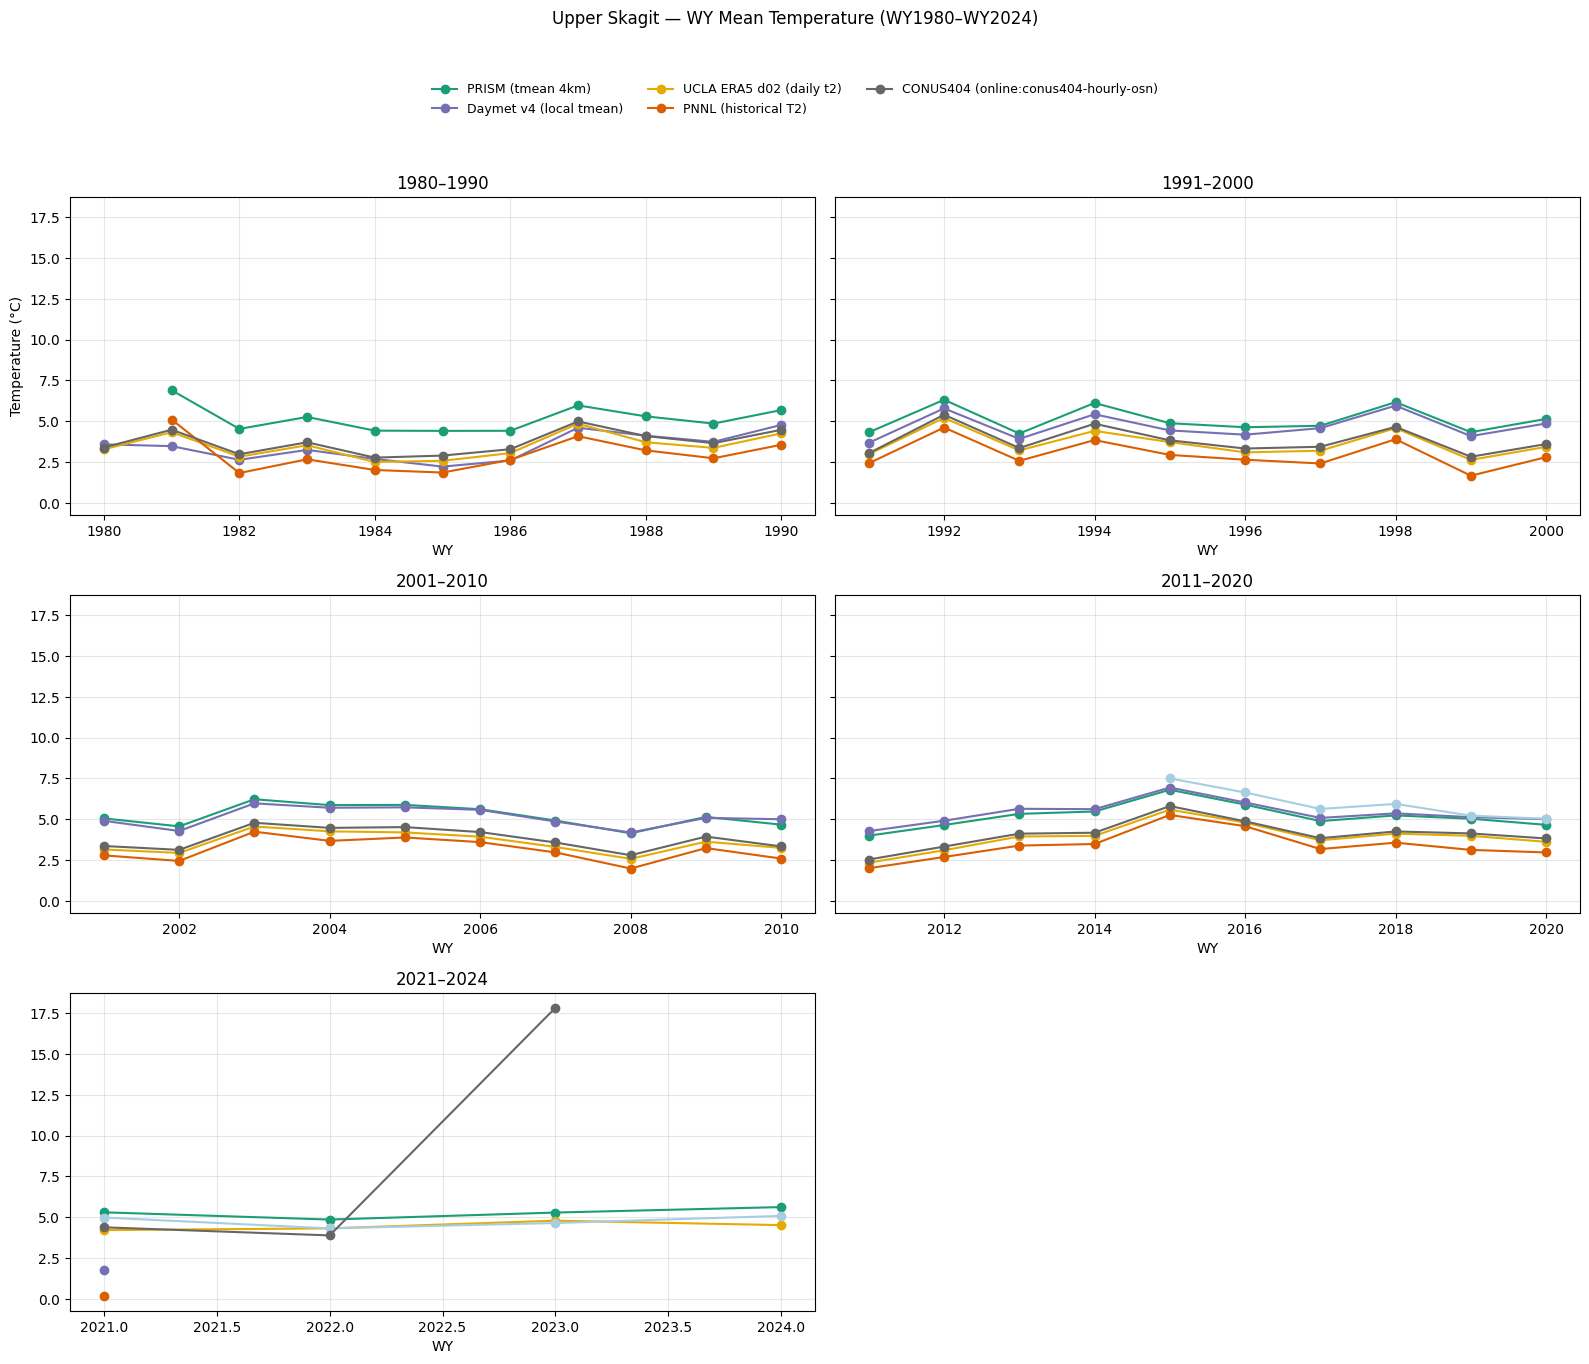

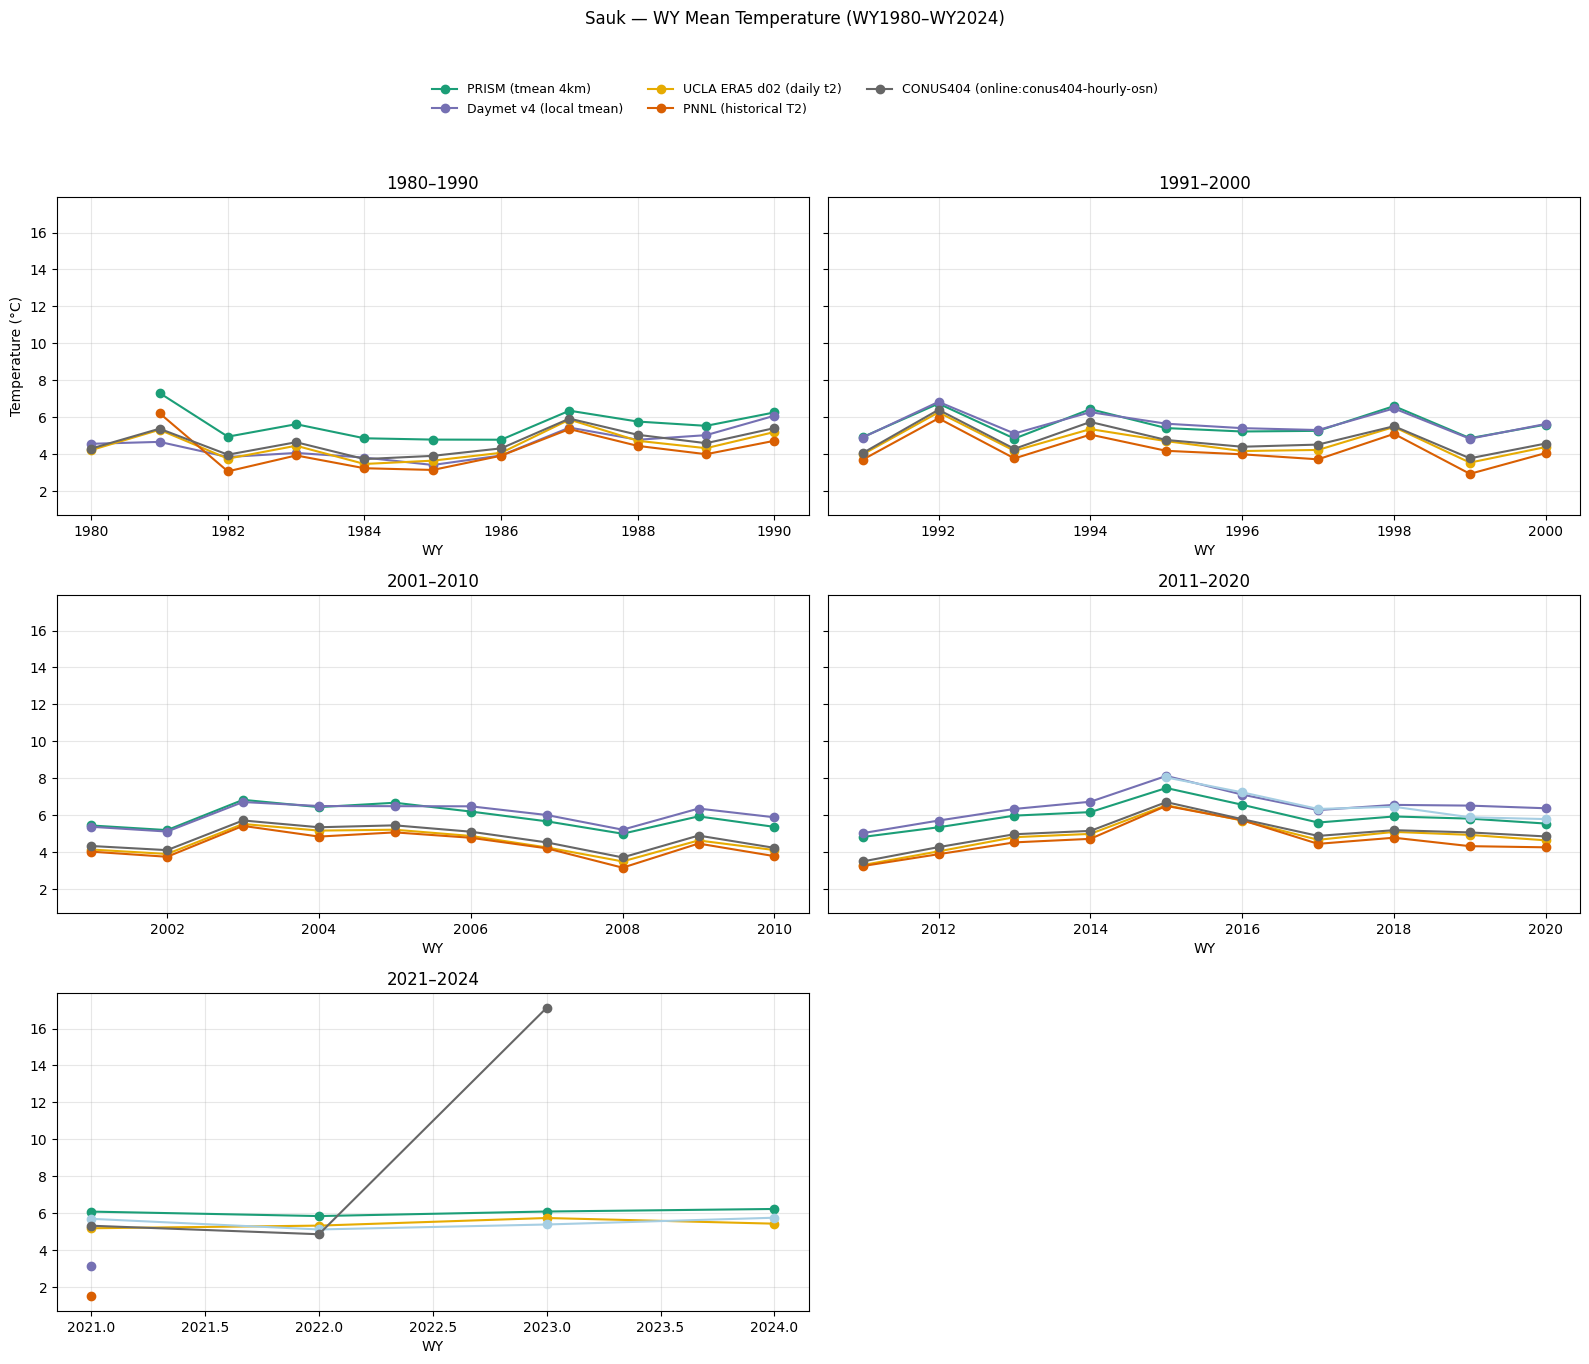

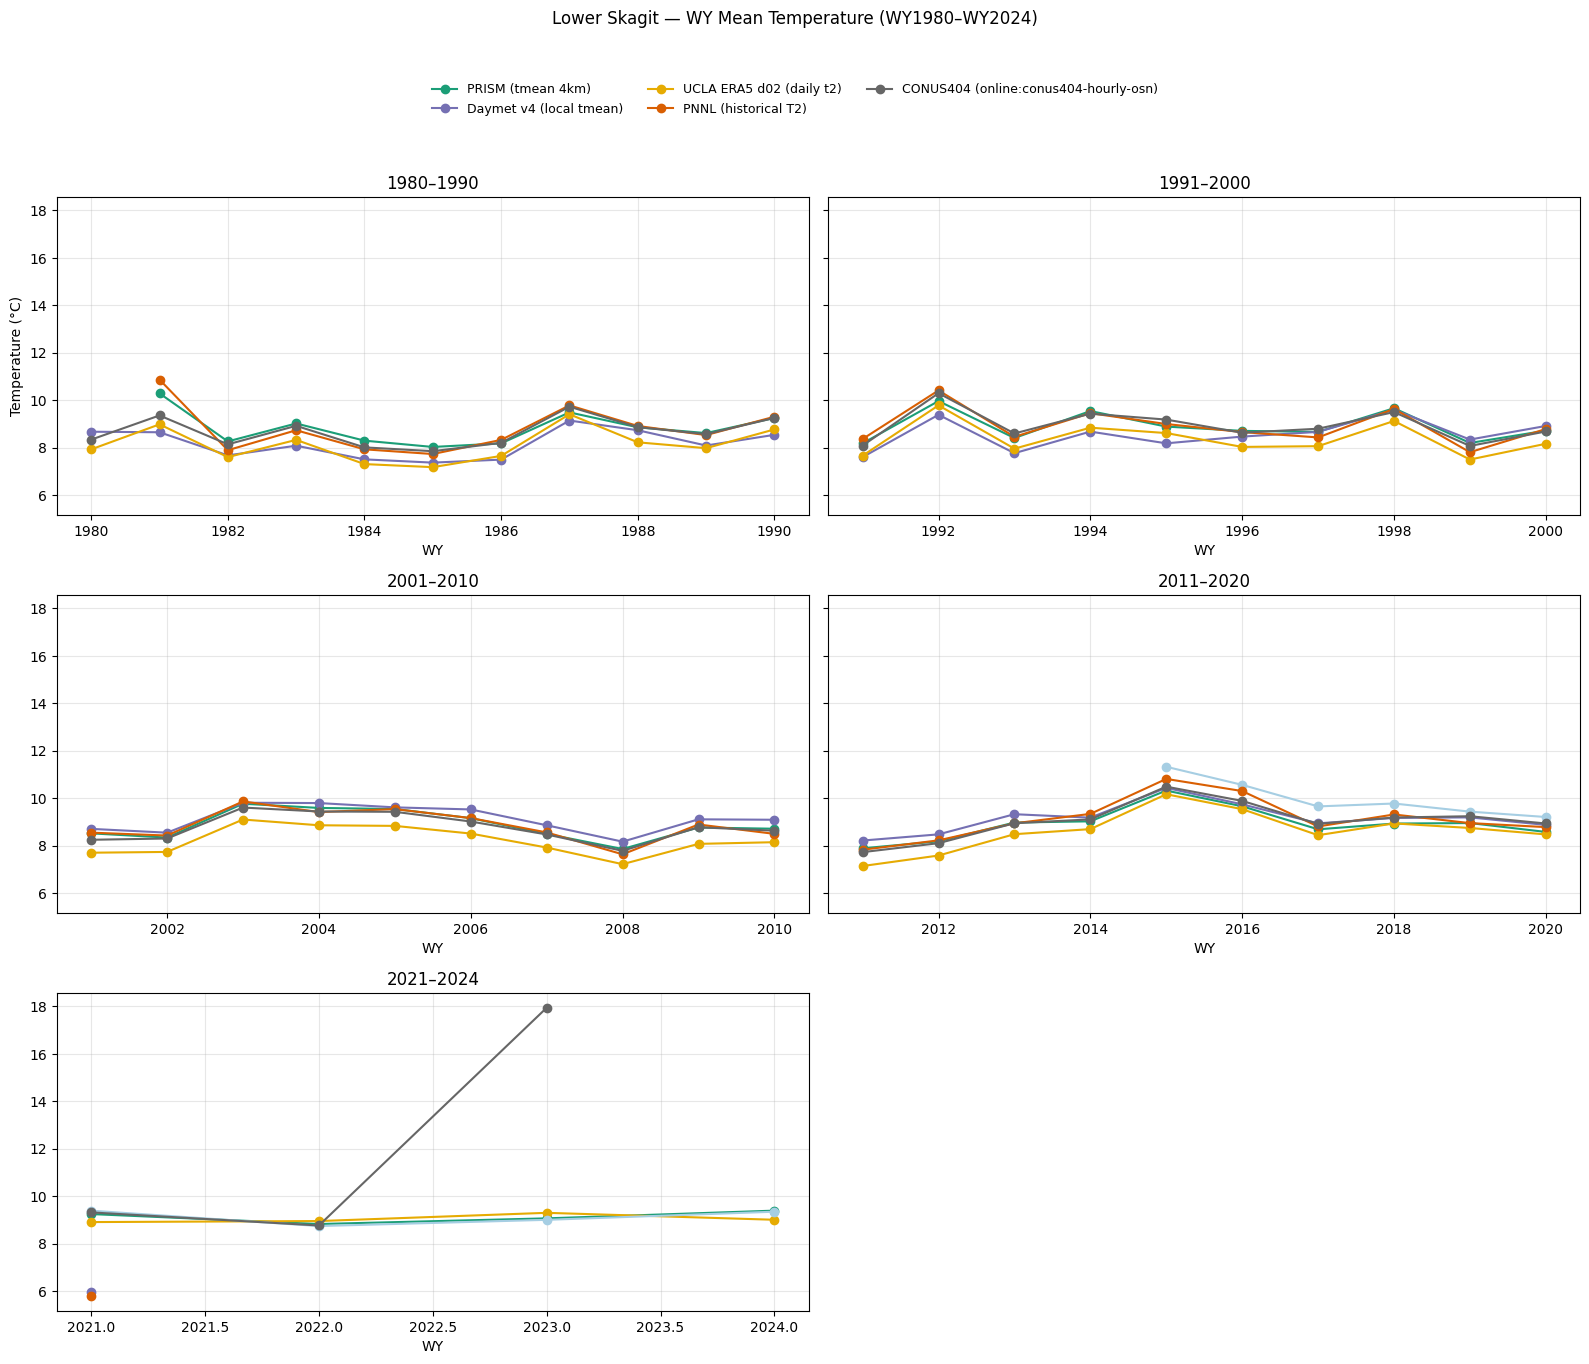

In [ ]:
# ==========================================================
# WY Mean Temperature (°C) by 3 regions (WY1980–WY2024)
#
# 
# Plot panels in 2 columns
# Legend does NOT overlap title
# PRISM reads *_daily_4km_PRISM_data.zarr OR tries to read NetCDF inside prism_tmean_us_25m_YYYYMM.zip
# ==========================================================

import re, glob, math, time, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 1980, 2024
GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

# Local datasets
P_HRRR_DIR  = BASE / "weather_data_06"   # HRRR f06 monthly zarrs
PNNL_HIST   = BASE / "PNNL" / "historical"
PNNL_GEO    = PNNL_HIST / "SERDP6km.geo_em.d01.nc"

# UCLA ERA5 d02 daily t2 files
UCLA_T2_GLOB     = "/data0/balaji24/data/ucla_era5_d02_daily/t2/t2.daily.era5.d02.*.nc"
UCLA_COORD_FILE  = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

# Daymet local yearly NetCDFs
DAYMET_DIR = "/data0/balaji24/data/daymet_nc_2014_2024"   # Contains data from 1980s
DAYMET_TMIN_GLOB = f"{DAYMET_DIR}/daymet_tmin_*.nc"
DAYMET_TMAX_GLOB = f"{DAYMET_DIR}/daymet_tmax_*.nc"

# PRISM local temperature folder (contains zarrs + PRISM monthly zips)
PRISM_TEMP_DIR = Path("/data0/balaji24/data/prism_temp_nc")
PRISM_ZIP_GLOB = "prism_tmean_us_25m_*.zip"

# ---- Exclusions ----
DAYMET_SKIP_WY = {2023}
HRRR_SKIP_WY   = {2014}

# ==========================================================
# 1) MANUAL COLOR MAP
# ==========================================================
DATASET_COLORS = {
    "PRISM 4km":     "#1B9E77",
    "Daymet-PC":     "#7570B3",
    "gridMET":       "#E7298A",
    "HRRR F01":      "#1F78B4",
    "HRRR F06":      "#A6CEE3",
    "UCLA ERA5 d02": "#E6AB02",
    "PNNL hist":     "#D95F02",
    "CONUS404":      "#666666",
    "SNOTEL (mean stations)": "#7f7f7f",
}

DATASET_ORDER = [
    "PRISM 4km",
    "Daymet-PC",
    "gridMET",
    "HRRR F01",
    "HRRR F06",
    "UCLA ERA5 d02",
    "PNNL hist",
    "CONUS404",
]

# ---------------- Helpers ----------------
def _ensure_time_name(obj):
    if isinstance(obj, xr.Dataset):
        if "time" not in obj.dims:
            for alt in ("day", "date"):
                if alt in obj.dims:
                    obj = obj.rename({alt: "time"}); break
        if "time" not in obj.coords:
            for alt in ("day", "date"):
                if alt in obj.coords:
                    obj = obj.rename({alt: "time"}); break
        return obj
    if isinstance(obj, xr.DataArray):
        if "time" not in obj.dims:
            for alt in ("day", "date"):
                if alt in obj.dims:
                    obj = obj.rename({alt: "time"}); break
        return obj
    return obj

def ensure_time_sorted_unique(da):
    da = _ensure_time_name(da)
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_celsius(da):
    da = _ensure_time_name(da)

    # remove non-finite and absurd raw fill values first
    da = xr.where(np.isfinite(da), da, np.nan)
    da = xr.where(np.abs(da) < 1e20, da, np.nan)

    try:
        probe = da.isel(time=0) if "time" in da.dims else da
        m = float(probe.mean(skipna=True).compute()) if hasattr(probe.data, "compute") else float(probe.mean(skipna=True))
    except Exception:
        m = 0.0

    # convert only if data look like Kelvin
    out = da - 273.15 if m > 150 else da

    # final sanity screen for temperature in Celsius
    out = xr.where(np.isfinite(out), out, np.nan)
    out = xr.where((out > -80) & (out < 80), out, np.nan)

    return out

def water_year_index(time_da):
    wy = xr.where(time_da.dt.month >= 10, time_da.dt.year + 1, time_da.dt.year)
    return wy.rename("year")

def water_year_mean_over_time(da):
    da = _ensure_time_name(da)
    wy = water_year_index(da["time"])
    out = da.groupby(wy).mean("time", skipna=True)
    if "year" not in out.dims:
        cand = [d for d in out.dims if d not in [dd for dd in da.dims if dd != "time"]]
        if len(cand) == 1:
            out = out.rename({cand[0]: "year"})
        elif "group" in out.dims:
            out = out.rename({"group": "year"})
    return out

def wy_start(wy): return f"{wy-1}-10-01"
def wy_end(wy):   return f"{wy}-09-30"

def pick_var(ds, candidates):
    for v in candidates:
        if v in ds.data_vars: return v
    cl = [c.lower() for c in candidates]
    for v in ds.data_vars:
        if v.lower() in cl: return v
    return None

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","lat2d","XLAT","XLAT_M","Lat","LAT"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","lon2d","XLONG","XLONG_M","Lon","LON"] if n in ds), None)
    return lat_name, lon_name

def _to_2d(arr):
    arr = _ensure_time_name(arr)
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat","lon2d","lat2d","south_north","west_east")]
        if not extra: break
        arr = arr.isel({extra[0]: 0})
    return arr

def load_regions_gdf():
    import geopandas as gpd
    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)
    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    return regions_gdf.sort_values("Name").reset_index(drop=True)

def region_mean(da, grid_ds, regions_gdf):
    """
    Robust region mean using regionmask.
    Handles lon/lat as 2D or 1D (meshgrid) and aligns dims to da.
    """
    import regionmask
    da = _ensure_time_name(da)
    grid_ds = _ensure_time_name(grid_ds)

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        return da.expand_dims(region=list(regions_gdf["Name"].values))

    lat_name, lon_name = find_lat_lon_names(grid_ds)
    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(grid_ds[lon_name])
    lat = _to_2d(grid_ds[lat_name])

    # If lon/lat are 1D, build 2D meshgrid and align dims to da spatial dims
    if lon.ndim == 1 and lat.ndim == 1 and len(spatial) == 2:
        # map lon to whichever spatial dim matches its size
        lon_dim = next((d for d in spatial if da.sizes.get(d, -1) == lon.size), None)
        lat_dim = next((d for d in spatial if da.sizes.get(d, -1) == lat.size and d != lon_dim), None)
        if lon_dim and lat_dim:
            lon2d, lat2d = np.meshgrid(lon.values, lat.values)  # shape (lat, lon)
            lon = xr.DataArray(lon2d, dims=(lat_dim, lon_dim))
            lat = xr.DataArray(lat2d, dims=(lat_dim, lon_dim))

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )
    rid = regs.mask(lon, lat)

    # align rid dims to spatial order if possible
    if set(rid.dims) == set(spatial) and list(rid.dims) != spatial:
        rid = rid.transpose(*spatial)

    out_list = []
    for i, _rname in enumerate(regs.names):
        m = (rid == i)
        if set(m.dims) == set(spatial) and list(m.dims) != spatial:
            m = m.transpose(*spatial)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(spatial, skipna=True))

    out = xr.concat(out_list, dim="region").assign_coords(region=regs.names)
    return out

def year_from_path(p):
    m = re.search(r"_(\d{4})\.nc$", p)
    return int(m.group(1)) if m else None

def good_file(p, var):
    try:
        ds = xr.open_dataset(p)
        ok = (var in ds.data_vars) and (ds.sizes.get("time", 0) > 0)
        ds.close()
        return ok
    except Exception:
        return False

def contains_xy_mask(geom, xs, ys):
    try:
        import shapely
        cx = getattr(shapely, "contains_xy", None)
        if callable(cx):
            return np.asarray(cx(geom, xs, ys), dtype=bool)
    except Exception:
        pass
    try:
        from shapely.vectorized import contains as vcontains
        return np.asarray(vcontains(geom, xs, ys), dtype=bool)
    except Exception:
        pass
    import shapely as _sh
    from shapely.prepared import prep
    pg = prep(geom)
    return np.array([pg.contains(_sh.Point(x, y)) for x, y in zip(xs, ys)], dtype=bool)

def fix_duplicate_dims_da(da: xr.DataArray) -> xr.DataArray:
    dims = list(da.dims)
    if len(dims) == len(set(dims)):
        return da
    seen, new_dims = {}, []
    for d in dims:
        seen[d] = seen.get(d, 0) + 1
        new_dims.append(d if seen[d] == 1 else f"{d}{seen[d]-1}")
    da.dims = tuple(new_dims)
    return da

def fix_duplicate_dims(ds: xr.Dataset) -> xr.Dataset:
    for name, var in ds.variables.items():
        dims = list(getattr(var, "dims", ()))
        if len(dims) == len(set(dims)):
            continue
        seen, new_dims = {}, []
        for d in dims:
            seen[d] = seen.get(d, 0) + 1
            new_dims.append(d if seen[d] == 1 else f"{d}{seen[d]-1}")
        ds[name].dims = tuple(new_dims)
    return ds

def align_mask_to_da(mask_da: xr.DataArray, da: xr.DataArray) -> xr.DataArray:
    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"Expected 2 spatial dims, got {spatial}")

    mask_da = mask_da.squeeze(drop=True)
    mask_da = fix_duplicate_dims_da(mask_da)
    if mask_da.ndim != 2:
        raise RuntimeError(f"Mask must be 2D; got dims={mask_da.dims}, shape={mask_da.shape}")

    mdims = list(mask_da.dims)

    rename_map = {}
    used_sd = set()
    for md in mdims:
        if md in spatial:
            rename_map[md] = md
            used_sd.add(md)

    remaining_md = [md for md in mdims if md not in rename_map]
    remaining_sd = [sd for sd in spatial if sd not in used_sd]

    for md in remaining_md:
        matched = None
        for sd in remaining_sd:
            if mask_da.sizes[md] == da.sizes[sd]:
                matched = sd
                break
        if matched is None:
            raise RuntimeError(
                f"Could not map mask dim '{md}' (size={mask_da.sizes[md]}) "
                f"to any of {remaining_sd} with sizes {[da.sizes[s] for s in remaining_sd]}"
            )
        rename_map[md] = matched
        remaining_sd.remove(matched)

    m = mask_da.rename(rename_map)

    if set(m.dims) == set(spatial) and list(m.dims) != spatial:
        m = m.transpose(*spatial)

    if (m.sizes.get(spatial[0], -1) != da.sizes[spatial[0]]) or (m.sizes.get(spatial[1], -1) != da.sizes[spatial[1]]):
        raise RuntimeError(
            f"Mask shape {(m.sizes.get(spatial[0]), m.sizes.get(spatial[1]))} "
            f"does not match data grid {(da.sizes[spatial[0]], da.sizes[spatial[1]])}"
        )
    return m

def open_daymet_year(path_nc: str, var: str) -> xr.Dataset:
    ds = xr.open_dataset(path_nc, engine="netcdf4")
    ds = _ensure_time_name(ds)
    if var not in ds:
        ds.close()
        raise KeyError(f"{path_nc} missing var={var}")
    if "x" in ds.coords:
        ds = ds.sortby("x")
    if "y" in ds.coords:
        ds = ds.sortby("y")
    if "time" in ds.coords:
        tt = pd.to_datetime(ds["time"].values)
        _, idx = np.unique(tt, return_index=True)
        ds = ds.isel(time=np.sort(idx))
    return ds[[var]]

def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def _detect_prism_temp_var(ds):
    candidates = ["tmean", "tavg", "tmean_c", "tmean_degC", "Tmean", "temp", "tas"]
    for v in candidates:
        if v in ds.data_vars:
            return v
    for v in ds.data_vars:
        vl = v.lower()
        if "tmean" in vl or "tavg" in vl or ("temp" in vl and "mean" in vl):
            return v
    return None

# ==========================================================
# Plot helpers
# ==========================================================
YEAR_WINDOWS = [(1980, 1990), (1991, 2000), (2001, 2010), (2011, 2020), (2021, 2024)]
PANEL_NCOLS = 2 

def _dataset_color(dsname: str) -> str:
    if dsname in DATASET_COLORS:
        return DATASET_COLORS[dsname]
    return "#000000"

def _stable_dataset_list(datasets_present: list[str]) -> list[str]:
    present = list(dict.fromkeys(datasets_present))
    
    other = [d for d in present if d != "SNOTEL (mean stations)"]
    out = []
    for d in DATASET_ORDER:
        if d in other:
            out.append(d)
    for d in other:
        if d not in out:
            out.append(d)
    
    return out

def _compute_ylim_for_region(region_df: pd.DataFrame, snotel_df: pd.DataFrame | None) -> tuple[float, float] | None:
    vals = []
    if not region_df.empty:
        vals.extend(region_df["temp_c"].astype(float).to_list())
    if snotel_df is not None and not snotel_df.empty:
        vals.extend(snotel_df["temp_c"].astype(float).to_list())

    vals = [v for v in vals if np.isfinite(v) and (-30 <= v <= 30)]
    if not vals:
        return None

    vmin, vmax = float(np.min(vals)), float(np.max(vals))
    pad = 1.0 if np.isclose(vmin, vmax) else 0.05 * (vmax - vmin)
    return (vmin - pad, vmax + pad)


def plot_region_panels_2cols(df_all: pd.DataFrame, region: str, snotel_df: pd.DataFrame):
    sub = df_all[df_all["region"] == region].copy()
    if sub.empty:
        print(f"[PLOT] No data for region={region}")
        return

    datasets = _stable_dataset_list(sub["dataset"].unique().tolist())
    ylim = _compute_ylim_for_region(sub[sub["dataset"] != "SNOTEL (mean stations)"], snotel_df)
    if ylim is None:
        ylim = _compute_ylim_for_region(sub, snotel_df)

    n_panels = len(YEAR_WINDOWS)
    ncols = PANEL_NCOLS
    nrows = int(math.ceil(n_panels / ncols))

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(16, 4.6 * nrows),
        sharey=True
    )
    axes = np.array(axes).reshape(nrows, ncols)

    for k, (a, b) in enumerate(YEAR_WINDOWS):
        i, j = divmod(k, ncols)
        ax = axes[i, j]

        w = sub[(sub["year"] >= a) & (sub["year"] <= b)].copy()
        for dsname in datasets:
            g = w[w["dataset"] == dsname].sort_values("year").copy()
            g = g[np.isfinite(g["temp_c"]) & g["temp_c"].between(-30, 30)]
            if g.empty:
                continue
            ax.plot(
                g["year"], g["temp_c"].astype(float),
                marker="o", linewidth=1.5,
                label=str(dsname),
                color=_dataset_color(str(dsname)),
            )

        # SNOTEL overlay (if you ever add it to df)
        if snotel_df is not None and not snotel_df.empty:
            sb = snotel_df[(snotel_df["year"] >= a) & (snotel_df["year"] <= b)].copy()
            if not sb.empty:
                ax.plot(
                    sb["year"], sb["temp_c"].astype(float),
                    marker="o", linestyle="--", linewidth=1.5,
                    label="SNOTEL (mean stations) — basin ref",
                    color=_dataset_color("SNOTEL (mean stations)"),
                )

        ax.set_title(f"{a}–{b}")
        ax.set_xlabel("WY")
        ax.grid(True, alpha=0.3)
        if ylim is not None:
            ax.set_ylim(*ylim)

    # hide unused last axis (since 5 panels in 3x2)
    for k in range(n_panels, nrows * ncols):
        i, j = divmod(k, ncols)
        axes[i, j].axis("off")

    axes[0, 0].set_ylabel("Temperature (°C)")

    # Title + legend spacing (no overlap)
    fig.suptitle(f"{region} — WY Mean Temperature (WY{YEAR_MIN}–WY{YEAR_MAX})", y=0.985)

    # legend from first axes that has handles
    handles, labels = [], []
    for ax in axes.ravel():
        h, l = ax.get_legend_handles_labels()
        if h:
            handles, labels = h, l
            break

    # de-dupe legend
    seen = set()
    h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l in seen:
            continue
        seen.add(l)
        h2.append(h); l2.append(l)

    # place legend below title
    fig.legend(h2, l2, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncol=3, fontsize=9, frameon=False)

    # reserve top space for title+legend
    plt.tight_layout(rect=[0, 0, 1, 0.90])
        # Save to graphs_2 directory as requested
    out_dir = Path("/home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs_2")
    out_dir.mkdir(parents=True, exist_ok=True)
    fname = f"wy_mean_temp_{region.replace(' ', '_')}_standardized.png"
    plt.savefig(out_dir / fname, dpi=300, bbox_inches='tight')
    print(f"[PLOT] Saved to {out_dir / fname}")
    
        # Save to graphs_2 directory as requested
    out_dir = Path("/home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs_2")
    out_dir.mkdir(parents=True, exist_ok=True)
    fname = f"wy_mean_temp_{region.replace(' ', '_')}_standardized.png"
    plt.savefig(out_dir / fname, dpi=300, bbox_inches='tight')
    print(f"[PLOT] Saved to {out_dir / fname}")
    
        # Save to graphs_2 directory as requested
    out_dir = Path("/home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs_2")
    out_dir.mkdir(parents=True, exist_ok=True)
    fname = f"wy_mean_temp_{region.replace(' ', '_')}_standardized.png"
    plt.savefig(out_dir / fname, dpi=300, bbox_inches='tight')
    print(f"[PLOT] Saved to {out_dir / fname}")
    
        # Save to graphs_2 directory as requested
    out_dir = Path("/home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs_2")
    out_dir.mkdir(parents=True, exist_ok=True)
    fname = f"wy_mean_temp_{region.replace(' ', '_')}_standardized.png"
    plt.savefig(out_dir / fname, dpi=300, bbox_inches='tight')
    print(f"[PLOT] Saved to {out_dir / fname}")
    
    plt.show()


# ==========================================================
# RUN: Build df
# ==========================================================
regions_gdf = load_regions_gdf()
rows = []

# ==========================================================
# 1) Daymet LOCAL
# ==========================================================
print("[DAYMET-LOCAL] Computing WY mean tmean from local NetCDFs...")
try:
    tmin_files = sorted(glob.glob(DAYMET_TMIN_GLOB))
    tmax_files = sorted(glob.glob(DAYMET_TMAX_GLOB))

    tmin_good = {year_from_path(f): f for f in tmin_files if year_from_path(f) is not None and good_file(f, "tmin")}
    tmax_good = {year_from_path(f): f for f in tmax_files if year_from_path(f) is not None and good_file(f, "tmax")}

    years = sorted([y for y in range(YEAR_MIN-1, YEAR_MAX+1) if (y in tmin_good and y in tmax_good)])
    if not years:
        raise RuntimeError("No overlapping good tmin/tmax years found.")

    dsmin_list, dsmax_list = [], []
    for y in years:
        dsmin_list.append(open_daymet_year(tmin_good[y], "tmin"))
        dsmax_list.append(open_daymet_year(tmax_good[y], "tmax"))

    ds_min = xr.concat(dsmin_list, dim="time", join="outer", coords="minimal", compat="override").sortby("time")
    ds_max = xr.concat(dsmax_list, dim="time", join="outer", coords="minimal", compat="override").sortby("time")

    tmin = ensure_time_sorted_unique(ds_min["tmin"])
    tmax = ensure_time_sorted_unique(ds_max["tmax"])
    tmin2, tmax2 = xr.align(tmin, tmax, join="inner")

    tmean = to_celsius((tmin2 + tmax2) / 2.0).sel(time=slice(GLOBAL_START, GLOBAL_END))
    rm = ensure_time_sorted_unique(region_mean(tmean, grid_ds=ds_min, regions_gdf=regions_gdf))
    wy = water_year_mean_over_time(rm)

    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        if wy_i in DAYMET_SKIP_WY:  
            continue
        if wy_i not in wy["year"].values:
            continue
        for rgn in wy["region"].values:
            val = float(wy.sel(year=wy_i, region=rgn).values)
            if np.isfinite(val):
                rows.append({"dataset": "Daymet-PC", "region": str(rgn), "year": int(wy_i), "temp_c": float(val)})

    for d in dsmin_list:
        try: d.close()
        except Exception: pass
    for d in dsmax_list:
        try: d.close()
        except Exception: pass
    try: ds_min.close()
    except Exception: pass
    try: ds_max.close()
    except Exception: pass

    print("[DAYMET-LOCAL] Success.")
except Exception as e:
    print("[DAYMET-LOCAL] FAILED:", repr(e))

# ==========================================================
# Helpers for the PRISM block
# ==========================================================
def _parse_prism_zarr_year_range(p: Path):
    m = re.match(
        r"^(\d{4})-\d{2}-\d{2}_(\d{4})-\d{2}-\d{2}_daily_4km_PRISM_data\.zarr$",
        p.name
    )
    if not m:
        return None
    return int(m.group(1)), int(m.group(2))

def _prepare_prism_da(da: xr.DataArray) -> xr.DataArray:
    if "time" not in da.dims:
        tdim = next(
            (d for d in da.dims if "time" in d.lower() or "day" in d.lower() or "date" in d.lower()),
            None
        )
        if tdim:
            da = da.rename({tdim: "time"})
    da = ensure_time_sorted_unique(da)
    return da

def _month_keys_from_time(time_vals) -> set[str]:
    tt = pd.to_datetime(time_vals)
    return set(tt.to_period("M").astype(str).tolist())

def _extract_prism_nc_from_zip(zpath: Path, cache_dir: Path) -> Path | None:
    cache_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zpath, "r") as zf:
        members = zf.namelist()
        nc_members = [m for m in members if m.lower().endswith(".nc")]
        if not nc_members:
            return None

        inner = nc_members[0]
        out = cache_dir / f"{zpath.stem}.nc"
        if out.exists():
            return out

        zf.extract(inner, path=cache_dir)
        extracted = cache_dir / inner

        out.parent.mkdir(parents=True, exist_ok=True)
        if extracted.resolve() != out.resolve():
            if out.exists():
                out.unlink()
            extracted.rename(out)

        return out
    
# ==========================================================
# 1b) PRISM temp (ROBUST: zarr first, then fill missing months from zips)
# ==========================================================
print("[PRISM-TEMP] Computing WY mean tmean from local PRISM...")
try:
    prism_rm_parts = []
    loaded_months = set()
    zarr_year_spans_used = []

    target_months = set(
        pd.date_range(GLOBAL_START, GLOBAL_END, freq="MS").strftime("%Y-%m").tolist()
    )

    # ------------------------------------------------------
    # A) Read usable zarrs, but drop redundant contained ones
    # ------------------------------------------------------
    prism_zarrs_all = sorted(
        [p for p in PRISM_TEMP_DIR.glob("*_daily_4km_PRISM_data.zarr") if p.is_dir()]
    )

    zarr_info = []
    for p in prism_zarrs_all:
        yr = _parse_prism_zarr_year_range(p)
        if yr is not None:
            zarr_info.append((p, yr[0], yr[1]))

    # Sort by start year asc, end year desc so bigger windows come first
    zarr_info = sorted(zarr_info, key=lambda x: (x[1], -x[2]))

    selected_zarrs = []
    for p, ys, ye in zarr_info:
        contained = any((ys >= s and ye <= e) for _, s, e in selected_zarrs)
        if not contained:
            selected_zarrs.append((p, ys, ye))

    if selected_zarrs:
        print("[PRISM-TEMP] Selected zarr windows:")
        for p, ys, ye in selected_zarrs:
            print(f"  - {p.name}  ({ys}..{ye})")

    for p, ys, ye in selected_zarrs:
        try:
            ds = safe_open_zarr(p)
            v = _detect_prism_temp_var(ds)
            if v is None:
                print(f"[PRISM-TEMP] Skip zarr (no temp var): {p.name}")
                try: ds.close()
                except Exception: pass
                continue

            da = ds[v]
            da = _prepare_prism_da(da)
            if "time" not in da.dims:
                print(f"[PRISM-TEMP] Skip zarr (no time dim): {p.name}")
                try: ds.close()
                except Exception: pass
                continue

            da = to_celsius(da).sel(time=slice(GLOBAL_START, GLOBAL_END))
            if da.sizes.get("time", 0) == 0:
                print(f"[PRISM-TEMP] Skip zarr (empty after slice): {p.name}")
                try: ds.close()
                except Exception: pass
                continue

            rm = region_mean(da, grid_ds=ds, regions_gdf=regions_gdf)
            rm = ensure_time_sorted_unique(rm).load()   # small after reduction
            prism_rm_parts.append(rm)

            loaded_months |= _month_keys_from_time(rm["time"].values)
            zarr_year_spans_used.append((ys, ye, p.name))

            print(
                f"[PRISM-TEMP] Used zarr: {p.name} | var={v} | "
                f"time={str(pd.to_datetime(rm.time.values[0]).date())} -> {str(pd.to_datetime(rm.time.values[-1]).date())}"
            )

            try: ds.close()
            except Exception: pass

        except Exception as e:
            print(f"[PRISM-TEMP] Failed zarr {p.name}: {repr(e)}")

    # ------------------------------------------------------
    # B) Fill missing months from monthly zip files
    # ------------------------------------------------------
    prism_zips = sorted(PRISM_TEMP_DIR.glob(PRISM_ZIP_GLOB))
    cache_dir = PRISM_TEMP_DIR / "_prism_nc_cache"

    zip_used = 0
    zip_missing_nc = 0
    zip_skipped_already_covered = 0

    ym_re = re.compile(r"_(\d{6})$")

    for zp in prism_zips:
        m = ym_re.search(zp.stem)
        if not m:
            continue

        ym = m.group(1)              # e.g. 201401
        month_key = f"{ym[:4]}-{ym[4:]}"   # e.g. 2014-01

        if month_key not in target_months:
            continue
        if month_key in loaded_months:
            zip_skipped_already_covered += 1
            continue

        nc_path = _extract_prism_nc_from_zip(zp, cache_dir)
        if nc_path is None:
            zip_missing_nc += 1
            continue

        try:
            ds = xr.open_dataset(nc_path, engine="netcdf4")
            ds = _ensure_time_name(ds)

            v = _detect_prism_temp_var(ds)
            if v is None:
                print(f"[PRISM-TEMP] Zip nc has no temp var: {zp.name}")
                ds.close()
                continue

            da = ds[v]
            da = _prepare_prism_da(da)
            if "time" not in da.dims:
                print(f"[PRISM-TEMP] Zip nc has no time dim: {zp.name}")
                ds.close()
                continue

            da = to_celsius(da).sel(time=slice(GLOBAL_START, GLOBAL_END))
            if da.sizes.get("time", 0) == 0:
                ds.close()
                continue

            rm = region_mean(da, grid_ds=ds, regions_gdf=regions_gdf)
            rm = ensure_time_sorted_unique(rm).load()
            prism_rm_parts.append(rm)

            loaded_months |= _month_keys_from_time(rm["time"].values)
            zip_used += 1

            print(f"[PRISM-TEMP] Filled month from zip: {zp.name} | var={v}")

            ds.close()

        except Exception as e:
            print(f"[PRISM-TEMP] Failed zip {zp.name}: {repr(e)}")

    # ------------------------------------------------------
    # C) Final combine
    # ------------------------------------------------------
    if not prism_rm_parts:
        raise RuntimeError("No usable PRISM data found from either zarrs or zips.")

    prism_rm = xr.concat(prism_rm_parts, dim="time", join="outer", coords="minimal", compat="override")
    prism_rm = ensure_time_sorted_unique(prism_rm)
    prism_rm = prism_rm.sel(time=slice(GLOBAL_START, GLOBAL_END))

    prism_wy = water_year_mean_over_time(prism_rm)

    prism_years_added = []
    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        if wy_i not in prism_wy["year"].values:
            continue
        added_this_year = False
        for rgn in prism_wy["region"].values:
            val = float(prism_wy.sel(year=wy_i, region=rgn).values)
            if np.isfinite(val):
                rows.append({
                    "dataset": "PRISM 4km",
                    "region": str(rgn),
                    "year": int(wy_i),
                    "temp_c": float(val),
                })
                added_this_year = True
        if added_this_year:
            prism_years_added.append(wy_i)

    print("[PRISM-TEMP] Success.")
    print(f"[PRISM-TEMP] WY years added: {prism_years_added}")
    print(f"[PRISM-TEMP] Zip months used: {zip_used}")
    print(f"[PRISM-TEMP] Zip months skipped (already covered by zarr): {zip_skipped_already_covered}")
    print(f"[PRISM-TEMP] Zip files without nc inside: {zip_missing_nc}")

except Exception as e:
    print("[PRISM-TEMP] SKIP/FAILED:", repr(e))
    
# ==========================================================
# 2) UCLA ERA5 d02
# ==========================================================
print("[UCLA] Computing WY mean t2 from local NetCDFs (coord-mask, per region)...")
try:
    files = sorted(glob.glob(UCLA_T2_GLOB))
    if not files:
        raise RuntimeError(f"No UCLA files matched: {UCLA_T2_GLOB}")
    if not UCLA_COORD_FILE.exists():
        raise RuntimeError(f"Missing UCLA coord file: {UCLA_COORD_FILE}")

    g = xr.open_dataset(UCLA_COORD_FILE, engine="netcdf4")
    lat2d = g["lat2d"].squeeze(drop=True).astype("float64")
    lon2d = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    regions_ll = regions_gdf.to_crs("EPSG:4326")
    lonv = lon2d.values.ravel()
    latv = lat2d.values.ravel()
    ny, nx = lon2d.shape

    ucla_region_masks = {}
    for rname in REGION_NAMES:
        geom = regions_ll.loc[regions_ll["Name"] == rname, "geometry"].iloc[0]
        m_flat = contains_xy_mask(geom, lonv, latv)
        mask2d = m_flat.reshape(ny, nx).astype(bool)
        ucla_region_masks[rname] = xr.DataArray(mask2d, dims=lon2d.dims, coords=lon2d.coords)

    ds_u = xr.open_mfdataset(files, combine="by_coords", parallel=False, join="outer")
    ds_u = _ensure_time_name(ds_u)

    v = pick_var(ds_u, ["t2", "T2", "t2m", "tas", "temp"])
    if v is None:
        raise RuntimeError(f"Could not find temperature variable in UCLA ds. Vars head={list(ds_u.data_vars)[:30]}")

    da = to_celsius(ensure_time_sorted_unique(ds_u[v]).sel(time=slice(GLOBAL_START, GLOBAL_END)))
    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"Unexpected UCLA spatial dims: {spatial}")

    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        sub = da.sel(time=slice(wy_start(wy_i), wy_end(wy_i)))
        if sub.sizes.get("time", 0) == 0:
            continue
        for rname in REGION_NAMES:
            m = align_mask_to_da(ucla_region_masks[rname], sub)
            bm_daily = sub.where(m).mean(dim=spatial, skipna=True)
            wy_mean = float(bm_daily.mean("time", skipna=True).values)
            if np.isfinite(wy_mean):
                rows.append({"dataset": "UCLA ERA5 d02", "region": str(rname), "year": int(wy_i), "temp_c": float(wy_mean)})

    ds_u.close()
except Exception as e:
    print("[UCLA] FAILED:", repr(e))

# ==========================================================
# 3) HRRR06
# ==========================================================
print(f"[HRRR06] Computing WY mean temp from monthly zarrs (t2m) in {P_HRRR_DIR} ...")
try:
    monthly = sorted(P_HRRR_DIR.glob("*.zarr")) if P_HRRR_DIR.exists() else []
    monthly = [p for p in monthly if re.match(r"^\d{4}-\d{2}.*\.zarr$", p.name)]
    if not monthly:
        raise RuntimeError(f"No HRRR06 monthly zarrs found in {P_HRRR_DIR} (expected names starting with YYYY-MM)")

    need_prefixes = set(pd.date_range(GLOBAL_START, GLOBAL_END, freq="MS").strftime("%Y-%m").tolist())
    parts = sorted([p for p in monthly if p.name[:7] in need_prefixes], key=lambda p: p.name[:7])
    if not parts:
        raise RuntimeError("No overlapping HRRR06 months for this window")

    ds0 = xr.open_zarr(parts[0], consolidated=False)
    if "t2m" not in ds0:
        raise RuntimeError(f"HRRR06 missing 't2m' in {parts[0].name}. Vars={list(ds0.data_vars)[:30]}")

    dsets = [xr.open_zarr(p, consolidated=False)[["t2m"]] for p in parts]
    ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override")

    da = to_celsius(ensure_time_sorted_unique(ds["t2m"]))
    daily = da.resample(time="1D").mean()
    rm_daily = ensure_time_sorted_unique(region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)).sel(time=slice(GLOBAL_START, GLOBAL_END))
    wy = water_year_mean_over_time(rm_daily)

    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        if wy_i in HRRR_SKIP_WY:  
            continue
        if wy_i not in wy["year"].values:
            continue
        for r in wy["region"].values:
            val = float(wy.sel(year=wy_i, region=r).values)
            if np.isfinite(val):
                rows.append({"dataset": "HRRR F06", "region": str(r), "year": int(wy_i), "temp_c": float(val)})

    for d in dsets:
        try: d.close()
        except Exception: pass
    try: ds.close()
    except Exception: pass
    try: ds0.close()
    except Exception: pass

    print("[HRRR06] Success.")
except Exception as e:
    print("[HRRR06] SKIP/FAILED:", repr(e))

# ==========================================================
# 4) PNNL (geo_em masks)
# ==========================================================
print("[PNNL] Computing WY mean temp from historical T2 using geo_em lat/lon masks...")
try:
    import regionmask

    if not PNNL_HIST.exists():
        raise RuntimeError("Missing PNNL_HIST")
    if not PNNL_GEO.exists():
        raise RuntimeError(f"Missing PNNL geo_em file: {PNNL_GEO}")

    geo = xr.open_dataset(PNNL_GEO)
    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat2 = _to_2d(geo[lat_name]).astype("float64")
    lon2 = _to_2d(geo[lon_name]).astype("float64")

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )
    rid = regs.mask(lon2, lat2)

    pnnl_masks_np = {r: np.asarray((rid == i).data, dtype=bool) for i, r in enumerate(regs.names)}
    rid_dims = rid.dims
    rid_coords = {d: rid[d] for d in rid.dims if d in rid.coords}
    geo.close()

    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        files = []
        files += sorted(glob.glob(str(PNNL_HIST / f"{wy_i-1}" / "*T2*.nc")))
        files += sorted(glob.glob(str(PNNL_HIST / f"{wy_i}"   / "*T2*.nc")))
        if not files:
            continue

        def _preprocess(ds):
            return ds[["T2"]] if "T2" in ds.data_vars else ds

        dsp = xr.open_mfdataset(
            files, combine="by_coords", engine="netcdf4", parallel=False,
            preprocess=_preprocess, chunks={"time": 24 * 7}, join="outer"
        )
        dsp = _ensure_time_name(dsp)
        dsp = fix_duplicate_dims(dsp)

        if "T2" not in dsp:
            dsp.close(); continue

        t2 = ensure_time_sorted_unique(dsp["T2"]).sel(time=slice(wy_start(wy_i), wy_end(wy_i)))
        if t2.sizes.get("time", 0) == 0:
            dsp.close(); continue

        t2_daily = to_celsius(t2).resample(time="1D").mean()
        spatial = [d for d in t2_daily.dims if d != "time"]
        if len(spatial) != 2:
            dsp.close()
            raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

        for rname in REGION_NAMES:
            m_geo = xr.DataArray(pnnl_masks_np[rname], dims=rid_dims, coords=rid_coords)
            m = align_mask_to_da(m_geo, t2_daily)
            bm = t2_daily.where(m).mean(dim=spatial, skipna=True)
            wy_mean = float(bm.mean("time", skipna=True).values)
            if np.isfinite(wy_mean):
                rows.append({"dataset": "PNNL hist", "region": str(rname), "year": int(wy_i), "temp_c": float(wy_mean)})

        dsp.close()

except Exception as e:
    print("[PNNL] SKIP/FAILED:", repr(e))

# ==========================================================
# 5) CONUS404 online 
# ==========================================================
print("[CONUS404-online] Loading via HyTEST intake (best-effort)...")
try:
    import intake
    ds_cat = intake.open_catalog("https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml")
    conus_url = ds_cat["conus404-catalog"].path
    conus_cat = intake.open_catalog(conus_url)

    osn_keys = [k for k in list(conus_cat) if "osn" in k.lower()]
    if not osn_keys:
        raise RuntimeError("No OSN entries found in CONUS404 catalog")
    used_key = osn_keys[0]

    ds_c = conus_cat[used_key].to_dask()
    ds_c = fix_duplicate_dims(ds_c)
    if "lon" in ds_c: ds_c["lon"] = fix_duplicate_dims_da(ds_c["lon"])
    if "lat" in ds_c: ds_c["lat"] = fix_duplicate_dims_da(ds_c["lat"])

    v = pick_var(ds_c, ["t2m", "tas", "T2", "temp", "temperature"])
    if v is None:
        raise RuntimeError(f"No temp var found. Vars head={list(ds_c.data_vars)[:30]}")

    da = to_celsius(ensure_time_sorted_unique(ds_c[v]).sel(time=slice(GLOBAL_START, GLOBAL_END)))
    rm = ensure_time_sorted_unique(region_mean(da, grid_ds=ds_c, regions_gdf=regions_gdf))
    wy = water_year_mean_over_time(rm)

    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        if wy_i not in wy["year"].values:
            continue
        for rgn in wy["region"].values:
            val = float(wy.sel(year=wy_i, region=rgn).values)
            if np.isfinite(val):
                rows.append({"dataset": "CONUS404", "region": str(rgn), "year": int(wy_i), "temp_c": float(val)})

    print(f"[CONUS404-online] Success: {used_key} var={v}")

except Exception as e:
    print("[CONUS404-online] SKIP/FAILED:", repr(e))

# ==========================================================
# Build df
# ==========================================================
df = (
    pd.DataFrame(rows)
      .groupby(["dataset","region","year"], as_index=False)
      .agg(temp_c=("temp_c","mean"))
      .sort_values(["region","dataset","year"])
      .reset_index(drop=True)
)
df = df[(df["year"] >= YEAR_MIN) & (df["year"] <= YEAR_MAX)].copy()

# ==========================================================
# Final QC
# ==========================================================
df["temp_c"] = pd.to_numeric(df["temp_c"], errors="coerce")

bad_df = df[
    (~np.isfinite(df["temp_c"])) |
    (df["temp_c"] < -30) |
    (df["temp_c"] > 30)
].copy()

if not bad_df.empty:
    print("\n[QC] Dropping suspicious WY mean temperatures:")
    print(bad_df.sort_values(["region", "dataset", "year"]).to_string(index=False))

df = df[
    np.isfinite(df["temp_c"]) &
    (df["temp_c"] >= -30) &
    (df["temp_c"] <= 30)
].copy()

print("\n[FINAL] Available datasets:", sorted(df["dataset"].unique().tolist()))
print(df.head(10))

# SNOTEL placeholder 
snotel = df[(df["dataset"] == "SNOTEL (mean stations)") & (df["region"] == "All Stations")].copy().sort_values("year")

# ==========================================================
# Plot each region (2 columns layout)
# ==========================================================
for region in REGION_NAMES:
    plot_region_panels_2cols(df, region, snotel)


[DAYMET-LOCAL] Computing seasonal mean temperature from local NetCDFs...
[DAYMET-LOCAL] Success.
[PRISM-TEMP] Computing seasonal mean temperature from local PRISM...


/tmp/ipykernel_463580/473460493.py:479: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  out = xr.concat(out_list, dim="region").assign_coords(region=regs.names)
/tmp/ipykernel_463580/473460493.py:479: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  out = xr.concat(out_list, dim="region").assign_coords(region=regs.nam

[PRISM-TEMP] Success.
[UCLA] Computing seasonal mean temperature from local NetCDFs...
[UCLA] Success.
[HRRR F06] Computing seasonal mean temperature from monthly zarrs in /data0/balaji24/data/weather_data_06 ...


/tmp/ipykernel_463580/473460493.py:479: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  out = xr.concat(out_list, dim="region").assign_coords(region=regs.names)
/tmp/ipykernel_463580/473460493.py:479: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  out = xr.concat(out_list, dim="region").assign_coords(region=regs.nam

[HRRR F06] Success.
[PNNL] Computing seasonal mean temperature from historical T2 using geo_em masks...
[PNNL] Success.
[CONUS404] Loading via HyTEST intake (best-effort)...


/tmp/ipykernel_463580/473460493.py:479: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  out = xr.concat(out_list, dim="region").assign_coords(region=regs.names)


[CONUS404] SKIP/FAILED: RuntimeError("Zstd decompression error: b'Data corruption detected'")

[FINAL] Available datasets: ['CONUS404', 'Daymet-PC', 'HRRR F06', 'PNNL hist', 'PRISM 4km', 'UCLA ERA5 d02']
    dataset       region season  year    temp_c
0  CONUS404  Full Skagit    DJF  1981  0.039899
1  CONUS404  Full Skagit    DJF  1982 -4.204014
2  CONUS404  Full Skagit    DJF  1983 -1.028442
3  CONUS404  Full Skagit    DJF  1984 -3.401836
4  CONUS404  Full Skagit    DJF  1985 -3.852572
5  CONUS404  Full Skagit    DJF  1986 -1.212462
6  CONUS404  Full Skagit    DJF  1987 -1.326120
7  CONUS404  Full Skagit    DJF  1988 -2.806331
8  CONUS404  Full Skagit    DJF  1989 -4.129283
9  CONUS404  Full Skagit    DJF  1990 -2.075430
Saved CSV → /data0/balaji24/data/derived/met_season_temp_skagit_regions_1980_2024_ALL.csv
Saved plot → /data0/balaji24/data/derived/met_season_temp_Upper_Skagit_1980_2024_WINDOWS.png


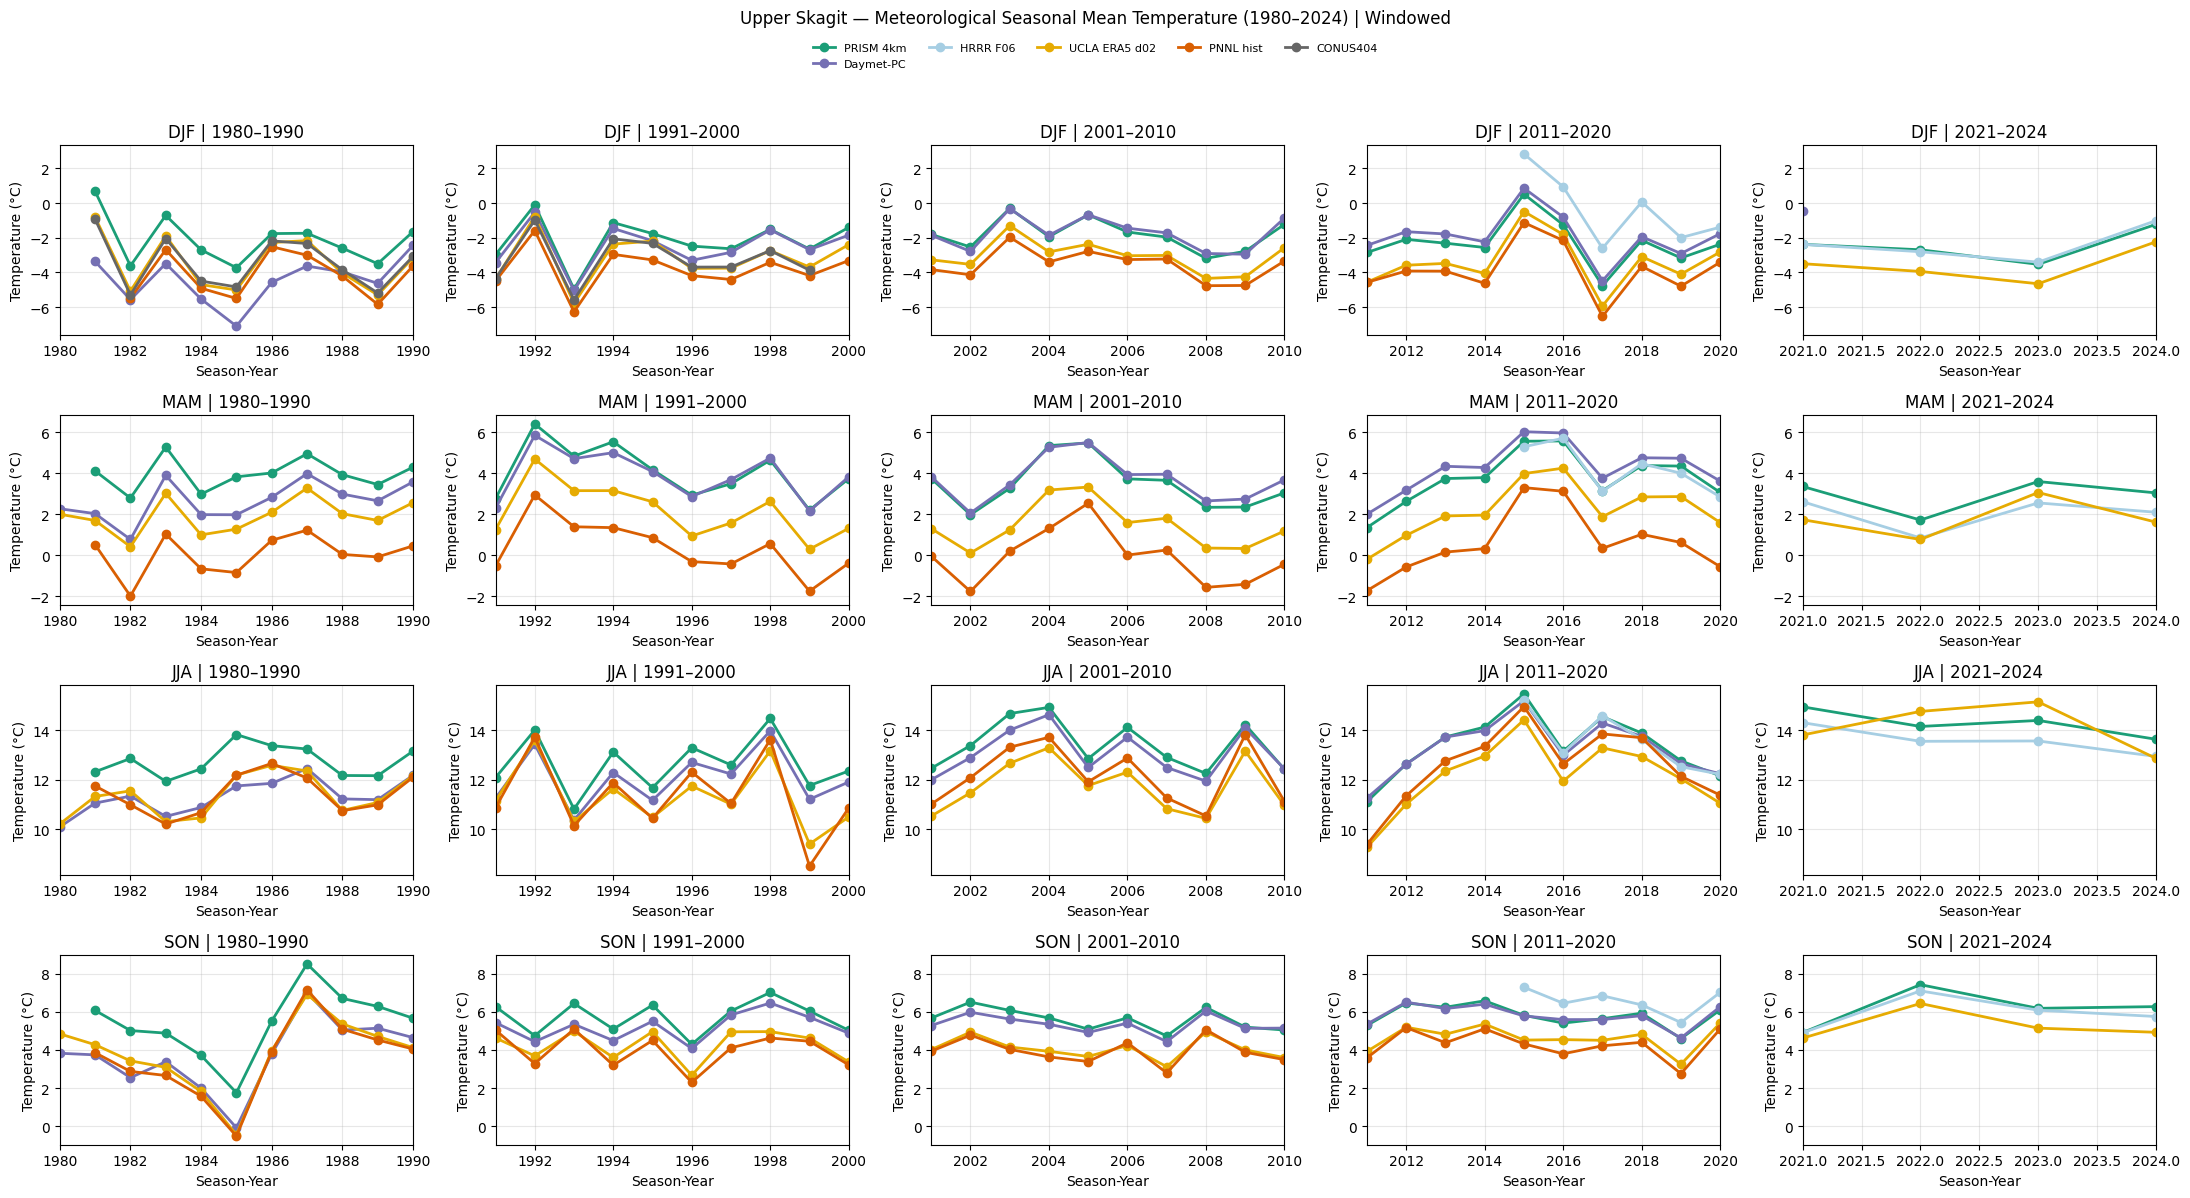

Saved plot → /data0/balaji24/data/derived/met_season_temp_Sauk_1980_2024_WINDOWS.png


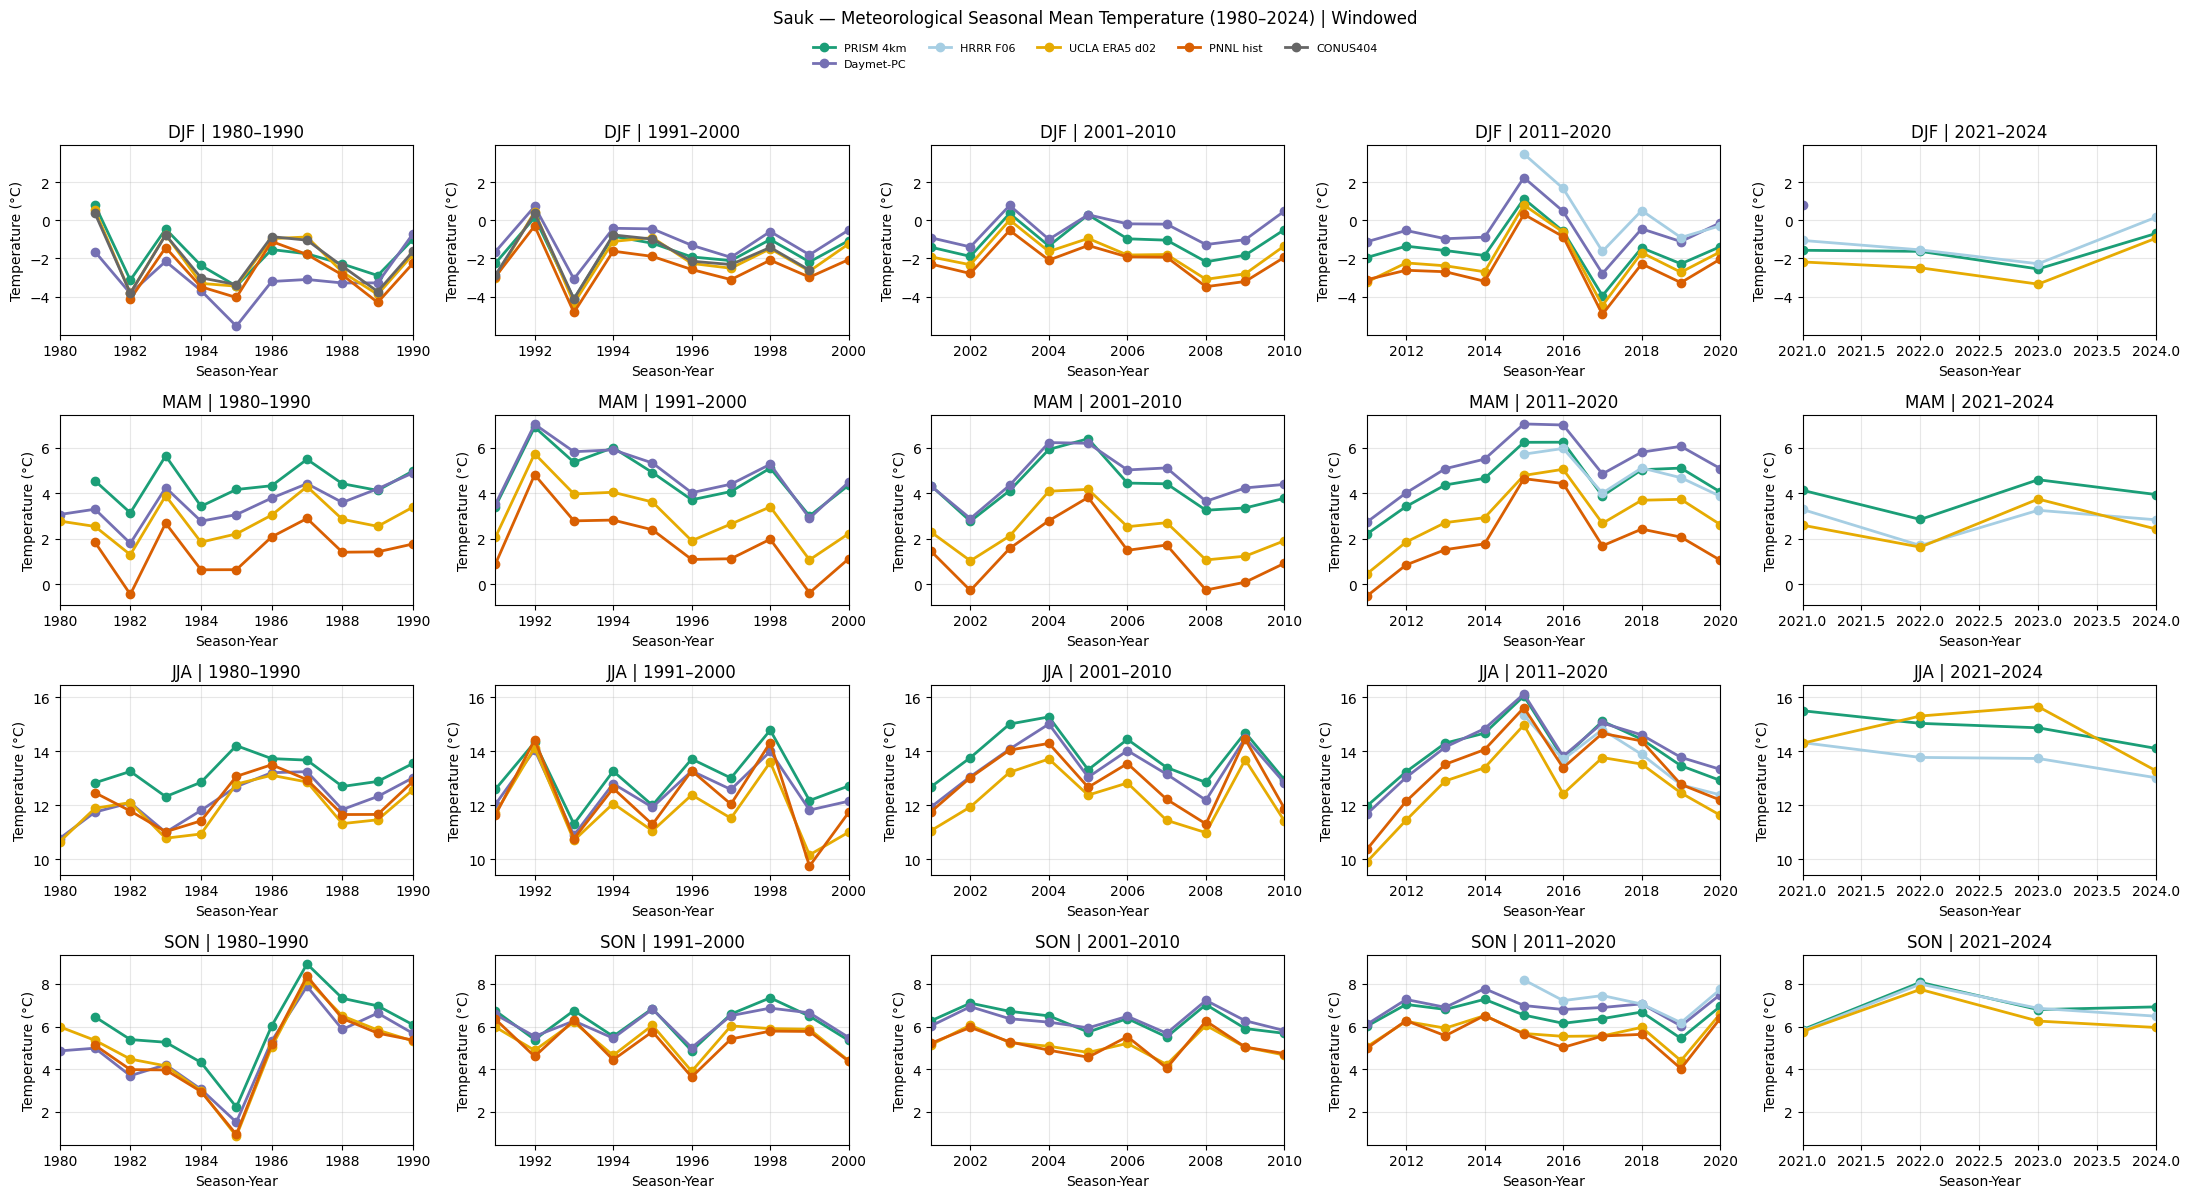

Saved plot → /data0/balaji24/data/derived/met_season_temp_Lower_Skagit_1980_2024_WINDOWS.png


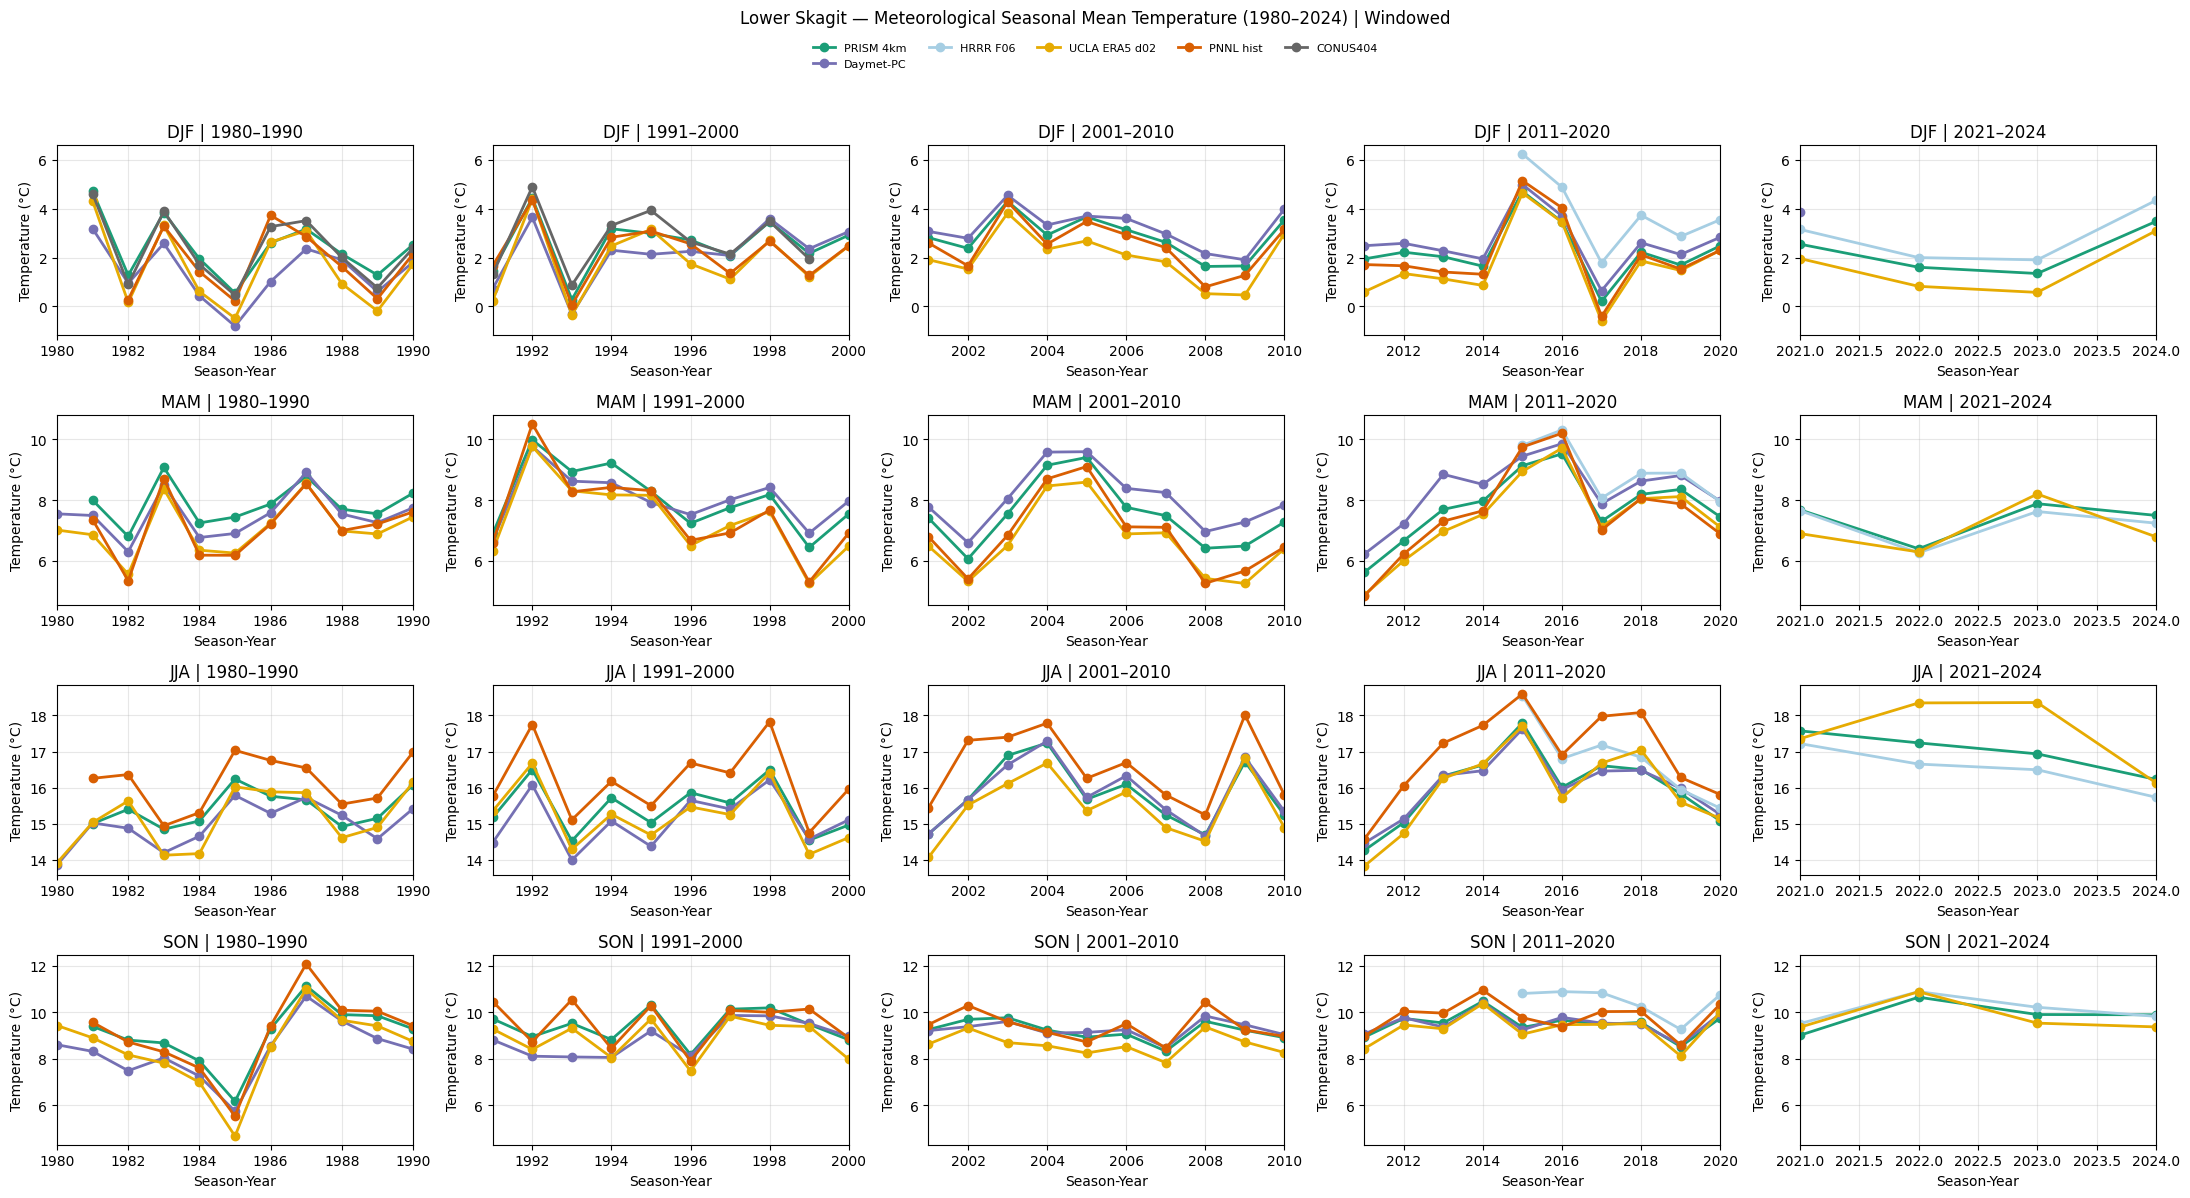

Saved plot → /data0/balaji24/data/derived/met_season_temp_Full_Skagit_1980_2024_WINDOWS.png


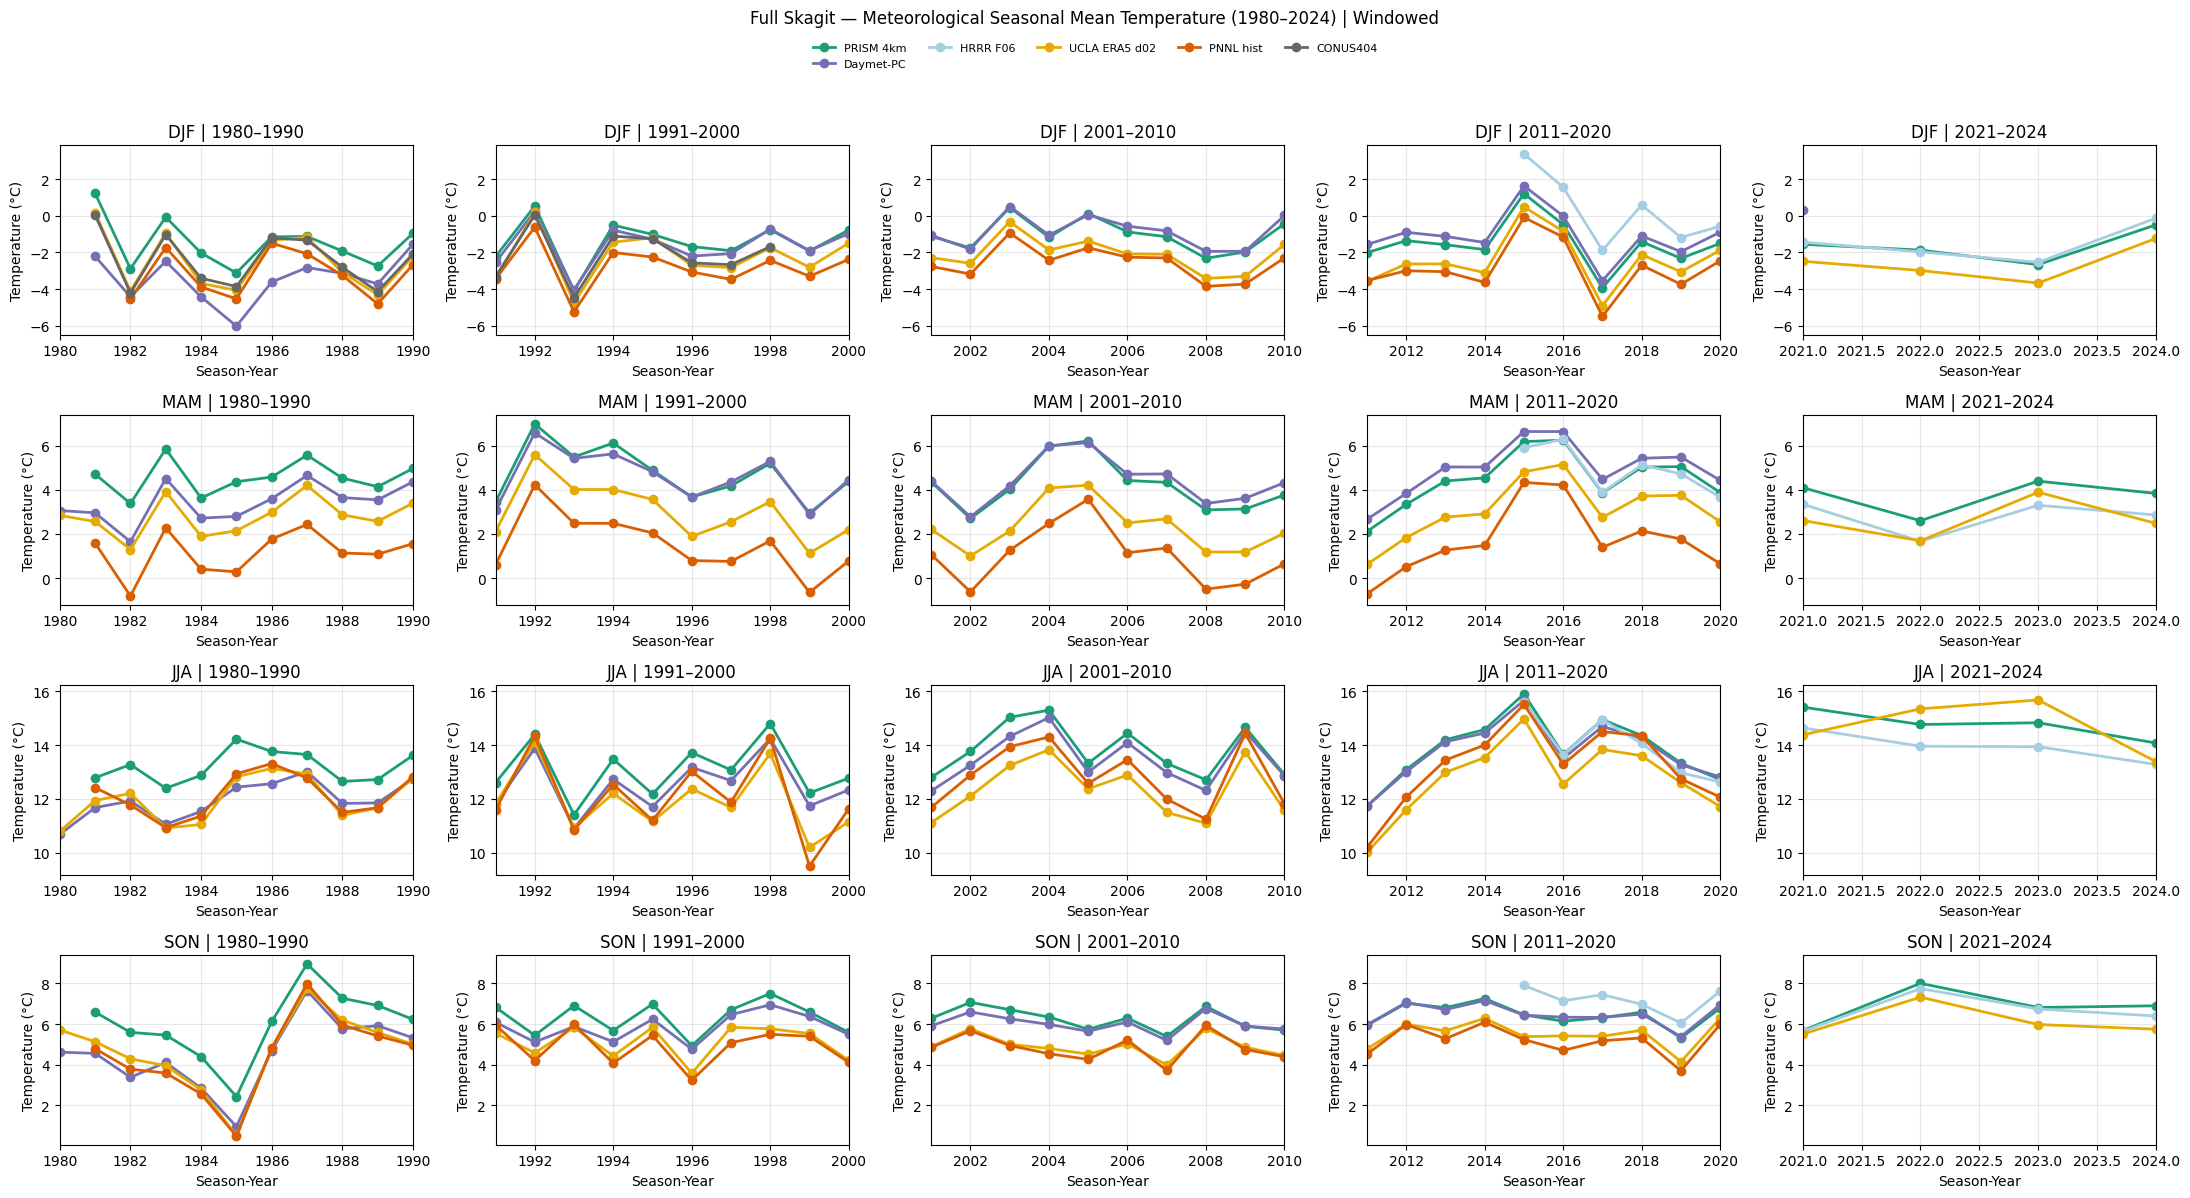

Saved MAE CSV → /data0/balaji24/data/derived/met_season_temp_mae_vs_PRISM_4km_1980_2024.csv
Saved plot → /data0/balaji24/data/derived/met_season_temp_mae_vs_PRISM_4km_Upper_Skagit_1980_2024_WINDOWS.png


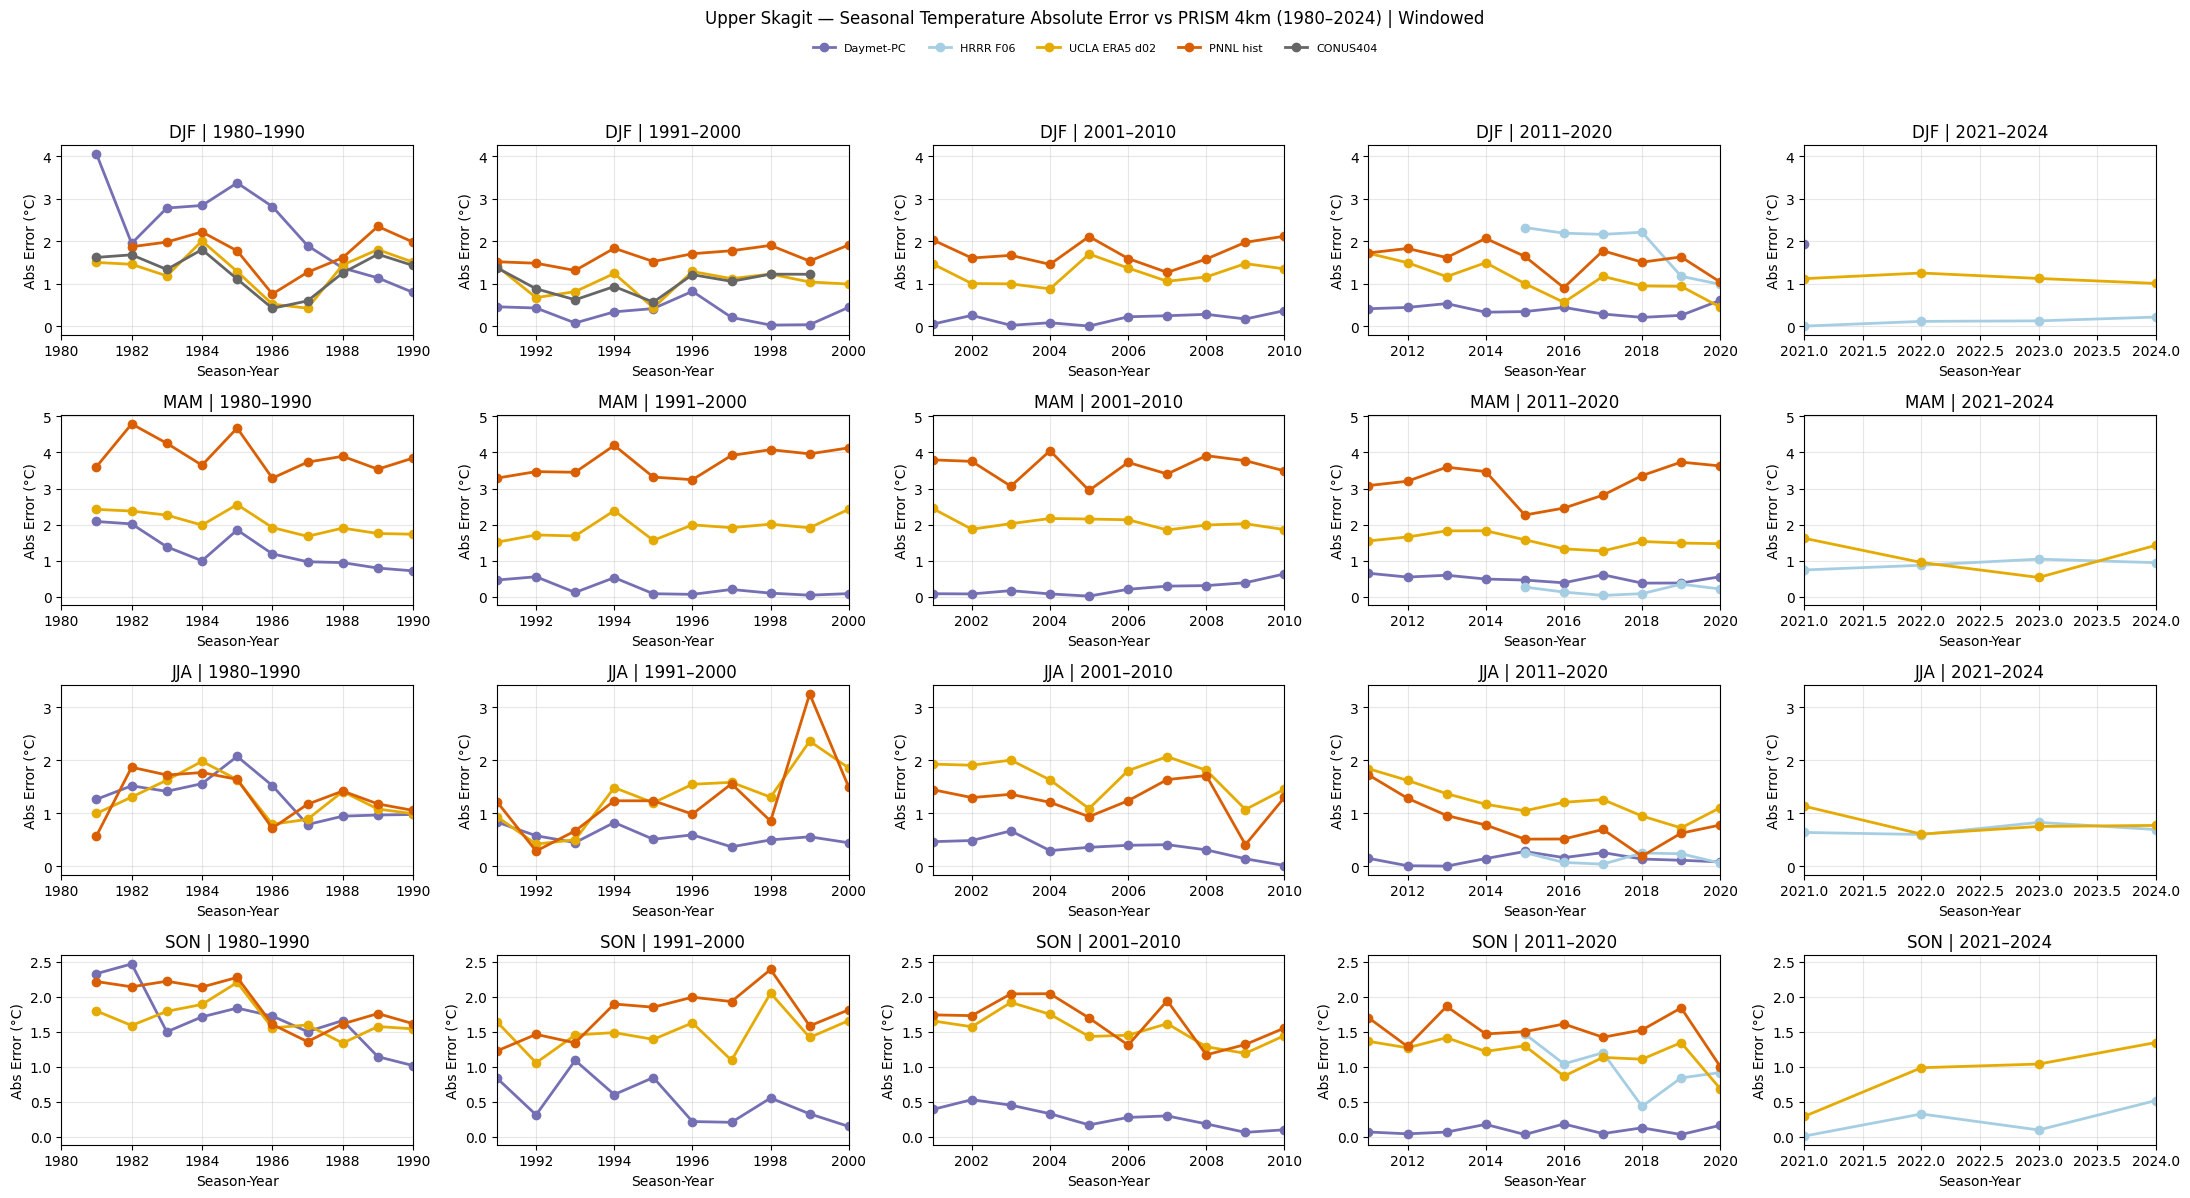

Saved plot → /data0/balaji24/data/derived/met_season_temp_mae_vs_PRISM_4km_Sauk_1980_2024_WINDOWS.png


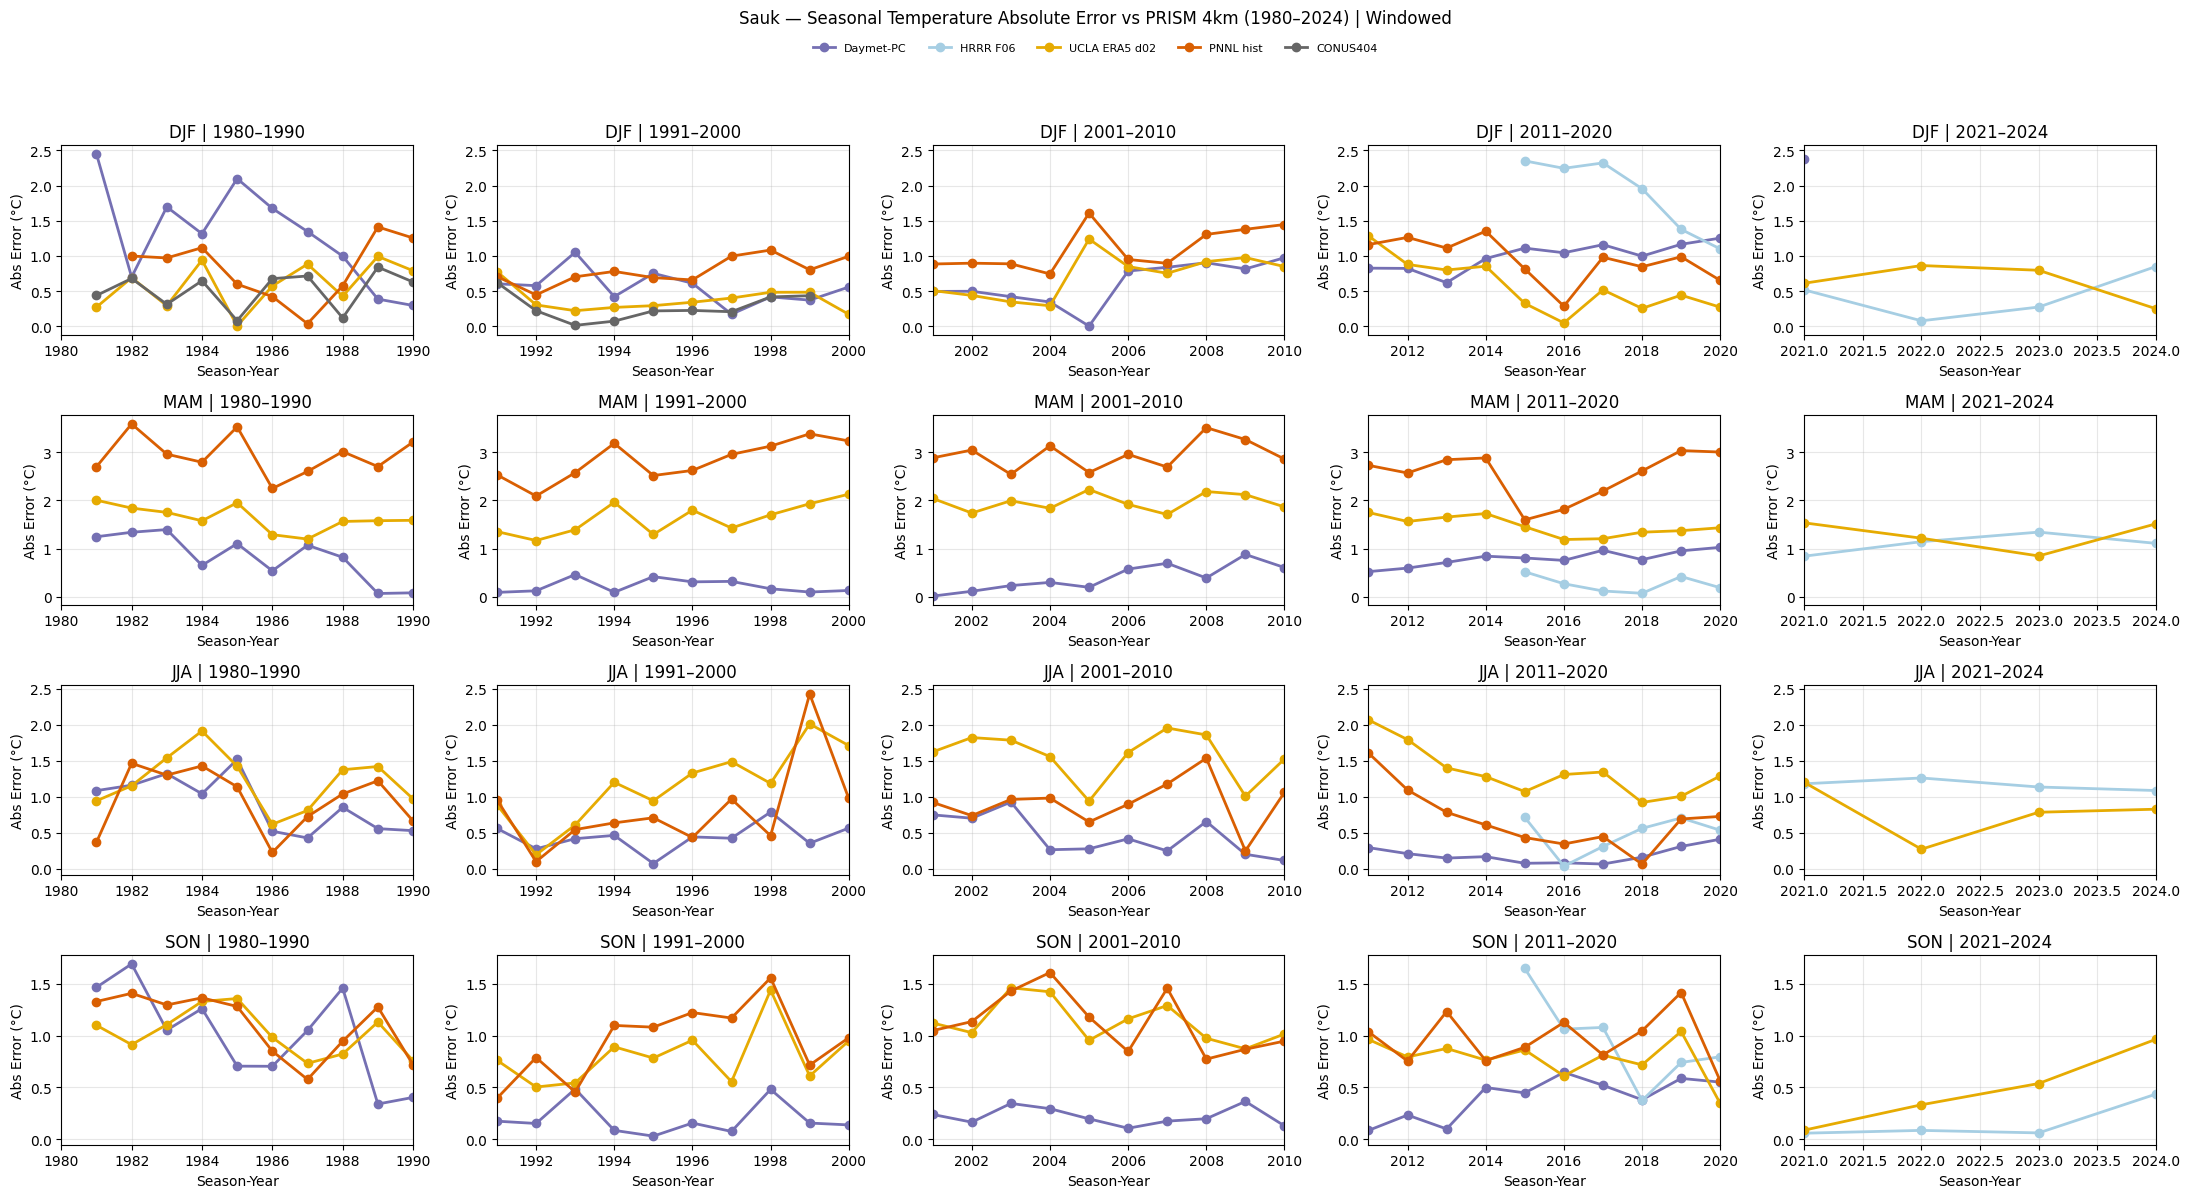

Saved plot → /data0/balaji24/data/derived/met_season_temp_mae_vs_PRISM_4km_Lower_Skagit_1980_2024_WINDOWS.png


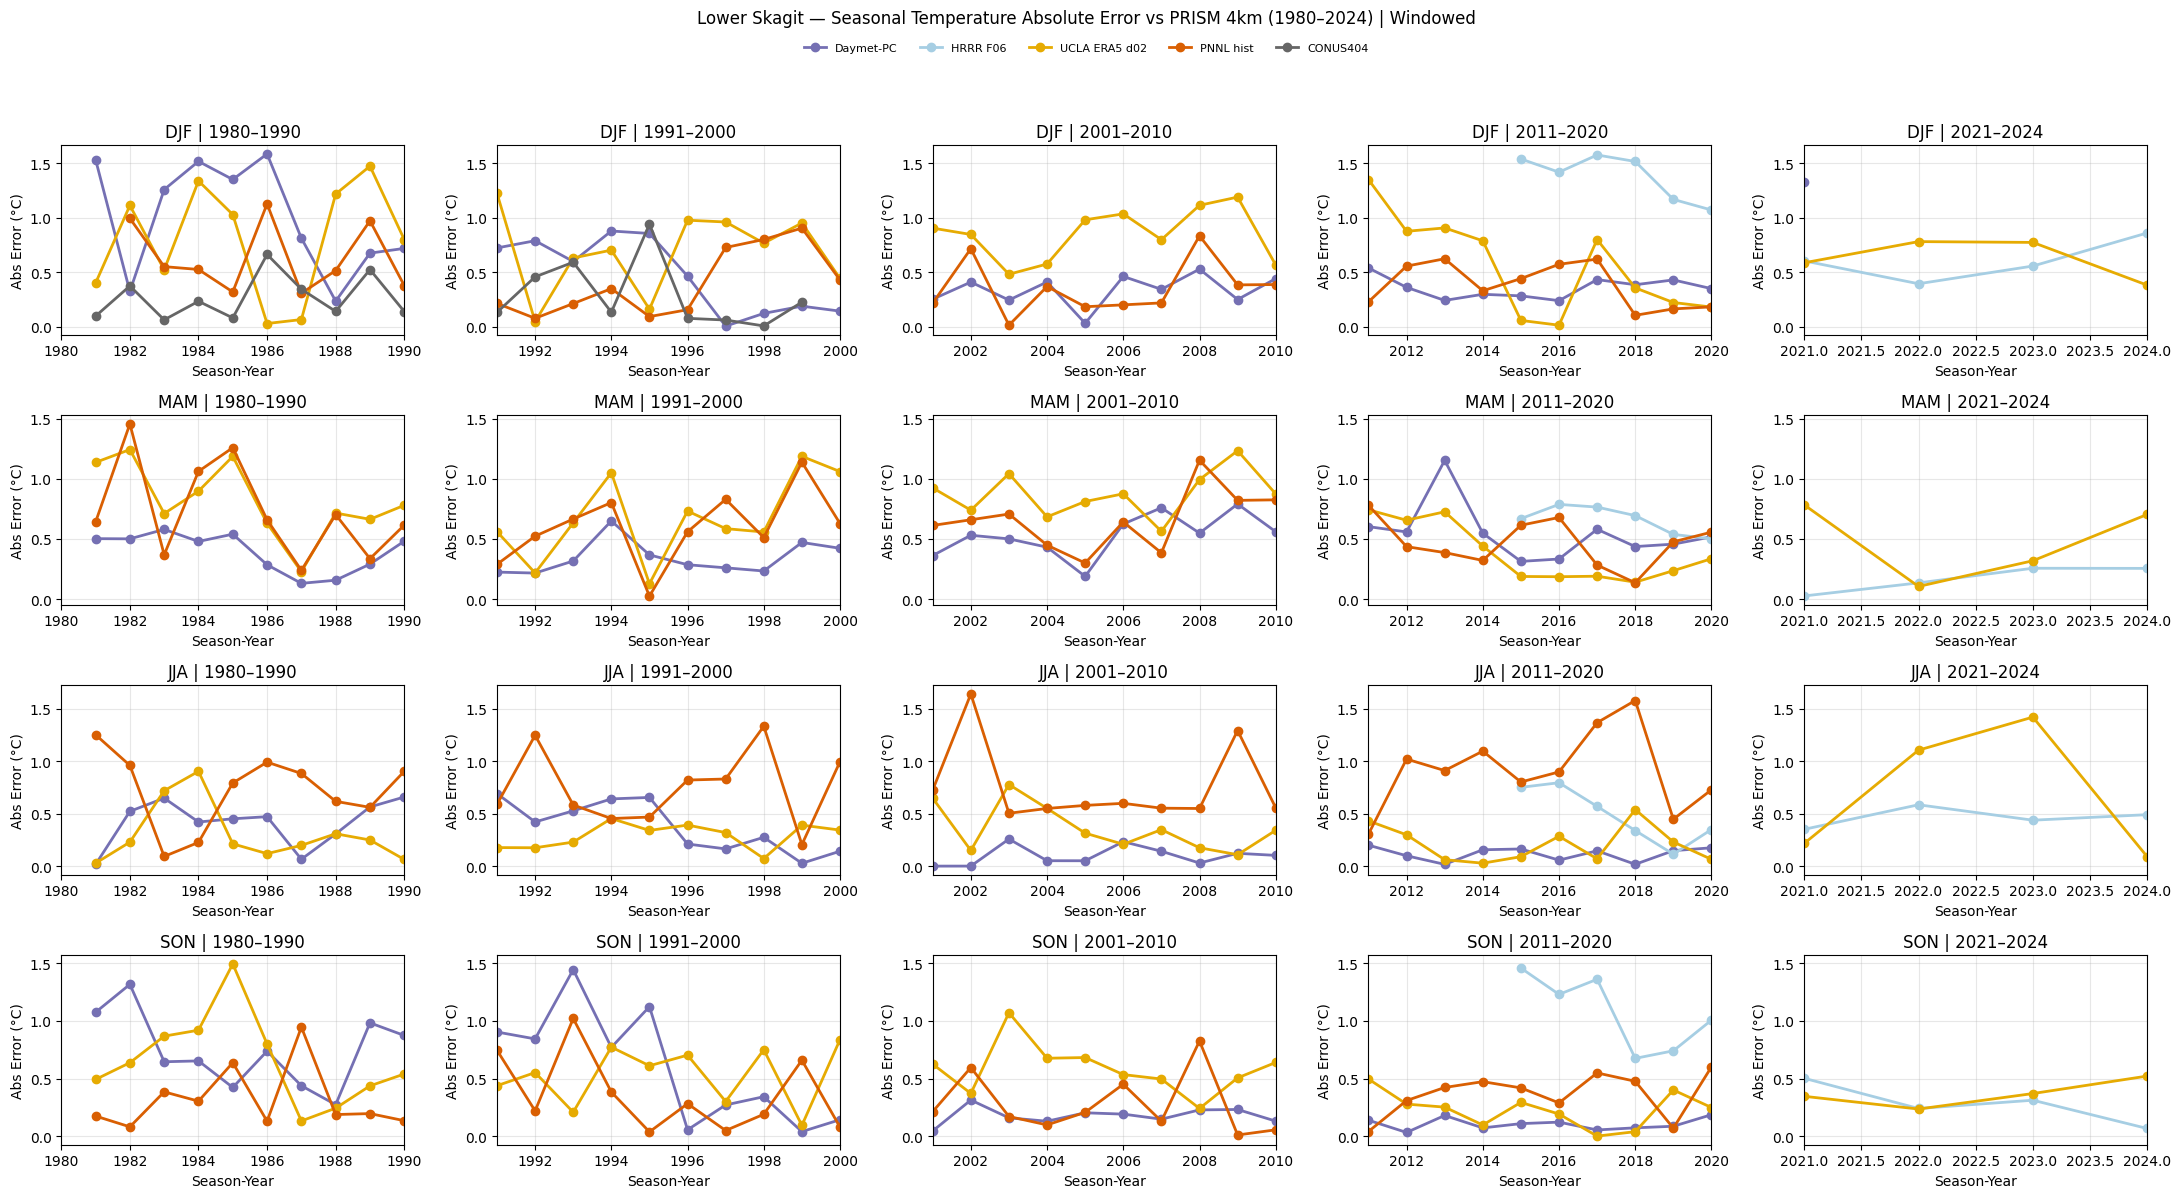

Saved plot → /data0/balaji24/data/derived/met_season_temp_mae_vs_PRISM_4km_Full_Skagit_1980_2024_WINDOWS.png


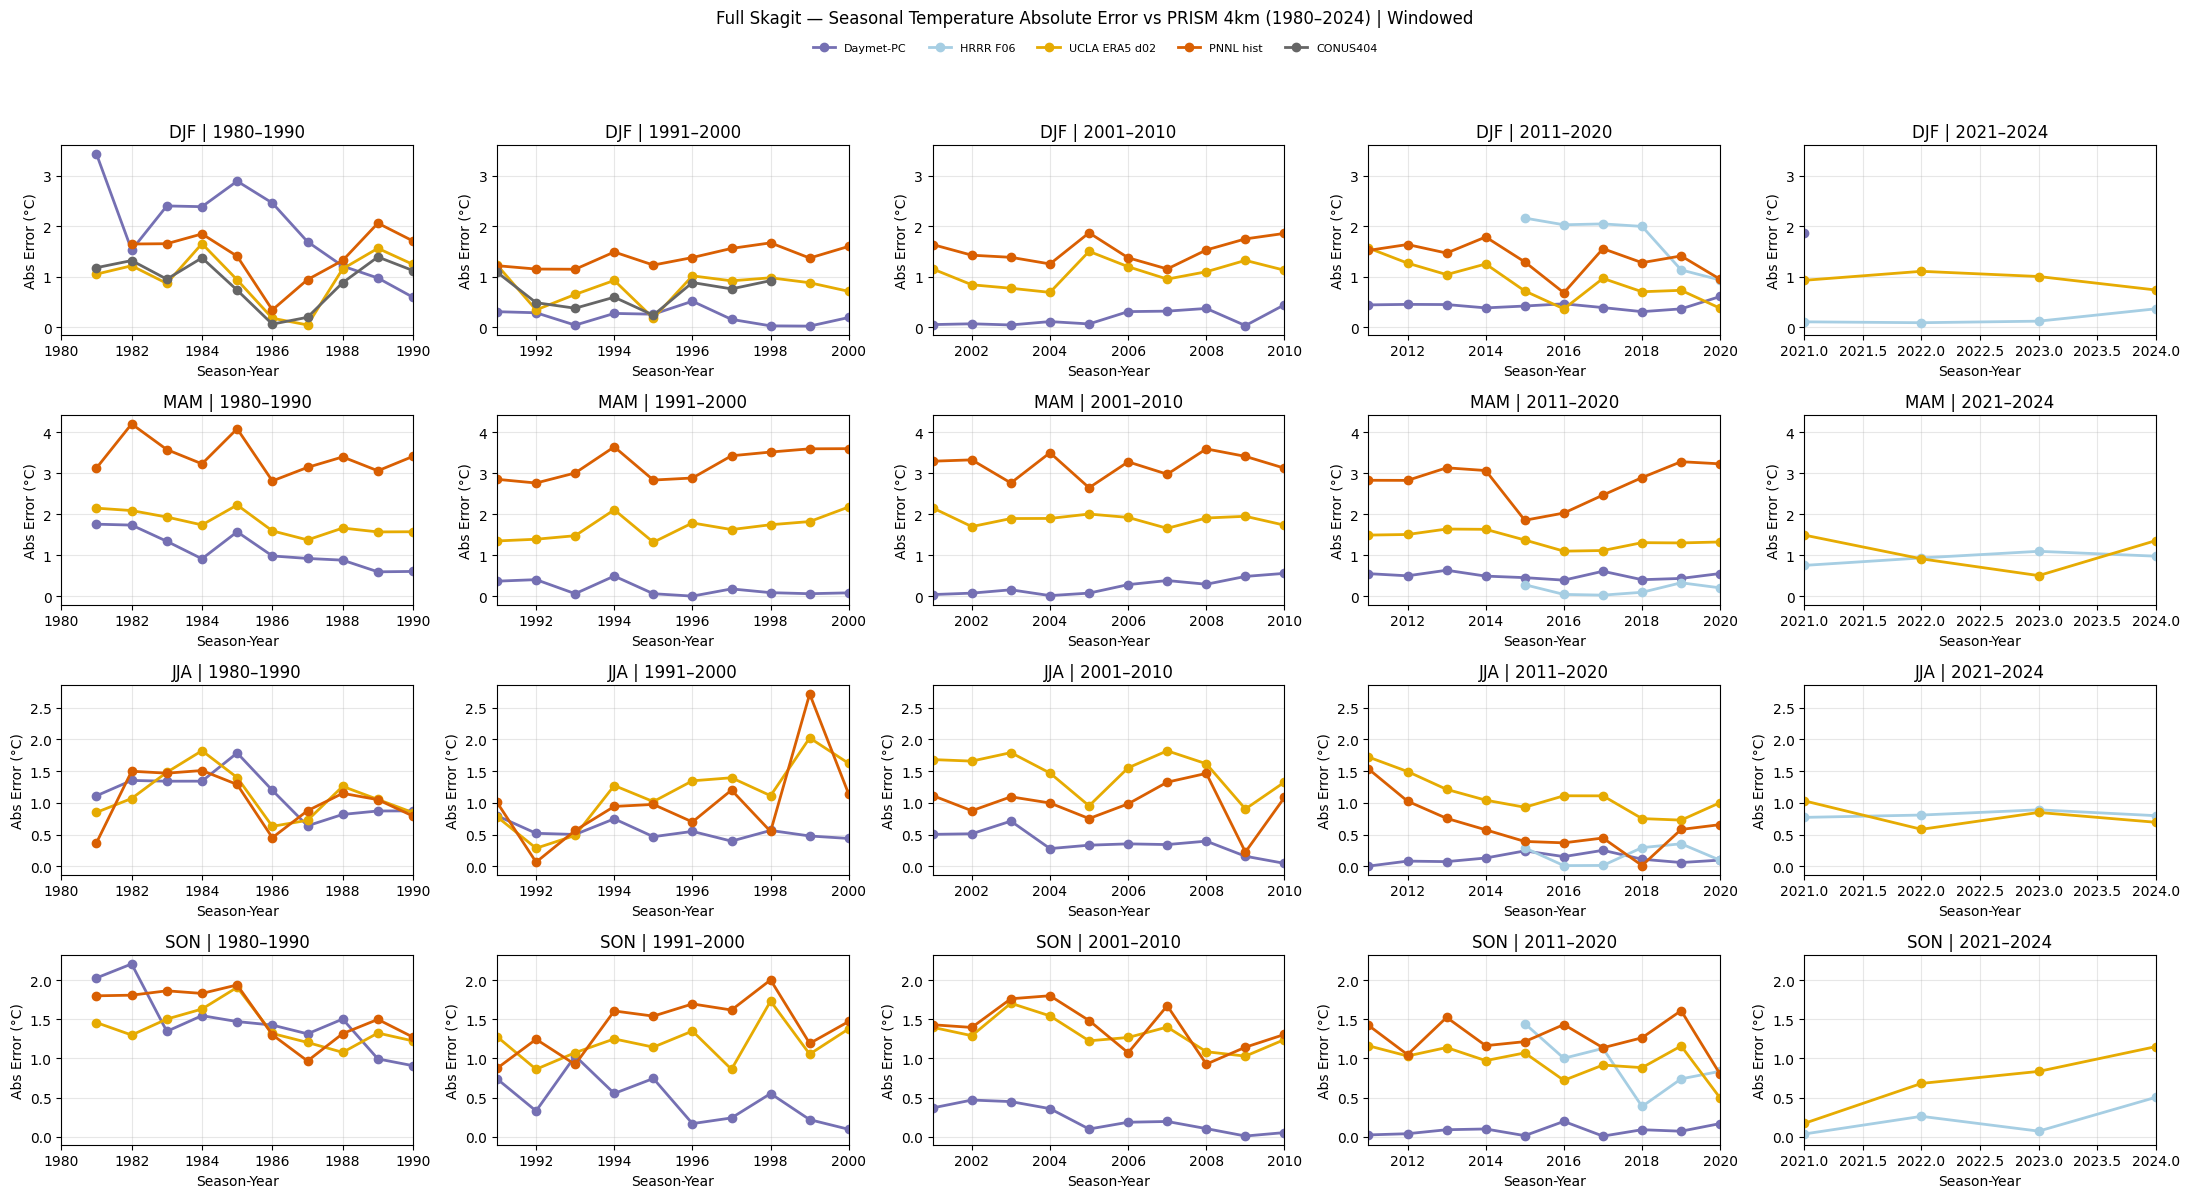

In [2]:
# ==========================================================
# FULL NOTEBOOK CELL: Meteorological Seasonal Mean Temperature (°C) by 4 regions
#
# OUTPUTS:
#   - Seasonal mean temperature CSV by dataset x region x season x year
#   - Seasonal MAE-vs-PRISM CSV
#   - One figure per region:
#       (4 seasons) x (5 windows)
#   - One MAE figure per region:
#       (4 seasons) x (5 windows)
#
# REGIONS:
#   - Upper Skagit
#   - Sauk
#   - Lower Skagit
#   - Full Skagit
#
# METEOROLOGICAL SEASONS:
#   - DJF = Dec(previous year) + Jan/Feb(current year), labeled by ending year
#   - MAM = Mar/Apr/May
#   - JJA = Jun/Jul/Aug
#   - SON = Sep/Oct/Nov
#
# IMPORTANT:
#   - DJF for YEAR_MIN needs Dec(YEAR_MIN-1), so DJF starts at YEAR_MIN+1
#   - HRRR legend is forced from full dataset order, so it appears even if
#     the first subplot does not contain HRRR data
#   - PRISM uses local zarr first, then fills missing months from zip->NetCDF
#   - Daymet local uses projected x/y masks
#   - HRRR F06 uses valid-time shift (+6h) and keeps init hours 00/06/12/18
# ==========================================================

import re
import sys
import glob
import time
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 1980, 2024

# For seasonal plotting / ingest:
# Need Dec(YEAR_MIN-1) for DJF YEAR_MIN+1
GLOBAL_START = f"{YEAR_MIN-1}-12-01"
GLOBAL_END   = (pd.Timestamp(YEAR_MAX, 11, 1) + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit", "Full Skagit"]

SEASONS = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}
SEASONS_ORDER = ["DJF", "MAM", "JJA", "SON"]

TIME_WINDOWS = [
    (1980, 1990),
    (1991, 2000),
    (2001, 2010),
    (2011, 2020),
    (2021, 2024),
]

# Local datasets
P_HRRR_DIR  = BASE / "weather_data_06"
PNNL_HIST   = BASE / "PNNL" / "historical"
PNNL_GEO    = PNNL_HIST / "SERDP6km.geo_em.d01.nc"

UCLA_T2_DIR       = Path("/data0/balaji24/data/ucla_era5_d02_daily/t2")
UCLA_T2_TEMPLATE  = "t2.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE   = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

DAYMET_DIR       = Path("/data0/balaji24/data/daymet_nc_2014_2024")
DAYMET_TMIN_GLOB = str(DAYMET_DIR / "daymet_tmin_*.nc")
DAYMET_TMAX_GLOB = str(DAYMET_DIR / "daymet_tmax_*.nc")

PRISM_TEMP_DIR = Path("/data0/balaji24/data/prism_temp_nc")
PRISM_ZIP_GLOB = "prism_tmean_us_25m_*.zip"

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)

CSV_OUT     = OUT / f"met_season_temp_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.csv"
MAE_REF     = "PRISM 4km"
MAE_CSV_OUT = OUT / f"met_season_temp_mae_vs_{MAE_REF.replace(' ', '_')}_{YEAR_MIN}_{YEAR_MAX}.csv"

# Plot-only exclusions
PLOT_EXCLUSIONS = {
    "Daymet-PC": {2023},
    "HRRR F06": {2014},
}

# ==========================================================
# Canonical colors/order
# ==========================================================
DATASET_ORDER = [
    "PRISM 4km",
    "Daymet-PC",
    "gridMET",
    "HRRR F01",
    "HRRR F06",
    "UCLA ERA5 d02",
    "PNNL hist",
    "CONUS404",
]

COLORS = {
    "PRISM 4km":     "#1B9E77",
    "PRISM 800m":    "#66C2A5",
    "Daymet-PC":     "#7570B3",
    "HRRR F01":      "#1F78B4",
    "HRRR F06":      "#A6CEE3",
    "UCLA ERA5 d02": "#E6AB02",
    "PNNL hist":     "#D95F02",
    "CONUS404":      "#666666",
    "SNOTEL (mean stations)": "#000000",
}

# ==========================================================
# Generic helpers
# ==========================================================
def _ensure_time_name(obj):
    if isinstance(obj, xr.Dataset):
        if "time" not in obj.dims:
            for alt in ("day", "date"):
                if alt in obj.dims:
                    obj = obj.rename({alt: "time"})
                    break
        if "time" not in obj.coords:
            for alt in ("day", "date"):
                if alt in obj.coords:
                    obj = obj.rename({alt: "time"})
                    break
        return obj

    if isinstance(obj, xr.DataArray):
        if "time" not in obj.dims:
            for alt in ("day", "date"):
                if alt in obj.dims:
                    obj = obj.rename({alt: "time"})
                    break
        return obj

    return obj

def ensure_time_sorted_unique(da):
    da = _ensure_time_name(da)
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_celsius(da):
    da = _ensure_time_name(da)

    da = xr.where(np.isfinite(da), da, np.nan)
    da = xr.where(np.abs(da) < 1e20, da, np.nan)

    try:
        probe = da.isel(time=0) if "time" in da.dims else da
        m = float(probe.mean(skipna=True).compute()) if hasattr(probe.data, "compute") else float(probe.mean(skipna=True))
    except Exception:
        m = 0.0

    out = da - 273.15 if m > 150 else da
    out = xr.where(np.isfinite(out), out, np.nan)
    out = xr.where((out > -80) & (out < 80), out, np.nan)
    return out

def pick_var(ds, candidates):
    for v in candidates:
        if v in ds.data_vars:
            return v
    lcands = [c.lower() for c in candidates]
    for v in ds.data_vars:
        if v.lower() in lcands:
            return v
    return None

def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat", "latitude", "lat2d", "XLAT", "XLAT_M", "Lat", "LAT"] if n in ds), None)
    lon_name = next((n for n in ["lon", "longitude", "lon2d", "XLONG", "XLONG_M", "Lon", "LON"] if n in ds), None)
    return lat_name, lon_name

def _to_2d(arr):
    arr = _ensure_time_name(arr)
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x", "y", "lon", "lat", "lon2d", "lat2d", "south_north", "west_east")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def fix_duplicate_dims_da(da):
    dims = list(da.dims)
    if len(dims) == len(set(dims)):
        return da
    seen, new_dims = {}, []
    for d in dims:
        seen[d] = seen.get(d, 0) + 1
        new_dims.append(d if seen[d] == 1 else f"{d}{seen[d]-1}")
    da.dims = tuple(new_dims)
    return da

def fix_duplicate_dims(ds):
    for name, var in ds.variables.items():
        dims = list(getattr(var, "dims", ()))
        if len(dims) == len(set(dims)):
            continue
        seen, new_dims = {}, []
        for d in dims:
            seen[d] = seen.get(d, 0) + 1
            new_dims.append(d if seen[d] == 1 else f"{d}{seen[d]-1}")
        ds[name].dims = tuple(new_dims)
    return ds

def align_mask_to_da(mask_da, da):
    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"Expected 2 spatial dims, got {spatial}")

    mask_da = mask_da.squeeze(drop=True)
    mask_da = fix_duplicate_dims_da(mask_da)
    if mask_da.ndim != 2:
        raise RuntimeError(f"Mask must be 2D; got dims={mask_da.dims}, shape={mask_da.shape}")

    mdims = list(mask_da.dims)

    rename_map = {}
    used_sd = set()
    for md in mdims:
        if md in spatial:
            rename_map[md] = md
            used_sd.add(md)

    remaining_md = [md for md in mdims if md not in rename_map]
    remaining_sd = [sd for sd in spatial if sd not in used_sd]

    for md in remaining_md:
        matched = None
        for sd in remaining_sd:
            if mask_da.sizes[md] == da.sizes[sd]:
                matched = sd
                break
        if matched is None:
            raise RuntimeError(
                f"Could not map mask dim '{md}' (size={mask_da.sizes[md]}) "
                f"to any of {remaining_sd} with sizes {[da.sizes[s] for s in remaining_sd]}"
            )
        rename_map[md] = matched
        remaining_sd.remove(matched)

    m = mask_da.rename(rename_map)

    if set(m.dims) == set(spatial) and list(m.dims) != spatial:
        m = m.transpose(*spatial)

    if (m.sizes.get(spatial[0], -1) != da.sizes[spatial[0]]) or (m.sizes.get(spatial[1], -1) != da.sizes[spatial[1]]):
        raise RuntimeError(
            f"Mask shape {(m.sizes.get(spatial[0]), m.sizes.get(spatial[1]))} "
            f"does not match data grid {(da.sizes[spatial[0]], da.sizes[spatial[1]])}"
        )
    return m

def contains_xy_mask(geom, xs, ys):
    try:
        import shapely
        cx = getattr(shapely, "contains_xy", None)
        if callable(cx):
            return np.asarray(cx(geom, xs, ys), dtype=bool)
    except Exception:
        pass

    try:
        from shapely.vectorized import contains as vcontains
        return np.asarray(vcontains(geom, xs, ys), dtype=bool)
    except Exception:
        pass

    import shapely as _sh
    from shapely.prepared import prep
    pg = prep(geom)
    return np.array([pg.contains(_sh.Point(x, y)) for x, y in zip(xs, ys)], dtype=bool)

def masked_mean_timeseries(da, mask2d):
    da = _ensure_time_name(da)
    spatial_dims = [d for d in da.dims if d != "time"]

    m = mask2d
    if set(m.dims) != set(spatial_dims) or list(m.dims) != spatial_dims:
        m = align_mask_to_da(m, da)

    w = xr.where(m, 1.0, np.nan)
    return (da * w).mean(dim=spatial_dims, skipna=True)

def masked_region_mean_from_masks(da, masks_dict, region_names):
    out_list = []
    for rname in region_names:
        out_list.append(masked_mean_timeseries(da, masks_dict[rname]))
    return xr.concat(out_list, dim="region").assign_coords(region=region_names)

# ==========================================================
# Season helpers
# ==========================================================
def years_for_season(season_label):
    if season_label == "DJF":
        return range(YEAR_MIN + 1, YEAR_MAX + 1)
    return range(YEAR_MIN, YEAR_MAX + 1)

def season_time_window(year, season_label):
    def month_end(y, m):
        return (pd.Timestamp(y, m, 1) + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

    if season_label == "DJF":
        return f"{year-1}-12-01", month_end(year, 2)
    if season_label == "MAM":
        return f"{year}-03-01", month_end(year, 5)
    if season_label == "JJA":
        return f"{year}-06-01", month_end(year, 8)
    if season_label == "SON":
        return f"{year}-09-01", month_end(year, 11)
    raise ValueError(season_label)

def season_year_index(time_da, season_label):
    y = time_da.dt.year
    m = time_da.dt.month
    if season_label == "DJF":
        sy = xr.where(m == 12, y + 1, y)
    else:
        sy = y
    return sy.rename("year")

def seasonal_mean_c(da, season_label):
    """
    da dims: ('time','region') or ('time',)
    returns dims: ('year','region') or ('year',)
    """
    if "time" not in da.dims:
        return None
    da = ensure_time_sorted_unique(da)
    months = SEASONS[season_label]
    da_s = da.where(da["time"].dt.month.isin(months), drop=True)
    if da_s.sizes.get("time", 0) == 0:
        return None
    sy = season_year_index(da_s["time"], season_label)
    out = da_s.groupby(sy).mean("time", skipna=True)
    if "year" not in out.dims:
        candidates = [d for d in out.dims if d not in ("time", "region")]
        if candidates:
            out = out.rename({candidates[0]: "year"})
    out.name = "temp_c"
    return out

# ==========================================================
# Region helpers
# ==========================================================
def load_regions_gdf():
    import geopandas as gpd

    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    sub3 = ["Upper Skagit", "Sauk", "Lower Skagit"]
    huc8_3 = huc8[huc8["Name"].isin(sub3)].copy()
    if huc8_3.empty:
        raise ValueError(f"No matching HUC8 regions found for {sub3}. Check 'Name' field.")

    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_3 = huc8_3[["Name", "geometry"]].reset_index(drop=True)

    full_row = gpd.GeoDataFrame(
        {"Name": ["Full Skagit"], "geometry": [skagit_gdf.geometry.iloc[0]]},
        crs="EPSG:4326",
    )

    regions_gdf = pd.concat([regions_3, full_row], ignore_index=True)
    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    regions_gdf = regions_gdf.sort_values("Name").reset_index(drop=True)
    return regions_gdf

def region_mean(da, grid_ds=None, regions_gdf=None):
    """
    Robust region mean using regionmask with overlap=True.
    Handles Full Skagit overlapping subregions.
    """
    if regions_gdf is None:
        raise ValueError("regions_gdf is required")

    import regionmask

    da = _ensure_time_name(da)
    host = _ensure_time_name(grid_ds if grid_ds is not None else da.to_dataset(name="_tmp"))

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        return da.expand_dims(region=list(regions_gdf["Name"].values))

    lat_name, lon_name = find_lat_lon_names(host)
    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(host[lon_name])
    lat = _to_2d(host[lat_name])

    if lon.ndim == 1 and lat.ndim == 1 and len(spatial) == 2:
        lon_dim = next((d for d in spatial if da.sizes.get(d, -1) == lon.size), None)
        lat_dim = next((d for d in spatial if da.sizes.get(d, -1) == lat.size and d != lon_dim), None)
        if lon_dim and lat_dim:
            lon2d, lat2d = np.meshgrid(lon.values, lat.values)
            lon = xr.DataArray(lon2d, dims=(lat_dim, lon_dim))
            lat = xr.DataArray(lat2d, dims=(lat_dim, lon_dim))

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_regions",
        overlap=True,
    )

    m3 = regs.mask_3D(lon, lat)

    spatial_dims = [d for d in da.dims if d != time_dim]
    mask_spatial_dims = [d for d in m3.dims if d != "region"]

    if set(mask_spatial_dims) != set(spatial_dims):
        rename_map = {}
        for md in mask_spatial_dims:
            for pd in spatial_dims:
                if m3.sizes.get(md) == da.sizes.get(pd):
                    rename_map[md] = pd
                    break
        if rename_map:
            m3 = m3.rename(rename_map)

    if set([d for d in m3.dims if d != "region"]) == set(spatial_dims):
        desired = ["region"] + spatial_dims
        if list(m3.dims) != desired:
            m3 = m3.transpose(*desired)

    out_list = []
    for i, _rname in enumerate(regs.names):
        m = m3.isel(region=i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(dim=spatial_dims, skipna=True))

    out = xr.concat(out_list, dim="region").assign_coords(region=regs.names)
    return out

# ==========================================================
# Dataset label / plotting helpers
# ==========================================================
def color_for_dataset(dsname):
    return COLORS.get(str(dsname), "#000000")

def _ordered_datasets_present(df_sub):
    present = list(df_sub["dataset"].unique())
    ordered = [d for d in DATASET_ORDER if d in present]
    ordered += [d for d in present if d not in ordered]
    return ordered

def _legend_datasets_present(df_sub, value_col):
    ds_order = _ordered_datasets_present(df_sub)
    out = []
    for d in ds_order:
        sub = df_sub[df_sub["dataset"] == d]
        if sub[value_col].notna().any():
            out.append(d)
    return out

def _window_label(a, b):
    return f"{a}–{b}"

def _ylim_for_series(values):
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return (0.0, 1.0)

    vmin = float(np.nanmin(v))
    vmax = float(np.nanmax(v))
    if np.isclose(vmin, vmax):
        pad = 1.0
    else:
        pad = 0.05 * (vmax - vmin)
    return (vmin - pad, vmax + pad)

def _build_legend_handles(dataset_names):
    handles = []
    for dsname in dataset_names:
        handles.append(
            Line2D(
                [0], [0],
                color=color_for_dataset(dsname),
                marker="o",
                linewidth=2.0,
                label=dsname
            )
        )
    return handles

def plot_region_season_window_grid(
    df_region,
    value_col,
    ylabel,
    title_prefix,
    out_path,
):
    """
    (4 seasons) x (5 windows) grid for a single region.
    Each season-row has consistent y-limits across its 5 windows.
    Legend is built manually from all datasets present, so HRRR shows up.
    """
    fig = plt.figure(figsize=(22, 12))

    ylims = {}
    for s in SEASONS_ORDER:
        df_rs = df_region[df_region["season"] == s]
        ylims[s] = _ylim_for_series(df_rs[value_col].values)

    ds_order = _ordered_datasets_present(df_region)

    for r_i, s in enumerate(SEASONS_ORDER):
        df_rs = df_region[df_region["season"] == s]

        for c_i, (a, b) in enumerate(TIME_WINDOWS):
            ax = plt.subplot(len(SEASONS_ORDER), len(TIME_WINDOWS), r_i * len(TIME_WINDOWS) + c_i + 1)

            df_w = df_rs[(df_rs["year"] >= a) & (df_rs["year"] <= b)]
            if not df_w.empty:
                for name in ds_order:
                    g = df_w[df_w["dataset"] == name].sort_values("year")
                    g = g[np.isfinite(g[value_col])]
                    if g.empty:
                        continue

                    ax.plot(
                        g["year"], g[value_col],
                        marker="o",
                        color=color_for_dataset(name),
                        linewidth=2.0,
                    )

            ax.set_title(f"{s} | {_window_label(a, b)}")
            ax.set_xlim(a, b)
            ax.set_ylim(*ylims[s])
            ax.set_xlabel("Season-Year")
            ax.set_ylabel(ylabel)
            ax.grid(True, alpha=0.3)

    legend_names = _legend_datasets_present(df_region, value_col)
    if legend_names:
        handles = _build_legend_handles(legend_names)
        fig.legend(
            handles=handles,
            labels=legend_names,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.975),
            ncol=min(5, len(legend_names)),
            fontsize=8,
            frameon=False,
        )

    fig.suptitle(title_prefix, y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(out_path, dpi=160)
    print("Saved plot →", out_path)
    plt.show()

# ==========================================================
# Daymet local helpers
# ==========================================================
def year_from_path(p):
    m = re.search(r"_(\d{4})\.nc$", str(p))
    return int(m.group(1)) if m else None

def good_file(p, var):
    try:
        ds = xr.open_dataset(p, engine="netcdf4")
        ds = _ensure_time_name(ds)
        ok = (var in ds.data_vars) and (ds.sizes.get("time", 0) > 0)
        ds.close()
        return ok
    except Exception:
        return False

def open_daymet_year(path_nc, var):
    ds = xr.open_dataset(path_nc, engine="netcdf4")
    ds = _ensure_time_name(ds)

    if var not in ds:
        ds.close()
        raise KeyError(f"{path_nc} missing var={var}")

    if "x" in ds.coords:
        ds = ds.sortby("x")
    if "y" in ds.coords:
        ds = ds.sortby("y")

    if "time" in ds.coords:
        tt = pd.to_datetime(ds["time"].values)
        _, idx = np.unique(tt, return_index=True)
        ds = ds.isel(time=np.sort(idx))

    return ds[[var]]

def ensure_daymet_pkgs():
    needed = ["pyproj", "shapely"]
    import importlib
    import subprocess

    missing = []
    for p in needed:
        try:
            importlib.import_module(p)
        except Exception:
            missing.append(p)

    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

def build_daymet_local_masks(ds_daymet, regions_gdf):
    ensure_daymet_pkgs()

    from pyproj import CRS, Transformer
    from shapely.ops import transform as shp_transform

    daymet_crs = CRS.from_proj4(
        "+proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )
    tfm = Transformer.from_crs("EPSG:4326", daymet_crs, always_xy=True)

    def _project_geom(geom_ll):
        def _proj(x, y, z=None):
            return tfm.transform(x, y)
        return shp_transform(_proj, geom_ll)

    if "x" not in ds_daymet.coords or "y" not in ds_daymet.coords:
        raise RuntimeError("[Daymet local] Expected x/y coordinates in local NetCDF")

    xvals = np.asarray(ds_daymet["x"].values)
    yvals = np.asarray(ds_daymet["y"].values)
    xx, yy = np.meshgrid(xvals, yvals)

    masks = {}
    regs_ll = regions_gdf.to_crs("EPSG:4326")
    for _, row in regs_ll.iterrows():
        rname = str(row["Name"])
        geom_xy = _project_geom(row["geometry"])
        mask_np = contains_xy_mask(geom_xy, xx.ravel(), yy.ravel()).reshape(len(yvals), len(xvals))
        masks[rname] = xr.DataArray(mask_np, dims=("y", "x"), coords={"y": ds_daymet["y"], "x": ds_daymet["x"]})

    return masks

# ==========================================================
# PRISM helpers
# ==========================================================
def _detect_prism_temp_var(ds):
    candidates = ["tmean", "tavg", "tmean_c", "tmean_degC", "Tmean", "temp", "tas"]
    for v in candidates:
        if v in ds.data_vars:
            return v
    for v in ds.data_vars:
        vl = v.lower()
        if "tmean" in vl or "tavg" in vl or ("temp" in vl and "mean" in vl):
            return v
    return None

def _parse_prism_zarr_year_range(p):
    m = re.match(
        r"^(\d{4})-\d{2}-\d{2}_(\d{4})-\d{2}-\d{2}_daily_4km_PRISM_data\.zarr$",
        p.name
    )
    if not m:
        return None
    return int(m.group(1)), int(m.group(2))

def _prepare_prism_da(da):
    if "time" not in da.dims:
        tdim = next(
            (d for d in da.dims if "time" in d.lower() or "day" in d.lower() or "date" in d.lower()),
            None
        )
        if tdim:
            da = da.rename({tdim: "time"})
    da = ensure_time_sorted_unique(da)
    return da

def _month_keys_from_time(time_vals):
    tt = pd.to_datetime(time_vals)
    return set(tt.to_period("M").astype(str).tolist())

def _extract_prism_nc_from_zip(zpath, cache_dir):
    cache_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zpath, "r") as zf:
        members = zf.namelist()
        nc_members = [m for m in members if m.lower().endswith(".nc")]
        if not nc_members:
            return None

        inner = nc_members[0]
        out = cache_dir / f"{zpath.stem}.nc"
        if out.exists():
            return out

        zf.extract(inner, path=cache_dir)
        extracted = cache_dir / inner

        out.parent.mkdir(parents=True, exist_ok=True)
        if extracted.resolve() != out.resolve():
            if out.exists():
                out.unlink()
            extracted.rename(out)

        return out

# ==========================================================
# UCLA helpers
# ==========================================================
def pick_time_dim(da):
    if "time" in da.dims:
        return "time"
    if "day" in da.dims:
        return "day"
    for d in da.dims:
        if "time" in d.lower() or "day" in d.lower():
            return d
    raise ValueError(f"[UCLA] No time-like dim found. dims={da.dims}")

def ensure_sorted_unique_time(da, tdim="time"):
    da = da.sortby(tdim)
    try:
        t = pd.to_datetime(da[tdim].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel({tdim: np.sort(idx)})
    except Exception:
        pass
    return da

def ucla_file_label_for_date(dt):
    # Sep..Dec belong to label=year; Jan..Aug belong to label=year-1
    return dt.year if dt.month >= 9 else (dt.year - 1)

def open_ucla_t2_for_window(t0, t1):
    t0_ts = pd.Timestamp(t0)
    t1_ts = pd.Timestamp(t1)
    labels_needed = sorted({ucla_file_label_for_date(t0_ts), ucla_file_label_for_date(t1_ts)})

    files = []
    for lab in labels_needed:
        f = UCLA_T2_DIR / UCLA_T2_TEMPLATE.format(year=lab)
        if f.exists():
            files.append(str(f))

    if not files:
        return None, []

    dsets, arrs = [], []
    for f in files:
        ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)

        v = pick_var(ds, ["t2", "T2", "t2m", "tas", "temp"])
        if v is None:
            ds.close()
            continue

        da = ds[v]
        tdim = pick_time_dim(da)
        if tdim != "time":
            da = da.rename({tdim: "time"})

        arrs.append(da)
        dsets.append(ds)

    if not arrs:
        return None, []

    all_da = xr.concat(arrs, dim="time", join="outer", coords="minimal", compat="override")
    all_da = ensure_sorted_unique_time(all_da, "time")
    all_da = all_da.sel(time=slice(t0, t1))

    if all_da.sizes.get("time", 0) == 0:
        for ds in dsets:
            try:
                ds.close()
            except Exception:
                pass
        return None, []

    return all_da, dsets

def build_ucla_region_masks(coord_file, regions_gdf):
    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True).astype("float64")
    lon = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    lonv = lon.values.ravel()
    latv = lat.values.ravel()
    ny, nx = lon.shape

    masks = {}
    for _, row in regions_gdf.iterrows():
        name = str(row["Name"])
        geom = row["geometry"]
        m_flat = contains_xy_mask(geom, lonv, latv)
        mask2d = m_flat.reshape(ny, nx).astype(bool)
        masks[name] = xr.DataArray(mask2d, dims=lon.dims, coords=lon.coords)

    return masks

# ==========================================================
# HRRR F06 helpers
# ==========================================================
def _find_hrrr_t2_var(ds):
    if "t2m" in ds.data_vars:
        return "t2m"
    if "T2" in ds.data_vars:
        return "T2"
    for v in ds.data_vars:
        lv = v.lower()
        if lv in ("t2m", "t2", "tas") or ("temp" in lv and "2" in lv):
            return v
    return None

def hrrr_f06_daily_t2_c(ds, var="t2m"):
    """
    HRRR F06 temperature logic:
      - ds.time is INIT time
      - keep init hours 00/06/12/18
      - shift init -> valid time by +6h
      - daily mean = mean of 4 six-hour valid-time samples per day
    """
    if var not in ds:
        raise ValueError(f"[HRRR F06] Missing '{var}'. vars={list(ds.data_vars)}")

    da = ensure_time_sorted_unique(ds[var])

    t = pd.to_datetime(da["time"].values)
    keep = np.isin(t.hour, [0, 6, 12, 18])
    da = da.sel(time=da["time"].values[keep])

    da = da.assign_coords(time=(pd.to_datetime(da["time"].values) + pd.Timedelta(hours=6)))
    da = to_celsius(da)

    daily = da.resample(time="1D").mean()
    return daily

# ==========================================================
# Begin collection
# ==========================================================
regions_gdf = load_regions_gdf()
rows = []

# ==========================================================
# 1) Daymet LOCAL
# ==========================================================
print("[DAYMET-LOCAL] Computing seasonal mean temperature from local NetCDFs...")
try:
    tmin_files = sorted(glob.glob(DAYMET_TMIN_GLOB))
    tmax_files = sorted(glob.glob(DAYMET_TMAX_GLOB))

    tmin_good = {year_from_path(f): f for f in tmin_files if year_from_path(f) is not None and good_file(f, "tmin")}
    tmax_good = {year_from_path(f): f for f in tmax_files if year_from_path(f) is not None and good_file(f, "tmax")}

    years = sorted([y for y in range(YEAR_MIN - 1, YEAR_MAX + 1) if (y in tmin_good and y in tmax_good)])
    if not years:
        raise RuntimeError("No overlapping good tmin/tmax years found.")

    dsmin_list, dsmax_list = [], []
    for y in years:
        dsmin_list.append(open_daymet_year(tmin_good[y], "tmin"))
        dsmax_list.append(open_daymet_year(tmax_good[y], "tmax"))

    ds_min = xr.concat(dsmin_list, dim="time", join="outer", coords="minimal", compat="override").sortby("time")
    ds_max = xr.concat(dsmax_list, dim="time", join="outer", coords="minimal", compat="override").sortby("time")

    tmin = ensure_time_sorted_unique(ds_min["tmin"])
    tmax = ensure_time_sorted_unique(ds_max["tmax"])
    tmin2, tmax2 = xr.align(tmin, tmax, join="inner")

    tmean = to_celsius((tmin2 + tmax2) / 2.0).sel(time=slice(GLOBAL_START, GLOBAL_END))

    daymet_masks = build_daymet_local_masks(ds_min, regions_gdf)
    rm = ensure_time_sorted_unique(masked_region_mean_from_masks(tmean, daymet_masks, REGION_NAMES))

    for s in SEASONS_ORDER:
        ann = seasonal_mean_c(rm, s)
        if ann is None or "year" not in ann.dims:
            continue

        for yr in years_for_season(s):
            if yr not in ann["year"].values:
                continue
            for rgn in ann["region"].values:
                val = float(ann.sel(year=yr, region=rgn).values)
                if np.isfinite(val):
                    rows.append({
                        "dataset": "Daymet-PC",
                        "region": str(rgn),
                        "season": s,
                        "year": int(yr),
                        "temp_c": float(val),
                    })

    for d in dsmin_list:
        try:
            d.close()
        except Exception:
            pass
    for d in dsmax_list:
        try:
            d.close()
        except Exception:
            pass
    try:
        ds_min.close()
    except Exception:
        pass
    try:
        ds_max.close()
    except Exception:
        pass

    print("[DAYMET-LOCAL] Success.")
except Exception as e:
    print("[DAYMET-LOCAL] FAILED:", repr(e))

# ==========================================================
# 2) PRISM temp (zarr first, then fill missing months from zips)
# ==========================================================
print("[PRISM-TEMP] Computing seasonal mean temperature from local PRISM...")
try:
    prism_rm_parts = []
    loaded_months = set()

    target_months = set(pd.date_range(GLOBAL_START, GLOBAL_END, freq="MS").strftime("%Y-%m").tolist())

    prism_zarrs_all = sorted([p for p in PRISM_TEMP_DIR.glob("*_daily_4km_PRISM_data.zarr") if p.is_dir()])

    zarr_info = []
    for p in prism_zarrs_all:
        yr = _parse_prism_zarr_year_range(p)
        if yr is not None:
            zarr_info.append((p, yr[0], yr[1]))

    zarr_info = sorted(zarr_info, key=lambda x: (x[1], -x[2]))

    selected_zarrs = []
    for p, ys, ye in zarr_info:
        contained = any((ys >= s and ye <= e) for _, s, e in selected_zarrs)
        if not contained:
            selected_zarrs.append((p, ys, ye))

    for p, ys, ye in selected_zarrs:
        try:
            ds = safe_open_zarr(p)
            v = _detect_prism_temp_var(ds)
            if v is None:
                try:
                    ds.close()
                except Exception:
                    pass
                continue

            da = _prepare_prism_da(ds[v])
            if "time" not in da.dims:
                try:
                    ds.close()
                except Exception:
                    pass
                continue

            da = to_celsius(da).sel(time=slice(GLOBAL_START, GLOBAL_END))
            if da.sizes.get("time", 0) == 0:
                try:
                    ds.close()
                except Exception:
                    pass
                continue

            rm = region_mean(da, grid_ds=ds, regions_gdf=regions_gdf)
            rm = ensure_time_sorted_unique(rm).load()
            prism_rm_parts.append(rm)

            loaded_months |= _month_keys_from_time(rm["time"].values)

            try:
                ds.close()
            except Exception:
                pass

        except Exception as e:
            print(f"[PRISM-TEMP] Failed zarr {p.name}: {repr(e)}")

    prism_zips = sorted(PRISM_TEMP_DIR.glob(PRISM_ZIP_GLOB))
    cache_dir = PRISM_TEMP_DIR / "_prism_nc_cache"
    ym_re = re.compile(r"_(\d{6})$")

    for zp in prism_zips:
        m = ym_re.search(zp.stem)
        if not m:
            continue

        ym = m.group(1)
        month_key = f"{ym[:4]}-{ym[4:]}"
        if month_key not in target_months or month_key in loaded_months:
            continue

        nc_path = _extract_prism_nc_from_zip(zp, cache_dir)
        if nc_path is None:
            continue

        try:
            ds = xr.open_dataset(nc_path, engine="netcdf4")
            ds = _ensure_time_name(ds)

            v = _detect_prism_temp_var(ds)
            if v is None:
                ds.close()
                continue

            da = _prepare_prism_da(ds[v])
            if "time" not in da.dims:
                ds.close()
                continue

            da = to_celsius(da).sel(time=slice(GLOBAL_START, GLOBAL_END))
            if da.sizes.get("time", 0) == 0:
                ds.close()
                continue

            rm = region_mean(da, grid_ds=ds, regions_gdf=regions_gdf)
            rm = ensure_time_sorted_unique(rm).load()
            prism_rm_parts.append(rm)
            loaded_months |= _month_keys_from_time(rm["time"].values)
            ds.close()

        except Exception as e:
            print(f"[PRISM-TEMP] Failed zip {zp.name}: {repr(e)}")

    if not prism_rm_parts:
        raise RuntimeError("No usable PRISM data found from either zarrs or zips.")

    prism_rm = xr.concat(prism_rm_parts, dim="time", join="outer", coords="minimal", compat="override")
    prism_rm = ensure_time_sorted_unique(prism_rm)
    prism_rm = prism_rm.sel(time=slice(GLOBAL_START, GLOBAL_END))

    for s in SEASONS_ORDER:
        ann = seasonal_mean_c(prism_rm, s)
        if ann is None or "year" not in ann.dims:
            continue

        for yr in years_for_season(s):
            if yr not in ann["year"].values:
                continue
            for rgn in ann["region"].values:
                val = float(ann.sel(year=yr, region=rgn).values)
                if np.isfinite(val):
                    rows.append({
                        "dataset": "PRISM 4km",
                        "region": str(rgn),
                        "season": s,
                        "year": int(yr),
                        "temp_c": float(val),
                    })

    print("[PRISM-TEMP] Success.")
except Exception as e:
    print("[PRISM-TEMP] SKIP/FAILED:", repr(e))

# ==========================================================
# 3) UCLA ERA5 d02
# ==========================================================
print("[UCLA] Computing seasonal mean temperature from local NetCDFs...")
try:
    if not UCLA_T2_DIR.exists():
        raise RuntimeError(f"Missing UCLA dir: {UCLA_T2_DIR}")
    if not UCLA_COORD_FILE.exists():
        raise RuntimeError(f"Missing UCLA coord file: {UCLA_COORD_FILE}")

    UCLA_REGION_MASKS = build_ucla_region_masks(UCLA_COORD_FILE, regions_gdf)

    for s in SEASONS_ORDER:
        for yr in years_for_season(s):
            t0, t1 = season_time_window(yr, s)
            da, parents = open_ucla_t2_for_window(t0, t1)
            if da is None:
                continue

            try:
                da = to_celsius(da)
                for rname in REGION_NAMES:
                    ts = masked_mean_timeseries(da, UCLA_REGION_MASKS[rname])
                    val = float(ts.mean(dim="time", skipna=True).compute().values)
                    if np.isfinite(val):
                        rows.append({
                            "dataset": "UCLA ERA5 d02",
                            "region": str(rname),
                            "season": s,
                            "year": int(yr),
                            "temp_c": float(val),
                        })
            finally:
                for ds in parents:
                    try:
                        ds.close()
                    except Exception:
                        pass

    print("[UCLA] Success.")
except Exception as e:
    print("[UCLA] FAILED:", repr(e))

# ==========================================================
# 4) HRRR F06
# ==========================================================
print(f"[HRRR F06] Computing seasonal mean temperature from monthly zarrs in {P_HRRR_DIR} ...")
try:
    if not P_HRRR_DIR.exists():
        raise RuntimeError(f"Missing HRRR dir: {P_HRRR_DIR}")

    zarrs = sorted([p for p in P_HRRR_DIR.glob("*.zarr") if p.is_dir()])
    monthly = [p for p in zarrs if re.match(r"^\d{4}-\d{2}_HRRR_f06_data\.zarr$", p.name)]
    by_prefix = {p.name[:7]: p for p in monthly}

    if not monthly:
        raise RuntimeError(f"No monthly HRRR F06 zarrs found in {P_HRRR_DIR}")

    all_months = pd.date_range(GLOBAL_START, GLOBAL_END, freq="MS").strftime("%Y-%m").tolist()

    first_template = by_prefix.get(all_months[0], None)
    if first_template is None:
        first_template = by_prefix[sorted(by_prefix.keys())[0]]

    ds0 = safe_open_zarr(first_template)
    v0 = _find_hrrr_t2_var(ds0)
    if v0 is None:
        raise RuntimeError(f"No HRRR temperature var found. Vars={list(ds0.data_vars)}")

    rm_parts = []
    for month_key in all_months:
        if month_key not in by_prefix:
            continue

        ds = None
        try:
            ds = safe_open_zarr(by_prefix[month_key])
            v = v0 if v0 in ds.data_vars else _find_hrrr_t2_var(ds)
            if v is None:
                continue

            daily = hrrr_f06_daily_t2_c(ds, var=v)
            if daily.sizes.get("time", 0) == 0:
                continue

            rm_daily = region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)
            rm_daily = ensure_time_sorted_unique(rm_daily)
            rm_daily = rm_daily.sel(time=slice(GLOBAL_START, GLOBAL_END)).load()

            if rm_daily.sizes.get("time", 0) > 0:
                rm_parts.append(rm_daily)

        except Exception as e:
            print(f"[HRRR F06] Failed {month_key}: {type(e).__name__}: {e}")
        finally:
            if ds is not None:
                try:
                    ds.close()
                except Exception:
                    pass

    if not rm_parts:
        raise RuntimeError("No usable HRRR F06 monthly region daily series were produced.")

    rm_all = xr.concat(rm_parts, dim="time", join="outer", coords="minimal", compat="override")
    rm_all = ensure_time_sorted_unique(rm_all)
    rm_all = rm_all.sel(time=slice(GLOBAL_START, GLOBAL_END))

    for s in SEASONS_ORDER:
        ann = seasonal_mean_c(rm_all, s)
        if ann is None or "year" not in ann.dims:
            continue

        for yr in years_for_season(s):
            if yr not in ann["year"].values:
                continue
            for rgn in ann["region"].values:
                val = float(ann.sel(year=yr, region=rgn).values)
                if np.isfinite(val):
                    rows.append({
                        "dataset": "HRRR F06",
                        "region": str(rgn),
                        "season": s,
                        "year": int(yr),
                        "temp_c": float(val),
                    })

    try:
        ds0.close()
    except Exception:
        pass

    print("[HRRR F06] Success.")
except Exception as e:
    print("[HRRR F06] SKIP/FAILED:", repr(e))

# ==========================================================
# 5) PNNL (geo_em masks)
# ==========================================================
print("[PNNL] Computing seasonal mean temperature from historical T2 using geo_em masks...")
try:
    import regionmask

    if not PNNL_HIST.exists():
        raise RuntimeError("Missing PNNL_HIST")
    if not PNNL_GEO.exists():
        raise RuntimeError(f"Missing PNNL geo_em file: {PNNL_GEO}")

    geo = xr.open_dataset(PNNL_GEO)
    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat2 = _to_2d(geo[lat_name]).astype("float64")
    lon2 = _to_2d(geo[lon_name]).astype("float64")

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_regions",
        overlap=True,
    )
    m3 = regs.mask_3D(lon2, lat2)

    pnnl_masks = {}
    for i, r in enumerate(regs.names):
        pnnl_masks[str(r)] = m3.isel(region=i)

    geo.close()

    def years_needed_for_season(season_label, yr):
        return {yr - 1, yr} if season_label == "DJF" else {yr}

    def months_present_in_selection(time_values):
        t = pd.to_datetime(time_values)
        return set(pd.Index(t.month).unique().tolist())

    for s in SEASONS_ORDER:
        need_months = set(SEASONS[s])

        for yr in years_for_season(s):
            t0, t1 = season_time_window(yr, s)

            files = []
            for yy in sorted(years_needed_for_season(s, yr)):
                files += sorted(glob.glob(str(PNNL_HIST / f"{yy}" / "*T2*.nc")))
            files = sorted(files)

            if not files:
                continue

            def _preprocess(ds):
                return ds[["T2"]] if "T2" in ds.data_vars else ds

            dsp = xr.open_mfdataset(
                files,
                combine="by_coords",
                engine="netcdf4",
                parallel=False,
                preprocess=_preprocess,
                chunks={"time": 24 * 7},
                join="outer",
            )
            dsp = _ensure_time_name(dsp)
            dsp = fix_duplicate_dims(dsp)

            if "T2" not in dsp:
                dsp.close()
                continue

            t2 = ensure_time_sorted_unique(dsp["T2"]).sel(time=slice(t0, t1))
            if t2.sizes.get("time", 0) == 0:
                dsp.close()
                continue

            seen_months = months_present_in_selection(t2["time"].values)
            if len(need_months - set(seen_months)) > 0:
                dsp.close()
                continue

            t2_daily = to_celsius(t2).resample(time="1D").mean()

            for rname in REGION_NAMES:
                bm = masked_mean_timeseries(t2_daily, pnnl_masks[rname])
                val = float(bm.mean("time", skipna=True).compute().values)
                if np.isfinite(val):
                    rows.append({
                        "dataset": "PNNL hist",
                        "region": str(rname),
                        "season": s,
                        "year": int(yr),
                        "temp_c": float(val),
                    })

            dsp.close()

    print("[PNNL] Success.")
except Exception as e:
    print("[PNNL] SKIP/FAILED:", repr(e))

# ==========================================================
# 6) CONUS404 online (best-effort)
# ==========================================================
print("[CONUS404] Loading via HyTEST intake (best-effort)...")
try:
    import intake

    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

    ds = fix_duplicate_dims(ds)
    if "lon" in ds:
        ds["lon"] = fix_duplicate_dims_da(ds["lon"])
    if "lat" in ds:
        ds["lat"] = fix_duplicate_dims_da(ds["lat"])

    v = pick_var(ds, ["t2m", "tas", "T2", "temp", "temperature"])
    if v is None:
        raise RuntimeError(f"No temp var found. Vars head={list(ds.data_vars)[:30]}")

    da = to_celsius(ensure_time_sorted_unique(ds[v]).sel(time=slice(GLOBAL_START, GLOBAL_END)))
    rm = ensure_time_sorted_unique(region_mean(da, grid_ds=ds, regions_gdf=regions_gdf))

    for s in SEASONS_ORDER:
        ann = seasonal_mean_c(rm, s)
        if ann is None or "year" not in ann.dims:
            continue

        for yr in years_for_season(s):
            if yr not in ann["year"].values:
                continue
            for rgn in ann["region"].values:
                val = float(ann.sel(year=yr, region=rgn).values)
                if np.isfinite(val):
                    rows.append({
                        "dataset": "CONUS404",
                        "region": str(rgn),
                        "season": s,
                        "year": int(yr),
                        "temp_c": float(val),
                    })

    print(f"[CONUS404] Success. var={v}")
except Exception as e:
    print("[CONUS404] SKIP/FAILED:", repr(e))

# ==========================================================
# Build df
# ==========================================================
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "region", "season", "year"], as_index=False)
      .agg(temp_c=("temp_c", "mean"))
      .sort_values(["region", "dataset", "season", "year"])
      .reset_index(drop=True)
)

df = df[(df["year"] >= YEAR_MIN) & (df["year"] <= YEAR_MAX)].copy()

# ==========================================================
# Final QC
# ==========================================================
df["temp_c"] = pd.to_numeric(df["temp_c"], errors="coerce")

bad_df = df[
    (~np.isfinite(df["temp_c"])) |
    (df["temp_c"] < -30) |
    (df["temp_c"] > 30)
].copy()

if not bad_df.empty:
    print("\n[QC] Dropping suspicious seasonal mean temperatures:")
    print(bad_df.sort_values(["region", "dataset", "season", "year"]).to_string(index=False))

df = df[
    np.isfinite(df["temp_c"]) &
    (df["temp_c"] >= -30) &
    (df["temp_c"] <= 30)
].copy()

print("\n[FINAL] Available datasets:", sorted(df["dataset"].unique().tolist()))
print(df.head(10))

df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# ==========================================================
# Plot exclusions (plot-only)
# ==========================================================
df_plot = df.copy()

def _is_excluded(row):
    ds = str(row["dataset"])
    yr = int(row["year"])
    return yr in PLOT_EXCLUSIONS.get(ds, set())

df_plot.loc[df_plot.apply(_is_excluded, axis=1), "temp_c"] = np.nan

# ==========================================================
# PLOTS: one figure per region, season-wise
# ==========================================================
for region in REGION_NAMES:
    df_r = df_plot[df_plot["region"] == region].copy()
    if df_r.empty:
        continue

    out_png = OUT / f"met_season_temp_{region.replace(' ', '_')}_{YEAR_MIN}_{YEAR_MAX}_WINDOWS.png"
    plot_region_season_window_grid(
        df_region=df_r,
        value_col="temp_c",
        ylabel="Temperature (°C)",
        title_prefix=f"{region} — Meteorological Seasonal Mean Temperature ({YEAR_MIN}–{YEAR_MAX}) | Windowed",
        out_path=out_png,
    )

# ==========================================================
# MAE vs PRISM 4km
# ==========================================================
wide = df_plot.pivot_table(
    index=["region", "season", "year"],
    columns="dataset",
    values="temp_c",
    aggfunc="first"
)

if MAE_REF not in wide.columns:
    raise ValueError(f"[MAE] Reference dataset '{MAE_REF}' not found. Available: {list(wide.columns)}")

abs_err = (wide.sub(wide[MAE_REF], axis=0)).abs()
abs_err = abs_err.drop(columns=[MAE_REF], errors="ignore")

mae_long = (
    abs_err.reset_index()
           .melt(id_vars=["region", "season", "year"], var_name="dataset", value_name="mae_c")
           .sort_values(["region", "season", "year", "dataset"])
           .reset_index(drop=True)
)

mae_long.to_csv(MAE_CSV_OUT, index=False)
print("Saved MAE CSV →", MAE_CSV_OUT)

# ==========================================================
# PLOTS: MAE by region, season-wise
# ==========================================================
df_mae_plot = mae_long.copy()
df_mae_plot.loc[df_mae_plot["mae_c"] == 0, "mae_c"] = np.nan

for region in REGION_NAMES:
    df_r = df_mae_plot[df_mae_plot["region"] == region].copy()
    if df_r.empty:
        continue

    out_png = OUT / f"met_season_temp_mae_vs_{MAE_REF.replace(' ', '_')}_{region.replace(' ', '_')}_{YEAR_MIN}_{YEAR_MAX}_WINDOWS.png"
    plot_region_season_window_grid(
        df_region=df_r.rename(columns={"mae_c": "temp_c"}),
        value_col="temp_c",
        ylabel="Abs Error (°C)",
        title_prefix=f"{region} — Seasonal Temperature Absolute Error vs {MAE_REF} ({YEAR_MIN}–{YEAR_MAX}) | Windowed",
        out_path=out_png,
    )


[DAYMET-LOCAL] Computing water-year mean temperature from local NetCDFs...
[DAYMET-LOCAL] Success.
[PRISM-TEMP] Computing water-year mean temperature from local PRISM...


/tmp/ipykernel_893427/2354461086.py:439: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  out = xr.concat(out_list, dim="region").assign_coords(region=regs.names)
/tmp/ipykernel_893427/2354461086.py:439: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  out = xr.concat(out_list, dim="region").assign_coords(region=regs.n

[PRISM-TEMP] Success.
[UCLA] Computing water-year mean temperature from local NetCDFs...
[UCLA] Success.
[HRRR F06] Computing water-year mean temperature from monthly zarrs in /data0/skagit_met/data_transfer/data/weather_data_06 ...


/tmp/ipykernel_893427/2354461086.py:439: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  out = xr.concat(out_list, dim="region").assign_coords(region=regs.names)
/tmp/ipykernel_893427/2354461086.py:439: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  out = xr.concat(out_list, dim="region").assign_coords(region=regs.n

[HRRR F06] Success.
[PNNL] Computing water-year mean temperature from historical T2 using geo_em masks...
[PNNL] Success.
[CONUS404] Loading via HyTEST intake (best-effort)...


/tmp/ipykernel_893427/2354461086.py:439: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  out = xr.concat(out_list, dim="region").assign_coords(region=regs.names)


[CONUS404] SKIP/FAILED: RuntimeError("Zstd decompression error: b'Data corruption detected'")

[FINAL] Available datasets: ['CONUS404', 'Daymet-PC', 'HRRR F06', 'PNNL hist', 'PRISM 4km', 'UCLA ERA5 d02']
    dataset       region  year    temp_c
0  CONUS404  Full Skagit  1982  3.827377
1  CONUS404  Full Skagit  1983  4.552791
2  CONUS404  Full Skagit  1984  3.622210
3  CONUS404  Full Skagit  1985  3.725567
4  CONUS404  Full Skagit  1986  4.113770
5  CONUS404  Full Skagit  1987  5.773468
6  CONUS404  Full Skagit  1988  4.886746
7  CONUS404  Full Skagit  1989  4.462524
8  CONUS404  Full Skagit  1990  5.265033
9  CONUS404  Full Skagit  1991  3.882840
Saved CSV → /data0/skagit_met/data_transfer/data/derived/wy_mean_temp_skagit_regions_1982_2024_ALL.csv
Saved plot → /data0/skagit_met/data_transfer/data/derived/wy_mean_temp_Upper_Skagit_1982_2024_FULL_TIMELINE.png


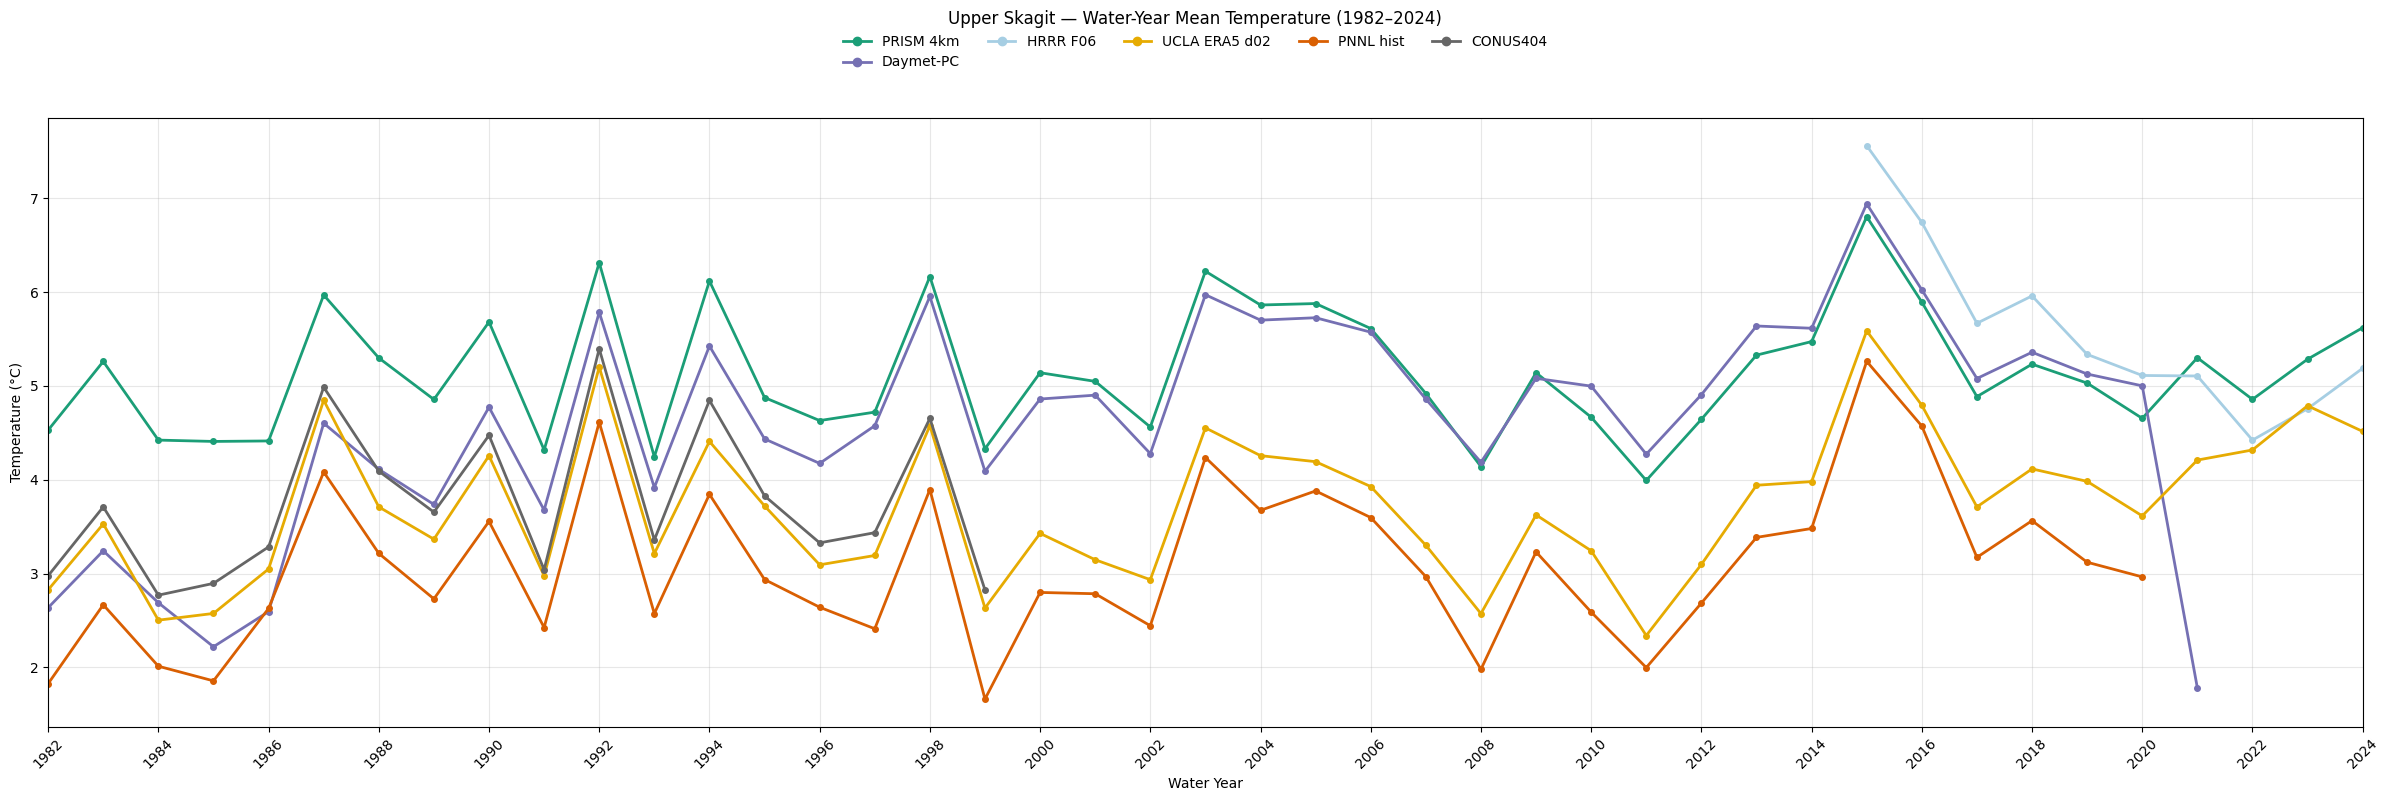

Saved plot → /data0/skagit_met/data_transfer/data/derived/wy_mean_temp_Sauk_1982_2024_FULL_TIMELINE.png


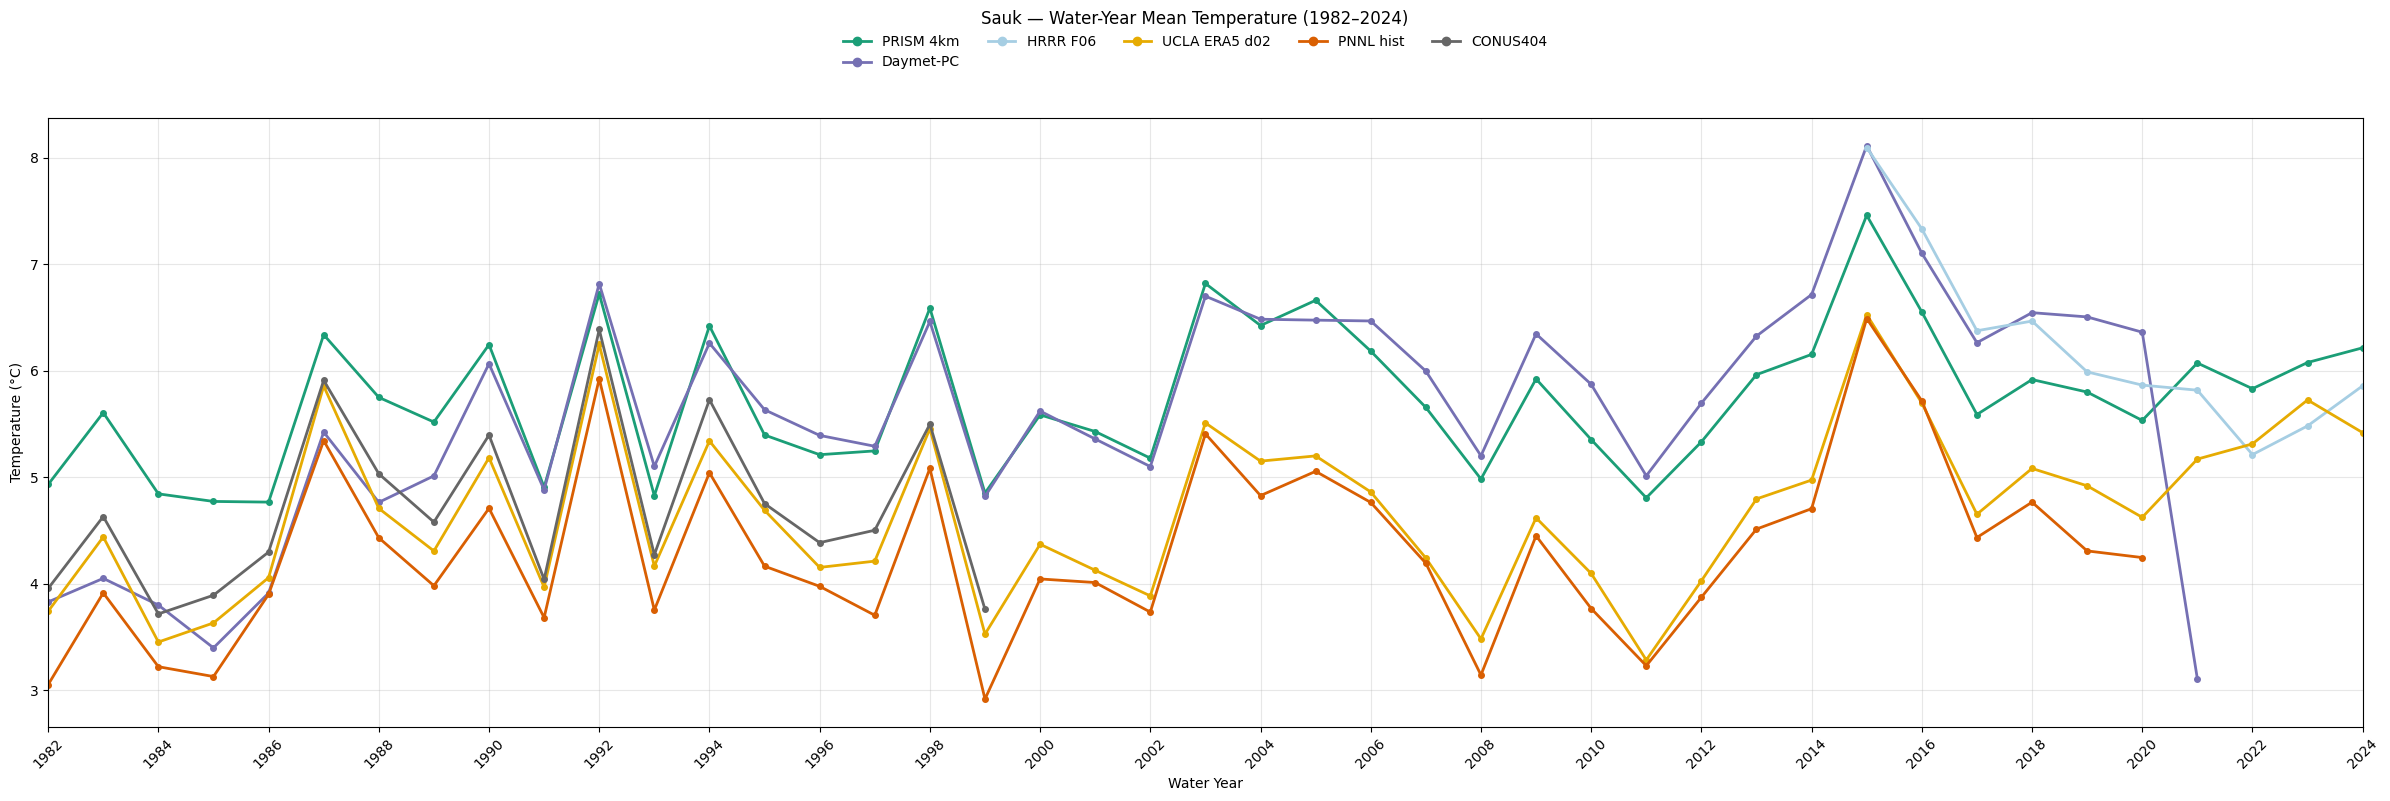

Saved plot → /data0/skagit_met/data_transfer/data/derived/wy_mean_temp_Lower_Skagit_1982_2024_FULL_TIMELINE.png


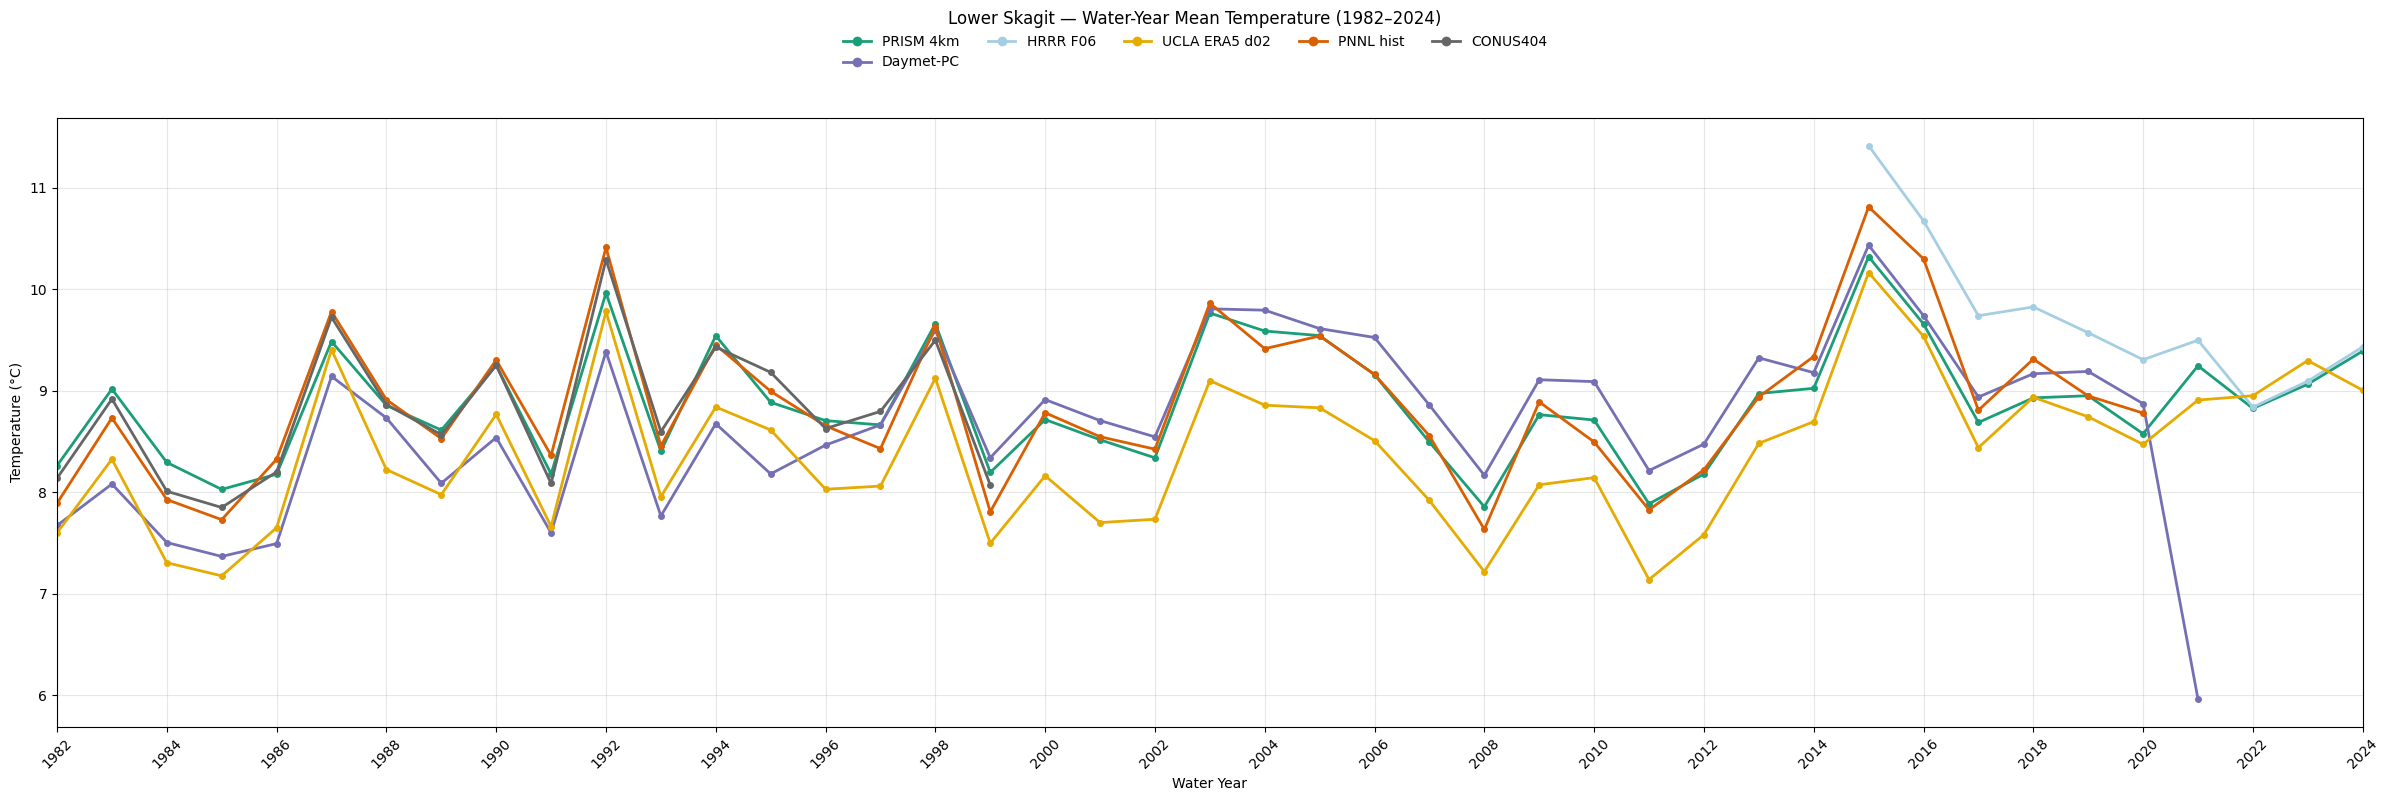

Saved plot → /data0/skagit_met/data_transfer/data/derived/wy_mean_temp_Full_Skagit_1982_2024_FULL_TIMELINE.png


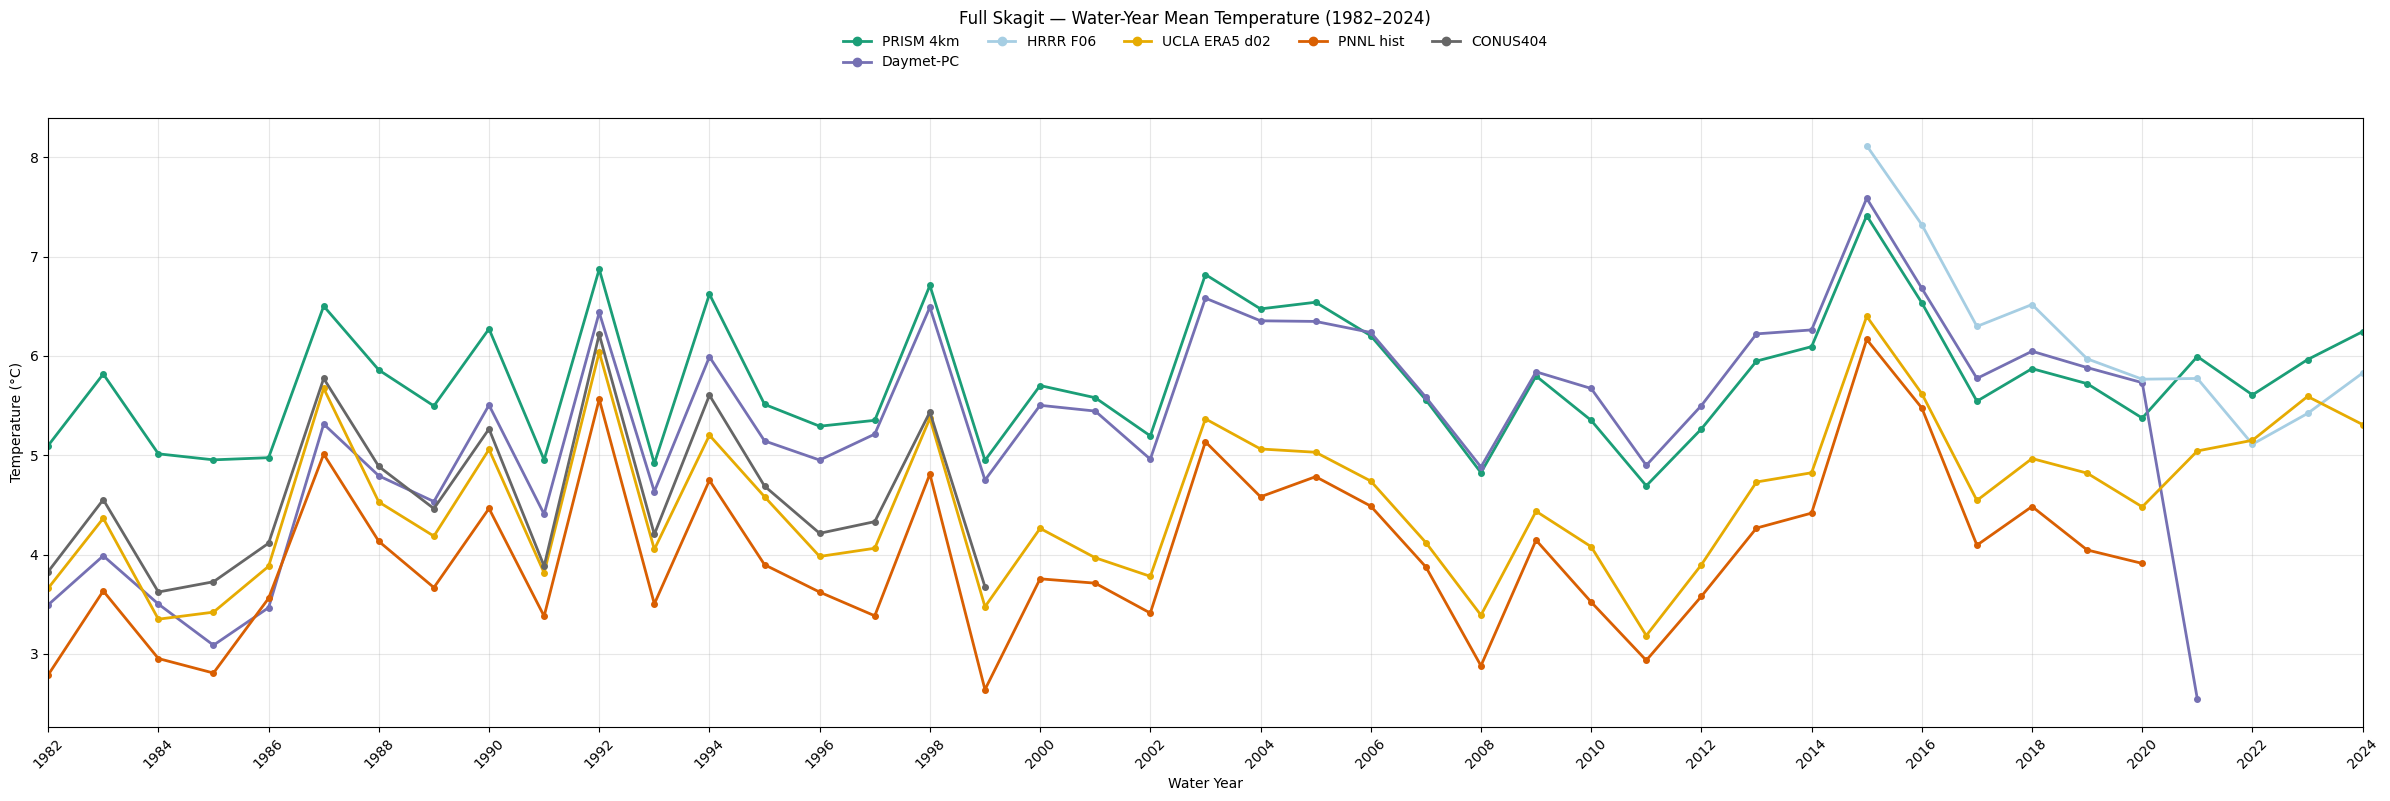

In [3]:
# ==========================================================
# FULL NOTEBOOK CELL: Water-Year Mean Temperature (°C) by 4 regions
#
# OUTPUTS:
#   - Water-year mean temperature CSV by dataset x region x year
#   - 4 figures total:
#       1) Upper Skagit
#       2) Sauk
#       3) Lower Skagit
#       4) Full Skagit
#
# WATER YEAR:
#   - Labeled by ending year
#   - WY 1982 = Oct 1981 .. Sep 1982
#
# REGIONS:
#   - Upper Skagit
#   - Sauk
#   - Lower Skagit
#   - Full Skagit
#
# IMPORTANT:
#   - Full continuous timeline: 1982–2024
#   - No seasonal panels
#   - No MAE plots
#   - Same dataset-loading / masking logic as before
#   - HRRR legend is built manually, so it shows if data exists
# ==========================================================

import re
import sys
import glob
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------- Config ----------------
BASE = Path("/data0/skagit_met/data_transfer/data")
BOUNDARY_GEO = Path("../../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 1982, 2024

# Water year Y = Oct(Y-1) .. Sep(Y)
GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit", "Full Skagit"]

# Local datasets
P_HRRR_DIR  = BASE / "weather_data_06"
PNNL_HIST   = BASE / "PNNL" / "historical"
PNNL_GEO    = PNNL_HIST / "SERDP6km.geo_em.d01.nc"

UCLA_T2_DIR       = Path("/data0/skagit_met/data_transfer/data/ucla_era5_d02_daily/t2")
UCLA_T2_TEMPLATE  = "t2.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE   = Path("/data0/skagit_met/data_transfer/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

DAYMET_DIR       = Path("/data0/skagit_met/data_transfer/data/daymet_nc_2014_2024")
DAYMET_TMIN_GLOB = str(DAYMET_DIR / "daymet_tmin_*.nc")
DAYMET_TMAX_GLOB = str(DAYMET_DIR / "daymet_tmax_*.nc")

PRISM_TEMP_DIR = Path("/data0/skagit_met/data_transfer/data/prism_temp_nc")
PRISM_ZIP_GLOB = "prism_tmean_us_25m_*.zip"

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)

CSV_OUT = OUT / f"wy_mean_temp_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.csv"

# Plot-only exclusions
PLOT_EXCLUSIONS = {
    "Daymet-PC": {2023},
    "HRRR F06": {2014},
}

# ==========================================================
# Canonical colors/order
# ==========================================================
DATASET_ORDER = [
    "PRISM 4km",
    "Daymet-PC",
    "gridMET",
    "HRRR F01",
    "HRRR F06",
    "UCLA ERA5 d02",
    "PNNL hist",
    "CONUS404",
]

COLORS = {
    "PRISM 4km":     "#1B9E77",
    "PRISM 800m":    "#66C2A5",
    "Daymet-PC":     "#7570B3",
    "HRRR F01":      "#1F78B4",
    "HRRR F06":      "#A6CEE3",
    "UCLA ERA5 d02": "#E6AB02",
    "PNNL hist":     "#D95F02",
    "CONUS404":      "#666666",
    "SNOTEL (mean stations)": "#000000",
}

# ==========================================================
# Generic helpers
# ==========================================================
def _ensure_time_name(obj):
    if isinstance(obj, xr.Dataset):
        if "time" not in obj.dims:
            for alt in ("day", "date"):
                if alt in obj.dims:
                    obj = obj.rename({alt: "time"})
                    break
        if "time" not in obj.coords:
            for alt in ("day", "date"):
                if alt in obj.coords:
                    obj = obj.rename({alt: "time"})
                    break
        return obj

    if isinstance(obj, xr.DataArray):
        if "time" not in obj.dims:
            for alt in ("day", "date"):
                if alt in obj.dims:
                    obj = obj.rename({alt: "time"})
                    break
        return obj

    return obj

def ensure_time_sorted_unique(da):
    da = _ensure_time_name(da)
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_celsius(da):
    da = _ensure_time_name(da)

    da = xr.where(np.isfinite(da), da, np.nan)
    da = xr.where(np.abs(da) < 1e20, da, np.nan)

    try:
        probe = da.isel(time=0) if "time" in da.dims else da
        m = float(probe.mean(skipna=True).compute()) if hasattr(probe.data, "compute") else float(probe.mean(skipna=True))
    except Exception:
        m = 0.0

    out = da - 273.15 if m > 150 else da
    out = xr.where(np.isfinite(out), out, np.nan)
    out = xr.where((out > -80) & (out < 80), out, np.nan)
    return out

def pick_var(ds, candidates):
    for v in candidates:
        if v in ds.data_vars:
            return v
    lcands = [c.lower() for c in candidates]
    for v in ds.data_vars:
        if v.lower() in lcands:
            return v
    return None

def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat", "latitude", "lat2d", "XLAT", "XLAT_M", "Lat", "LAT"] if n in ds), None)
    lon_name = next((n for n in ["lon", "longitude", "lon2d", "XLONG", "XLONG_M", "Lon", "LON"] if n in ds), None)
    return lat_name, lon_name

def _to_2d(arr):
    arr = _ensure_time_name(arr)
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x", "y", "lon", "lat", "lon2d", "lat2d", "south_north", "west_east")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def fix_duplicate_dims_da(da):
    dims = list(da.dims)
    if len(dims) == len(set(dims)):
        return da
    seen, new_dims = {}, []
    for d in dims:
        seen[d] = seen.get(d, 0) + 1
        new_dims.append(d if seen[d] == 1 else f"{d}{seen[d]-1}")
    da.dims = tuple(new_dims)
    return da

def fix_duplicate_dims(ds):
    for name, var in ds.variables.items():
        dims = list(getattr(var, "dims", ()))
        if len(dims) == len(set(dims)):
            continue
        seen, new_dims = {}, []
        for d in dims:
            seen[d] = seen.get(d, 0) + 1
            new_dims.append(d if seen[d] == 1 else f"{d}{seen[d]-1}")
        ds[name].dims = tuple(new_dims)
    return ds

def align_mask_to_da(mask_da, da):
    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"Expected 2 spatial dims, got {spatial}")

    mask_da = mask_da.squeeze(drop=True)
    mask_da = fix_duplicate_dims_da(mask_da)
    if mask_da.ndim != 2:
        raise RuntimeError(f"Mask must be 2D; got dims={mask_da.dims}, shape={mask_da.shape}")

    mdims = list(mask_da.dims)

    rename_map = {}
    used_sd = set()
    for md in mdims:
        if md in spatial:
            rename_map[md] = md
            used_sd.add(md)

    remaining_md = [md for md in mdims if md not in rename_map]
    remaining_sd = [sd for sd in spatial if sd not in used_sd]

    for md in remaining_md:
        matched = None
        for sd in remaining_sd:
            if mask_da.sizes[md] == da.sizes[sd]:
                matched = sd
                break
        if matched is None:
            raise RuntimeError(
                f"Could not map mask dim '{md}' (size={mask_da.sizes[md]}) "
                f"to any of {remaining_sd} with sizes {[da.sizes[s] for s in remaining_sd]}"
            )
        rename_map[md] = matched
        remaining_sd.remove(matched)

    m = mask_da.rename(rename_map)

    if set(m.dims) == set(spatial) and list(m.dims) != spatial:
        m = m.transpose(*spatial)

    if (m.sizes.get(spatial[0], -1) != da.sizes[spatial[0]]) or (m.sizes.get(spatial[1], -1) != da.sizes[spatial[1]]):
        raise RuntimeError(
            f"Mask shape {(m.sizes.get(spatial[0]), m.sizes.get(spatial[1]))} "
            f"does not match data grid {(da.sizes[spatial[0]], da.sizes[spatial[1]])}"
        )
    return m

def contains_xy_mask(geom, xs, ys):
    try:
        import shapely
        cx = getattr(shapely, "contains_xy", None)
        if callable(cx):
            return np.asarray(cx(geom, xs, ys), dtype=bool)
    except Exception:
        pass

    try:
        from shapely.vectorized import contains as vcontains
        return np.asarray(vcontains(geom, xs, ys), dtype=bool)
    except Exception:
        pass

    import shapely as _sh
    from shapely.prepared import prep
    pg = prep(geom)
    return np.array([pg.contains(_sh.Point(x, y)) for x, y in zip(xs, ys)], dtype=bool)

def masked_mean_timeseries(da, mask2d):
    da = _ensure_time_name(da)
    spatial_dims = [d for d in da.dims if d != "time"]

    m = mask2d
    if set(m.dims) != set(spatial_dims) or list(m.dims) != spatial_dims:
        m = align_mask_to_da(m, da)

    w = xr.where(m, 1.0, np.nan)
    return (da * w).mean(dim=spatial_dims, skipna=True)

def masked_region_mean_from_masks(da, masks_dict, region_names):
    out_list = []
    for rname in region_names:
        out_list.append(masked_mean_timeseries(da, masks_dict[rname]))
    return xr.concat(out_list, dim="region").assign_coords(region=region_names)

# ==========================================================
# Water-year helpers
# ==========================================================
def years_for_water_year():
    return range(YEAR_MIN, YEAR_MAX + 1)

def water_year_time_window(year):
    return f"{year-1}-10-01", f"{year}-09-30"

def water_year_index(time_da):
    y = time_da.dt.year
    m = time_da.dt.month
    wy = xr.where(m >= 10, y + 1, y)
    return wy.rename("year")

def water_year_mean_c(da):
    """
    da dims: ('time','region') or ('time',)
    returns dims: ('year','region') or ('year',)
    """
    if "time" not in da.dims:
        return None

    da = ensure_time_sorted_unique(da)
    wy = water_year_index(da["time"])
    out = da.groupby(wy).mean("time", skipna=True)

    if "year" not in out.dims:
        candidates = [d for d in out.dims if d not in ("time", "region")]
        if candidates:
            out = out.rename({candidates[0]: "year"})

    out.name = "temp_c"
    return out

# ==========================================================
# Region helpers
# ==========================================================
def load_regions_gdf():
    import geopandas as gpd

    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    sub3 = ["Upper Skagit", "Sauk", "Lower Skagit"]
    huc8_3 = huc8[huc8["Name"].isin(sub3)].copy()
    if huc8_3.empty:
        raise ValueError(f"No matching HUC8 regions found for {sub3}. Check 'Name' field.")

    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_3 = huc8_3[["Name", "geometry"]].reset_index(drop=True)

    full_row = gpd.GeoDataFrame(
        {"Name": ["Full Skagit"], "geometry": [skagit_gdf.geometry.iloc[0]]},
        crs="EPSG:4326",
    )

    regions_gdf = pd.concat([regions_3, full_row], ignore_index=True)
    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    regions_gdf = regions_gdf.sort_values("Name").reset_index(drop=True)
    return regions_gdf

def region_mean(da, grid_ds=None, regions_gdf=None):
    """
    Robust region mean using regionmask with overlap=True.
    Handles Full Skagit overlapping subregions.
    """
    if regions_gdf is None:
        raise ValueError("regions_gdf is required")

    import regionmask

    da = _ensure_time_name(da)
    host = _ensure_time_name(grid_ds if grid_ds is not None else da.to_dataset(name="_tmp"))

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        return da.expand_dims(region=list(regions_gdf["Name"].values))

    lat_name, lon_name = find_lat_lon_names(host)
    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(host[lon_name])
    lat = _to_2d(host[lat_name])

    if lon.ndim == 1 and lat.ndim == 1 and len(spatial) == 2:
        lon_dim = next((d for d in spatial if da.sizes.get(d, -1) == lon.size), None)
        lat_dim = next((d for d in spatial if da.sizes.get(d, -1) == lat.size and d != lon_dim), None)
        if lon_dim and lat_dim:
            lon2d, lat2d = np.meshgrid(lon.values, lat.values)
            lon = xr.DataArray(lon2d, dims=(lat_dim, lon_dim))
            lat = xr.DataArray(lat2d, dims=(lat_dim, lon_dim))

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_regions",
        overlap=True,
    )

    m3 = regs.mask_3D(lon, lat)

    spatial_dims = [d for d in da.dims if d != time_dim]
    mask_spatial_dims = [d for d in m3.dims if d != "region"]

    if set(mask_spatial_dims) != set(spatial_dims):
        rename_map = {}
        for md in mask_spatial_dims:
            for pd in spatial_dims:
                if m3.sizes.get(md) == da.sizes.get(pd):
                    rename_map[md] = pd
                    break
        if rename_map:
            m3 = m3.rename(rename_map)

    if set([d for d in m3.dims if d != "region"]) == set(spatial_dims):
        desired = ["region"] + spatial_dims
        if list(m3.dims) != desired:
            m3 = m3.transpose(*desired)

    out_list = []
    for i, _rname in enumerate(regs.names):
        m = m3.isel(region=i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(dim=spatial_dims, skipna=True))

    out = xr.concat(out_list, dim="region").assign_coords(region=regs.names)
    return out

# ==========================================================
# Dataset label / plotting helpers
# ==========================================================
def color_for_dataset(dsname):
    return COLORS.get(str(dsname), "#000000")

def _ordered_datasets_present(df_sub):
    present = list(df_sub["dataset"].unique())
    ordered = [d for d in DATASET_ORDER if d in present]
    ordered += [d for d in present if d not in ordered]
    return ordered

def _legend_datasets_present(df_sub, value_col):
    ds_order = _ordered_datasets_present(df_sub)
    out = []
    for d in ds_order:
        sub = df_sub[df_sub["dataset"] == d]
        if sub[value_col].notna().any():
            out.append(d)
    return out

def _ylim_for_series(values):
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return (0.0, 1.0)

    vmin = float(np.nanmin(v))
    vmax = float(np.nanmax(v))
    if np.isclose(vmin, vmax):
        pad = 1.0
    else:
        pad = 0.05 * (vmax - vmin)
    return (vmin - pad, vmax + pad)

def _build_legend_handles(dataset_names):
    handles = []
    for dsname in dataset_names:
        handles.append(
            Line2D(
                [0], [0],
                color=color_for_dataset(dsname),
                marker="o",
                linewidth=2.0,
                label=dsname,
            )
        )
    return handles

def plot_region_water_year_full_timeline(
    df_region,
    value_col,
    ylabel,
    title_prefix,
    out_path,
):
    fig, ax = plt.subplots(figsize=(24, 8))

    ds_order = _ordered_datasets_present(df_region)
    ylims = _ylim_for_series(df_region[value_col].values)

    for name in ds_order:
        g = df_region[df_region["dataset"] == name].sort_values("year")
        g = g[np.isfinite(g[value_col])]
        if g.empty:
            continue

        ax.plot(
            g["year"],
            g[value_col],
            marker="o",
            color=color_for_dataset(name),
            linewidth=2.0,
            markersize=4,
        )

    ax.set_xlim(YEAR_MIN, YEAR_MAX)
    ax.set_ylim(*ylims)
    ax.set_xlabel("Water Year")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

    xticks = np.arange(YEAR_MIN, YEAR_MAX + 1, 2)
    ax.set_xticks(xticks)
    ax.tick_params(axis="x", rotation=45)

    legend_names = _legend_datasets_present(df_region, value_col)
    if legend_names:
        handles = _build_legend_handles(legend_names)
        fig.legend(
            handles=handles,
            labels=legend_names,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.98),
            ncol=min(5, len(legend_names)),
            fontsize=10,
            frameon=False,
        )

    fig.suptitle(title_prefix, y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    print("Saved plot →", out_path)
    plt.show()

# ==========================================================
# Daymet local helpers
# ==========================================================
def year_from_path(p):
    m = re.search(r"_(\d{4})\.nc$", str(p))
    return int(m.group(1)) if m else None

def good_file(p, var):
    try:
        ds = xr.open_dataset(p, engine="netcdf4")
        ds = _ensure_time_name(ds)
        ok = (var in ds.data_vars) and (ds.sizes.get("time", 0) > 0)
        ds.close()
        return ok
    except Exception:
        return False

def open_daymet_year(path_nc, var):
    ds = xr.open_dataset(path_nc, engine="netcdf4")
    ds = _ensure_time_name(ds)

    if var not in ds:
        ds.close()
        raise KeyError(f"{path_nc} missing var={var}")

    if "x" in ds.coords:
        ds = ds.sortby("x")
    if "y" in ds.coords:
        ds = ds.sortby("y")

    if "time" in ds.coords:
        tt = pd.to_datetime(ds["time"].values)
        _, idx = np.unique(tt, return_index=True)
        ds = ds.isel(time=np.sort(idx))

    return ds[[var]]

def ensure_daymet_pkgs():
    needed = ["pyproj", "shapely"]
    import importlib
    import subprocess

    missing = []
    for p in needed:
        try:
            importlib.import_module(p)
        except Exception:
            missing.append(p)

    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

def build_daymet_local_masks(ds_daymet, regions_gdf):
    ensure_daymet_pkgs()

    from pyproj import CRS, Transformer
    from shapely.ops import transform as shp_transform

    daymet_crs = CRS.from_proj4(
        "+proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )
    tfm = Transformer.from_crs("EPSG:4326", daymet_crs, always_xy=True)

    def _project_geom(geom_ll):
        def _proj(x, y, z=None):
            return tfm.transform(x, y)
        return shp_transform(_proj, geom_ll)

    if "x" not in ds_daymet.coords or "y" not in ds_daymet.coords:
        raise RuntimeError("[Daymet local] Expected x/y coordinates in local NetCDF")

    xvals = np.asarray(ds_daymet["x"].values)
    yvals = np.asarray(ds_daymet["y"].values)
    xx, yy = np.meshgrid(xvals, yvals)

    masks = {}
    regs_ll = regions_gdf.to_crs("EPSG:4326")
    for _, row in regs_ll.iterrows():
        rname = str(row["Name"])
        geom_xy = _project_geom(row["geometry"])
        mask_np = contains_xy_mask(geom_xy, xx.ravel(), yy.ravel()).reshape(len(yvals), len(xvals))
        masks[rname] = xr.DataArray(mask_np, dims=("y", "x"), coords={"y": ds_daymet["y"], "x": ds_daymet["x"]})

    return masks

# ==========================================================
# PRISM helpers
# ==========================================================
def _detect_prism_temp_var(ds):
    candidates = ["tmean", "tavg", "tmean_c", "tmean_degC", "Tmean", "temp", "tas"]
    for v in candidates:
        if v in ds.data_vars:
            return v
    for v in ds.data_vars:
        vl = v.lower()
        if "tmean" in vl or "tavg" in vl or ("temp" in vl and "mean" in vl):
            return v
    return None

def _parse_prism_zarr_year_range(p):
    m = re.match(
        r"^(\d{4})-\d{2}-\d{2}_(\d{4})-\d{2}-\d{2}_daily_4km_PRISM_data\.zarr$",
        p.name
    )
    if not m:
        return None
    return int(m.group(1)), int(m.group(2))

def _prepare_prism_da(da):
    if "time" not in da.dims:
        tdim = next(
            (d for d in da.dims if "time" in d.lower() or "day" in d.lower() or "date" in d.lower()),
            None
        )
        if tdim:
            da = da.rename({tdim: "time"})
    da = ensure_time_sorted_unique(da)
    return da

def _month_keys_from_time(time_vals):
    tt = pd.to_datetime(time_vals)
    return set(tt.to_period("M").astype(str).tolist())

def _extract_prism_nc_from_zip(zpath, cache_dir):
    cache_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zpath, "r") as zf:
        members = zf.namelist()
        nc_members = [m for m in members if m.lower().endswith(".nc")]
        if not nc_members:
            return None

        inner = nc_members[0]
        out = cache_dir / f"{zpath.stem}.nc"
        if out.exists():
            return out

        zf.extract(inner, path=cache_dir)
        extracted = cache_dir / inner

        out.parent.mkdir(parents=True, exist_ok=True)
        if extracted.resolve() != out.resolve():
            if out.exists():
                out.unlink()
            extracted.rename(out)

        return out

# ==========================================================
# UCLA helpers
# ==========================================================
def pick_time_dim(da):
    if "time" in da.dims:
        return "time"
    if "day" in da.dims:
        return "day"
    for d in da.dims:
        if "time" in d.lower() or "day" in d.lower():
            return d
    raise ValueError(f"[UCLA] No time-like dim found. dims={da.dims}")

def ensure_sorted_unique_time(da, tdim="time"):
    da = da.sortby(tdim)
    try:
        t = pd.to_datetime(da[tdim].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel({tdim: np.sort(idx)})
    except Exception:
        pass
    return da

def ucla_file_label_for_date(dt):
    # Sep..Dec belong to label=year; Jan..Aug belong to label=year-1
    return dt.year if dt.month >= 9 else (dt.year - 1)

def open_ucla_t2_for_window(t0, t1):
    t0_ts = pd.Timestamp(t0)
    t1_ts = pd.Timestamp(t1)
    labels_needed = sorted({ucla_file_label_for_date(t0_ts), ucla_file_label_for_date(t1_ts)})

    files = []
    for lab in labels_needed:
        f = UCLA_T2_DIR / UCLA_T2_TEMPLATE.format(year=lab)
        if f.exists():
            files.append(str(f))

    if not files:
        return None, []

    dsets, arrs = [], []
    for f in files:
        ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)

        v = pick_var(ds, ["t2", "T2", "t2m", "tas", "temp"])
        if v is None:
            ds.close()
            continue

        da = ds[v]
        tdim = pick_time_dim(da)
        if tdim != "time":
            da = da.rename({tdim: "time"})

        arrs.append(da)
        dsets.append(ds)

    if not arrs:
        return None, []

    all_da = xr.concat(arrs, dim="time", join="outer", coords="minimal", compat="override")
    all_da = ensure_sorted_unique_time(all_da, "time")
    all_da = all_da.sel(time=slice(t0, t1))

    if all_da.sizes.get("time", 0) == 0:
        for ds in dsets:
            try:
                ds.close()
            except Exception:
                pass
        return None, []

    return all_da, dsets

def build_ucla_region_masks(coord_file, regions_gdf):
    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True).astype("float64")
    lon = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    lonv = lon.values.ravel()
    latv = lat.values.ravel()
    ny, nx = lon.shape

    masks = {}
    for _, row in regions_gdf.iterrows():
        name = str(row["Name"])
        geom = row["geometry"]
        m_flat = contains_xy_mask(geom, lonv, latv)
        mask2d = m_flat.reshape(ny, nx).astype(bool)
        masks[name] = xr.DataArray(mask2d, dims=lon.dims, coords=lon.coords)

    return masks

# ==========================================================
# HRRR F06 helpers
# ==========================================================
def _find_hrrr_t2_var(ds):
    if "t2m" in ds.data_vars:
        return "t2m"
    if "T2" in ds.data_vars:
        return "T2"
    for v in ds.data_vars:
        lv = v.lower()
        if lv in ("t2m", "t2", "tas") or ("temp" in lv and "2" in lv):
            return v
    return None

def hrrr_f06_daily_t2_c(ds, var="t2m"):
    """
    HRRR F06 temperature logic:
      - ds.time is INIT time
      - keep init hours 00/06/12/18
      - shift init -> valid time by +6h
      - daily mean = mean of 4 six-hour valid-time samples per day
    """
    if var not in ds:
        raise ValueError(f"[HRRR F06] Missing '{var}'. vars={list(ds.data_vars)}")

    da = ensure_time_sorted_unique(ds[var])

    t = pd.to_datetime(da["time"].values)
    keep = np.isin(t.hour, [0, 6, 12, 18])
    da = da.sel(time=da["time"].values[keep])

    da = da.assign_coords(time=(pd.to_datetime(da["time"].values) + pd.Timedelta(hours=6)))
    da = to_celsius(da)

    daily = da.resample(time="1D").mean()
    return daily

# ==========================================================
# Begin collection
# ==========================================================
regions_gdf = load_regions_gdf()
rows = []

# ==========================================================
# 1) Daymet LOCAL
# ==========================================================
print("[DAYMET-LOCAL] Computing water-year mean temperature from local NetCDFs...")
try:
    tmin_files = sorted(glob.glob(DAYMET_TMIN_GLOB))
    tmax_files = sorted(glob.glob(DAYMET_TMAX_GLOB))

    tmin_good = {year_from_path(f): f for f in tmin_files if year_from_path(f) is not None and good_file(f, "tmin")}
    tmax_good = {year_from_path(f): f for f in tmax_files if year_from_path(f) is not None and good_file(f, "tmax")}

    years = sorted([y for y in range(YEAR_MIN - 1, YEAR_MAX + 1) if (y in tmin_good and y in tmax_good)])
    if not years:
        raise RuntimeError("No overlapping good tmin/tmax years found.")

    dsmin_list, dsmax_list = [], []
    for y in years:
        dsmin_list.append(open_daymet_year(tmin_good[y], "tmin"))
        dsmax_list.append(open_daymet_year(tmax_good[y], "tmax"))

    ds_min = xr.concat(dsmin_list, dim="time", join="outer", coords="minimal", compat="override").sortby("time")
    ds_max = xr.concat(dsmax_list, dim="time", join="outer", coords="minimal", compat="override").sortby("time")

    tmin = ensure_time_sorted_unique(ds_min["tmin"])
    tmax = ensure_time_sorted_unique(ds_max["tmax"])
    tmin2, tmax2 = xr.align(tmin, tmax, join="inner")

    tmean = to_celsius((tmin2 + tmax2) / 2.0).sel(time=slice(GLOBAL_START, GLOBAL_END))

    daymet_masks = build_daymet_local_masks(ds_min, regions_gdf)
    rm = ensure_time_sorted_unique(masked_region_mean_from_masks(tmean, daymet_masks, REGION_NAMES))

    ann = water_year_mean_c(rm)
    if ann is not None and "year" in ann.dims:
        for yr in years_for_water_year():
            if yr not in ann["year"].values:
                continue
            for rgn in ann["region"].values:
                val = float(ann.sel(year=yr, region=rgn).values)
                if np.isfinite(val):
                    rows.append({
                        "dataset": "Daymet-PC",
                        "region": str(rgn),
                        "year": int(yr),
                        "temp_c": float(val),
                    })

    for d in dsmin_list:
        try:
            d.close()
        except Exception:
            pass
    for d in dsmax_list:
        try:
            d.close()
        except Exception:
            pass
    try:
        ds_min.close()
    except Exception:
        pass
    try:
        ds_max.close()
    except Exception:
        pass

    print("[DAYMET-LOCAL] Success.")
except Exception as e:
    print("[DAYMET-LOCAL] FAILED:", repr(e))

# ==========================================================
# 2) PRISM temp (zarr first, then fill missing months from zips)
# ==========================================================
print("[PRISM-TEMP] Computing water-year mean temperature from local PRISM...")
try:
    prism_rm_parts = []
    loaded_months = set()

    target_months = set(pd.date_range(GLOBAL_START, GLOBAL_END, freq="MS").strftime("%Y-%m").tolist())

    prism_zarrs_all = sorted([p for p in PRISM_TEMP_DIR.glob("*_daily_4km_PRISM_data.zarr") if p.is_dir()])

    zarr_info = []
    for p in prism_zarrs_all:
        yr = _parse_prism_zarr_year_range(p)
        if yr is not None:
            zarr_info.append((p, yr[0], yr[1]))

    zarr_info = sorted(zarr_info, key=lambda x: (x[1], -x[2]))

    selected_zarrs = []
    for p, ys, ye in zarr_info:
        contained = any((ys >= s and ye <= e) for _, s, e in selected_zarrs)
        if not contained:
            selected_zarrs.append((p, ys, ye))

    for p, ys, ye in selected_zarrs:
        try:
            ds = safe_open_zarr(p)
            v = _detect_prism_temp_var(ds)
            if v is None:
                try:
                    ds.close()
                except Exception:
                    pass
                continue

            da = _prepare_prism_da(ds[v])
            if "time" not in da.dims:
                try:
                    ds.close()
                except Exception:
                    pass
                continue

            da = to_celsius(da).sel(time=slice(GLOBAL_START, GLOBAL_END))
            if da.sizes.get("time", 0) == 0:
                try:
                    ds.close()
                except Exception:
                    pass
                continue

            rm = region_mean(da, grid_ds=ds, regions_gdf=regions_gdf)
            rm = ensure_time_sorted_unique(rm).load()
            prism_rm_parts.append(rm)

            loaded_months |= _month_keys_from_time(rm["time"].values)

            try:
                ds.close()
            except Exception:
                pass

        except Exception as e:
            print(f"[PRISM-TEMP] Failed zarr {p.name}: {repr(e)}")

    prism_zips = sorted(PRISM_TEMP_DIR.glob(PRISM_ZIP_GLOB))
    cache_dir = PRISM_TEMP_DIR / "_prism_nc_cache"
    ym_re = re.compile(r"_(\d{6})$")

    for zp in prism_zips:
        m = ym_re.search(zp.stem)
        if not m:
            continue

        ym = m.group(1)
        month_key = f"{ym[:4]}-{ym[4:]}"
        if month_key not in target_months or month_key in loaded_months:
            continue

        nc_path = _extract_prism_nc_from_zip(zp, cache_dir)
        if nc_path is None:
            continue

        try:
            ds = xr.open_dataset(nc_path, engine="netcdf4")
            ds = _ensure_time_name(ds)

            v = _detect_prism_temp_var(ds)
            if v is None:
                ds.close()
                continue

            da = _prepare_prism_da(ds[v])
            if "time" not in da.dims:
                ds.close()
                continue

            da = to_celsius(da).sel(time=slice(GLOBAL_START, GLOBAL_END))
            if da.sizes.get("time", 0) == 0:
                ds.close()
                continue

            rm = region_mean(da, grid_ds=ds, regions_gdf=regions_gdf)
            rm = ensure_time_sorted_unique(rm).load()
            prism_rm_parts.append(rm)
            loaded_months |= _month_keys_from_time(rm["time"].values)
            ds.close()

        except Exception as e:
            print(f"[PRISM-TEMP] Failed zip {zp.name}: {repr(e)}")

    if not prism_rm_parts:
        raise RuntimeError("No usable PRISM data found from either zarrs or zips.")

    prism_rm = xr.concat(prism_rm_parts, dim="time", join="outer", coords="minimal", compat="override")
    prism_rm = ensure_time_sorted_unique(prism_rm)
    prism_rm = prism_rm.sel(time=slice(GLOBAL_START, GLOBAL_END))

    ann = water_year_mean_c(prism_rm)
    if ann is not None and "year" in ann.dims:
        for yr in years_for_water_year():
            if yr not in ann["year"].values:
                continue
            for rgn in ann["region"].values:
                val = float(ann.sel(year=yr, region=rgn).values)
                if np.isfinite(val):
                    rows.append({
                        "dataset": "PRISM 4km",
                        "region": str(rgn),
                        "year": int(yr),
                        "temp_c": float(val),
                    })

    print("[PRISM-TEMP] Success.")
except Exception as e:
    print("[PRISM-TEMP] SKIP/FAILED:", repr(e))

# ==========================================================
# 3) UCLA ERA5 d02
# ==========================================================
print("[UCLA] Computing water-year mean temperature from local NetCDFs...")
try:
    if not UCLA_T2_DIR.exists():
        raise RuntimeError(f"Missing UCLA dir: {UCLA_T2_DIR}")
    if not UCLA_COORD_FILE.exists():
        raise RuntimeError(f"Missing UCLA coord file: {UCLA_COORD_FILE}")

    UCLA_REGION_MASKS = build_ucla_region_masks(UCLA_COORD_FILE, regions_gdf)

    for yr in years_for_water_year():
        t0, t1 = water_year_time_window(yr)
        da, parents = open_ucla_t2_for_window(t0, t1)
        if da is None:
            continue

        try:
            da = to_celsius(da)
            for rname in REGION_NAMES:
                ts = masked_mean_timeseries(da, UCLA_REGION_MASKS[rname])
                val = float(ts.mean(dim="time", skipna=True).compute().values)
                if np.isfinite(val):
                    rows.append({
                        "dataset": "UCLA ERA5 d02",
                        "region": str(rname),
                        "year": int(yr),
                        "temp_c": float(val),
                    })
        finally:
            for ds in parents:
                try:
                    ds.close()
                except Exception:
                    pass

    print("[UCLA] Success.")
except Exception as e:
    print("[UCLA] FAILED:", repr(e))

# ==========================================================
# 4) HRRR F06
# ==========================================================
print(f"[HRRR F06] Computing water-year mean temperature from monthly zarrs in {P_HRRR_DIR} ...")
try:
    if not P_HRRR_DIR.exists():
        raise RuntimeError(f"Missing HRRR dir: {P_HRRR_DIR}")

    zarrs = sorted([p for p in P_HRRR_DIR.glob("*.zarr") if p.is_dir()])
    monthly = [p for p in zarrs if re.match(r"^\d{4}-\d{2}_HRRR_f06_data\.zarr$", p.name)]
    by_prefix = {p.name[:7]: p for p in monthly}

    if not monthly:
        raise RuntimeError(f"No monthly HRRR F06 zarrs found in {P_HRRR_DIR}")

    all_months = pd.date_range(GLOBAL_START, GLOBAL_END, freq="MS").strftime("%Y-%m").tolist()

    first_template = by_prefix.get(all_months[0], None)
    if first_template is None:
        first_template = by_prefix[sorted(by_prefix.keys())[0]]

    ds0 = safe_open_zarr(first_template)
    v0 = _find_hrrr_t2_var(ds0)
    if v0 is None:
        raise RuntimeError(f"No HRRR temperature var found. Vars={list(ds0.data_vars)}")

    rm_parts = []
    for month_key in all_months:
        if month_key not in by_prefix:
            continue

        ds = None
        try:
            ds = safe_open_zarr(by_prefix[month_key])
            v = v0 if v0 in ds.data_vars else _find_hrrr_t2_var(ds)
            if v is None:
                continue

            daily = hrrr_f06_daily_t2_c(ds, var=v)
            if daily.sizes.get("time", 0) == 0:
                continue

            rm_daily = region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)
            rm_daily = ensure_time_sorted_unique(rm_daily)
            rm_daily = rm_daily.sel(time=slice(GLOBAL_START, GLOBAL_END)).load()

            if rm_daily.sizes.get("time", 0) > 0:
                rm_parts.append(rm_daily)

        except Exception as e:
            print(f"[HRRR F06] Failed {month_key}: {type(e).__name__}: {e}")
        finally:
            if ds is not None:
                try:
                    ds.close()
                except Exception:
                    pass

    if not rm_parts:
        raise RuntimeError("No usable HRRR F06 monthly region daily series were produced.")

    rm_all = xr.concat(rm_parts, dim="time", join="outer", coords="minimal", compat="override")
    rm_all = ensure_time_sorted_unique(rm_all)
    rm_all = rm_all.sel(time=slice(GLOBAL_START, GLOBAL_END))

    ann = water_year_mean_c(rm_all)
    if ann is not None and "year" in ann.dims:
        for yr in years_for_water_year():
            if yr not in ann["year"].values:
                continue
            for rgn in ann["region"].values:
                val = float(ann.sel(year=yr, region=rgn).values)
                if np.isfinite(val):
                    rows.append({
                        "dataset": "HRRR F06",
                        "region": str(rgn),
                        "year": int(yr),
                        "temp_c": float(val),
                    })

    try:
        ds0.close()
    except Exception:
        pass

    print("[HRRR F06] Success.")
except Exception as e:
    print("[HRRR F06] SKIP/FAILED:", repr(e))

# ==========================================================
# 5) PNNL (geo_em masks)
# ==========================================================
print("[PNNL] Computing water-year mean temperature from historical T2 using geo_em masks...")
try:
    import regionmask

    if not PNNL_HIST.exists():
        raise RuntimeError("Missing PNNL_HIST")
    if not PNNL_GEO.exists():
        raise RuntimeError(f"Missing PNNL geo_em file: {PNNL_GEO}")

    geo = xr.open_dataset(PNNL_GEO)
    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat2 = _to_2d(geo[lat_name]).astype("float64")
    lon2 = _to_2d(geo[lon_name]).astype("float64")

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_regions",
        overlap=True,
    )
    m3 = regs.mask_3D(lon2, lat2)

    pnnl_masks = {}
    for i, r in enumerate(regs.names):
        pnnl_masks[str(r)] = m3.isel(region=i)

    geo.close()

    def years_needed_for_wy(yr):
        return {yr - 1, yr}

    def months_present_in_selection(time_values):
        t = pd.to_datetime(time_values)
        return set(pd.Index(t.month).unique().tolist())

    need_months = set(range(1, 13))

    for yr in years_for_water_year():
        t0, t1 = water_year_time_window(yr)

        files = []
        for yy in sorted(years_needed_for_wy(yr)):
            files += sorted(glob.glob(str(PNNL_HIST / f"{yy}" / "*T2*.nc")))
        files = sorted(files)

        if not files:
            continue

        def _preprocess(ds):
            return ds[["T2"]] if "T2" in ds.data_vars else ds

        dsp = xr.open_mfdataset(
            files,
            combine="by_coords",
            engine="netcdf4",
            parallel=False,
            preprocess=_preprocess,
            chunks={"time": 24 * 7},
            join="outer",
        )
        dsp = _ensure_time_name(dsp)
        dsp = fix_duplicate_dims(dsp)

        if "T2" not in dsp:
            dsp.close()
            continue

        t2 = ensure_time_sorted_unique(dsp["T2"]).sel(time=slice(t0, t1))
        if t2.sizes.get("time", 0) == 0:
            dsp.close()
            continue

        seen_months = months_present_in_selection(t2["time"].values)
        if len(need_months - set(seen_months)) > 0:
            dsp.close()
            continue

        t2_daily = to_celsius(t2).resample(time="1D").mean()

        for rname in REGION_NAMES:
            bm = masked_mean_timeseries(t2_daily, pnnl_masks[rname])
            val = float(bm.mean("time", skipna=True).compute().values)
            if np.isfinite(val):
                rows.append({
                    "dataset": "PNNL hist",
                    "region": str(rname),
                    "year": int(yr),
                    "temp_c": float(val),
                })

        dsp.close()

    print("[PNNL] Success.")
except Exception as e:
    print("[PNNL] SKIP/FAILED:", repr(e))

# ==========================================================
# 6) CONUS404 online (best-effort)
# ==========================================================
print("[CONUS404] Loading via HyTEST intake (best-effort)...")
try:
    import intake

    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

    ds = fix_duplicate_dims(ds)
    if "lon" in ds:
        ds["lon"] = fix_duplicate_dims_da(ds["lon"])
    if "lat" in ds:
        ds["lat"] = fix_duplicate_dims_da(ds["lat"])

    v = pick_var(ds, ["t2m", "tas", "T2", "temp", "temperature"])
    if v is None:
        raise RuntimeError(f"No temp var found. Vars head={list(ds.data_vars)[:30]}")

    da = to_celsius(ensure_time_sorted_unique(ds[v]).sel(time=slice(GLOBAL_START, GLOBAL_END)))
    rm = ensure_time_sorted_unique(region_mean(da, grid_ds=ds, regions_gdf=regions_gdf))

    ann = water_year_mean_c(rm)
    if ann is not None and "year" in ann.dims:
        for yr in years_for_water_year():
            if yr not in ann["year"].values:
                continue
            for rgn in ann["region"].values:
                val = float(ann.sel(year=yr, region=rgn).values)
                if np.isfinite(val):
                    rows.append({
                        "dataset": "CONUS404",
                        "region": str(rgn),
                        "year": int(yr),
                        "temp_c": float(val),
                    })

    print(f"[CONUS404] Success. var={v}")
except Exception as e:
    print("[CONUS404] SKIP/FAILED:", repr(e))

# ==========================================================
# Build df
# ==========================================================
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "region", "year"], as_index=False)
      .agg(temp_c=("temp_c", "mean"))
      .sort_values(["region", "dataset", "year"])
      .reset_index(drop=True)
)

df = df[(df["year"] >= YEAR_MIN) & (df["year"] <= YEAR_MAX)].copy()

# ==========================================================
# Final QC
# ==========================================================
df["temp_c"] = pd.to_numeric(df["temp_c"], errors="coerce")

bad_df = df[
    (~np.isfinite(df["temp_c"])) |
    (df["temp_c"] < -30) |
    (df["temp_c"] > 30)
].copy()

if not bad_df.empty:
    print("\n[QC] Dropping suspicious water-year mean temperatures:")
    print(bad_df.sort_values(["region", "dataset", "year"]).to_string(index=False))

df = df[
    np.isfinite(df["temp_c"]) &
    (df["temp_c"] >= -30) &
    (df["temp_c"] <= 30)
].copy()

print("\n[FINAL] Available datasets:", sorted(df["dataset"].unique().tolist()))
print(df.head(10))

df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# ==========================================================
# Plot exclusions (plot-only)
# ==========================================================
df_plot = df.copy()

def _is_excluded(row):
    ds = str(row["dataset"])
    yr = int(row["year"])
    return yr in PLOT_EXCLUSIONS.get(ds, set())

df_plot.loc[df_plot.apply(_is_excluded, axis=1), "temp_c"] = np.nan

# ==========================================================
# PLOTS: one figure per region, water-year full timeline
# ==========================================================
for region in REGION_NAMES:
    df_r = df_plot[df_plot["region"] == region].copy()
    if df_r.empty:
        continue

    out_png = OUT / f"wy_mean_temp_{region.replace(' ', '_')}_{YEAR_MIN}_{YEAR_MAX}_FULL_TIMELINE.png"
    plot_region_water_year_full_timeline(
        df_region=df_r,
        value_col="temp_c",
        ylabel="Temperature (°C)",
        title_prefix=f"{region} — Water-Year Mean Temperature ({YEAR_MIN}–{YEAR_MAX})",
        out_path=out_png,
    )
